OPTIONAL PACKAGE CHECK
✓ timm available
⚠ ultralytics not installed (YOLO will be added later)
✓ albumentations available
✓ torchmetrics available
⚠ grad-cam not installed (will be added in XAI step)

TB-XAI ENVIRONMENT
Python version       : 3.12.13
PyTorch version      : 2.10.0+cu128
OpenCV version       : 4.13.0
Device               : cuda
GPU                  : Tesla T4
GPU memory           : 14.56 GB

PACKAGE STATUS
✓ PyTorch              : Available
✓ Torchvision          : Available
✓ OpenCV               : Available
✓ Scikit-learn         : Available
✓ timm                 : Available
○ Ultralytics          : Not installed
✓ Albumentations       : Available
✓ TorchMetrics         : Available
○ Grad-CAM             : Not installed

○ Missing optional packages will NOT stop Step 1.

AVAILABLE KAGGLE INPUTS
01. notebooks

SELECTED DATASET
Dataset folder : notebooks
Full path      : /kaggle/input/notebooks
Keyword score  : 0

⚠ Dataset name did not contain an obvious TB keyword.
Th

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,25.1272,2.50501,3.35405,2.52789,0.06151,0.12945,0.03649,0.01129,2.24350,3.38402,2.56365,0.000197,0.000197,0.080464
1,2,48.7483,2.33667,2.90471,2.44162,0.28669,0.32039,0.21660,0.06862,2.10081,2.75433,2.42556,0.000393,0.000393,0.060660
2,3,72.5516,2.19203,2.61443,2.31232,0.30971,0.37217,0.26334,0.08685,2.00803,2.57631,2.39249,0.000586,0.000586,0.040852
3,4,96.4174,2.07963,2.48943,2.24902,0.36489,0.41424,0.33377,0.11560,1.92528,2.35912,2.23257,0.000774,0.000774,0.021040
4,5,120.4520,1.91593,2.33721,2.10835,0.41622,0.43689,0.33907,0.12726,1.89887,2.28195,2.24713,0.000958,0.000958,0.001225
5,6,144.6360,1.86113,2.20972,2.07216,0.43918,0.48544,0.39659,0.15196,1.84947,2.10320,2.13827,0.000950,0.000950,0.000950
6,7,168.9860,1.82776,2.09264,2.02811,0.54713,0.46278,0.52310,0.19563,1.93218,1.94443,2.22138,0.000941,0.000941,0.000941
7,8,193.4230,1.80706,2.00981,2.00024,0.63202,0.52249,0.58982,0.22938,1.87631,1.75061,2.11888,0.000931,0.000931,0.000931
8,9,217.9790,1.76312,1.88421,1.91492,0.68429,0.57605,0.63696,0.25699,1.78986,1.72066,2.02230,0.000921,0.000921,0.000921
9,10,242.5050,1.76582,1.85154,1.93277,0.59879,0.50715,0.56917,0.24848,1.78135,1.78353,2.01609,0.000911,0.000911,0.000911



Data types:


,Column,Data_Type
0,epoch,int64
1,time,float64
2,train/box_loss,float64
3,train/cls_loss,float64
4,train/dfl_loss,float64
5,metrics/precision(B),float64
6,metrics/recall(B),float64
7,metrics/mAP50(B),float64
8,metrics/mAP50-95(B),float64
9,val/box_loss,float64



Missing values:


,Missing_n,Missing_percent
epoch,0,0.0
time,0,0.0
train/box_loss,0,0.0
train/cls_loss,0,0.0
train/dfl_loss,0,0.0
metrics/precision(B),0,0.0
metrics/recall(B),0,0.0
metrics/mAP50(B),0,0.0
metrics/mAP50-95(B),0,0.0
val/box_loss,0,0.0



AUTOMATIC COLUMN INSPECTION
Filename column : None
Label column    : None
Split column    : None
BBox columns    : {}

CLASS DISTRIBUTION
No class/label column automatically detected.

IMAGE DIMENSIONS — SAMPLE
Images checked : 100
Width range    : 224 to 3000
Height range   : 224 to 2250
Median width   : 512
Median height  : 512


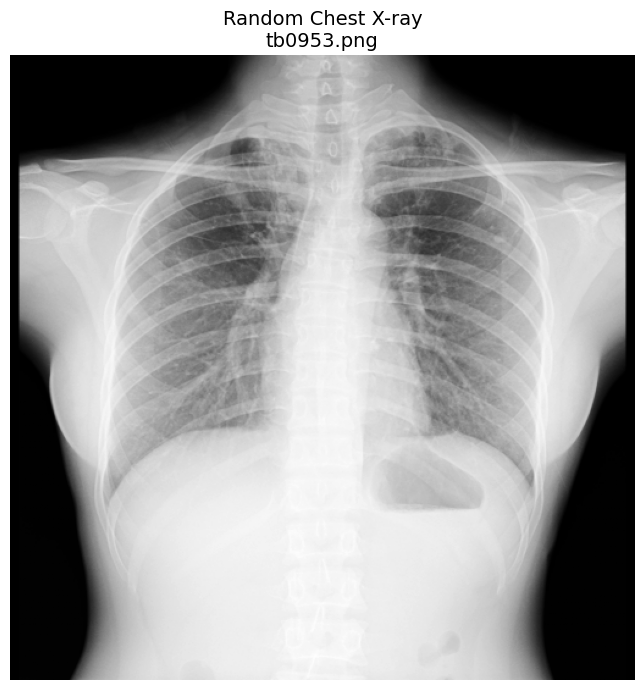


PROJECT CONFIGURATION
seed                          : 42
device                        : cuda
classification_image_size     : 224
yolo_image_size               : 640
batch_size                    : 32
num_workers                   : 2
learning_rate                 : 0.0001
weight_decay                  : 0.0001
epochs                        : 20
train_ratio                   : 0.7
validation_ratio              : 0.15
test_ratio                    : 0.15

TB-XAI — STEP 1 COMPLETE
Dataset root          : /kaggle/input/notebooks
Images found          : 884
CSV files             : 1
Metadata rows         : 72
Metadata columns      : 15
Filename column       : None
Label column          : None
Split column          : None
Bounding box columns  : {}
Device                : cuda
Ultralytics available : False
Grad-CAM available    : False
timm available        : True
Output directory      : /kaggle/working/TB_XAI

CURRENT PROJECT ROADMAP
STEP 1  ✓ Environment + dataset inspection
STEP 2    Da

In [1]:
# ============================================================
# TB-XAI PROJECT
# STEP 1
# ROBUST KAGGLE SETUP + DATA DISCOVERY + INITIAL INSPECTION
#
# IMPORTANT:
# This version DOES NOT require internet or pip install.
# Optional DL/XAI packages are detected automatically.
# ============================================================


# ============================================================
# 0. BASIC PYTHON LIBRARIES
# ============================================================

import os
import sys
import gc
import glob
import random
import warnings
import importlib.util
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")


# ============================================================
# 1. CORE DATA LIBRARIES
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 2. VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches


# ============================================================
# 3. IMAGE PROCESSING
# ============================================================

import cv2

from PIL import Image


# ============================================================
# 4. SCIKIT-LEARN
# ============================================================

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)


# ============================================================
# 5. PYTORCH
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import (
    transforms,
    models
)


# ============================================================
# 6. OPTIONAL PACKAGE DETECTION
# ============================================================

print("=" * 80)
print("OPTIONAL PACKAGE CHECK")
print("=" * 80)


def package_available(package_name):
    """
    Check whether a Python package exists
    without importing it and crashing.
    """

    try:
        return importlib.util.find_spec(package_name) is not None

    except:
        return False


# ------------------------------------------------------------
# TIMM
# ------------------------------------------------------------

TIMM_AVAILABLE = package_available("timm")

if TIMM_AVAILABLE:

    try:
        import timm

        print("✓ timm available")

    except Exception as e:

        TIMM_AVAILABLE = False
        timm = None

        print("⚠ timm detected but import failed")
        print(e)

else:

    timm = None

    print(
        "⚠ timm not installed "
        "(not required for Step 1)"
    )


# ------------------------------------------------------------
# ULTRALYTICS / YOLO
# ------------------------------------------------------------

ULTRALYTICS_AVAILABLE = package_available(
    "ultralytics"
)

if ULTRALYTICS_AVAILABLE:

    try:

        from ultralytics import YOLO

        print("✓ ultralytics / YOLO available")

    except Exception as e:

        ULTRALYTICS_AVAILABLE = False
        YOLO = None

        print(
            "⚠ ultralytics detected but import failed"
        )

        print(e)

else:

    YOLO = None

    print(
        "⚠ ultralytics not installed "
        "(YOLO will be added later)"
    )


# ------------------------------------------------------------
# ALBUMENTATIONS
# ------------------------------------------------------------

ALBUMENTATIONS_AVAILABLE = package_available(
    "albumentations"
)

if ALBUMENTATIONS_AVAILABLE:

    try:

        import albumentations as A

        from albumentations.pytorch import (
            ToTensorV2
        )

        print("✓ albumentations available")

    except Exception as e:

        ALBUMENTATIONS_AVAILABLE = False
        A = None
        ToTensorV2 = None

        print(
            "⚠ albumentations import failed"
        )

        print(e)

else:

    A = None
    ToTensorV2 = None

    print(
        "⚠ albumentations not installed "
        "(torchvision transforms can be used)"
    )


# ------------------------------------------------------------
# TORCHMETRICS
# ------------------------------------------------------------

TORCHMETRICS_AVAILABLE = package_available(
    "torchmetrics"
)

if TORCHMETRICS_AVAILABLE:

    try:

        import torchmetrics

        print("✓ torchmetrics available")

    except Exception as e:

        TORCHMETRICS_AVAILABLE = False
        torchmetrics = None

        print(
            "⚠ torchmetrics import failed"
        )

        print(e)

else:

    torchmetrics = None

    print(
        "⚠ torchmetrics not installed "
        "(sklearn metrics will be used)"
    )


# ------------------------------------------------------------
# GRAD-CAM
# ------------------------------------------------------------

GRADCAM_AVAILABLE = package_available(
    "pytorch_grad_cam"
)

if GRADCAM_AVAILABLE:

    try:

        from pytorch_grad_cam import (
            GradCAM,
            GradCAMPlusPlus,
            EigenCAM
        )

        from pytorch_grad_cam.utils.model_targets import (
            ClassifierOutputTarget
        )

        from pytorch_grad_cam.utils.image import (
            show_cam_on_image
        )

        print("✓ pytorch-grad-cam available")

    except Exception as e:

        GRADCAM_AVAILABLE = False

        GradCAM = None
        GradCAMPlusPlus = None
        EigenCAM = None

        print(
            "⚠ Grad-CAM import failed"
        )

        print(e)

else:

    GradCAM = None
    GradCAMPlusPlus = None
    EigenCAM = None

    print(
        "⚠ grad-cam not installed "
        "(will be added in XAI step)"
    )


# ============================================================
# 7. RANDOM SEED / REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 8. GPU / DEVICE CHECK
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("\n" + "=" * 80)
print("TB-XAI ENVIRONMENT")
print("=" * 80)

print(
    f"Python version       : "
    f"{sys.version.split()[0]}"
)

print(
    f"PyTorch version      : "
    f"{torch.__version__}"
)

print(
    f"OpenCV version       : "
    f"{cv2.__version__}"
)

print(
    f"Device               : "
    f"{DEVICE}"
)


if torch.cuda.is_available():

    gpu_name = torch.cuda.get_device_name(0)

    total_memory = (
        torch.cuda.get_device_properties(
            0
        ).total_memory
        / (1024 ** 3)
    )

    print(
        f"GPU                  : "
        f"{gpu_name}"
    )

    print(
        f"GPU memory           : "
        f"{total_memory:.2f} GB"
    )

else:

    print(
        "\n⚠ GPU not detected."
    )

    print(
        "For future training:\n"
        "Kaggle → Settings → Accelerator → GPU"
    )


# ============================================================
# 9. PACKAGE SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("PACKAGE STATUS")
print("=" * 80)

package_status = {

    "PyTorch":
        True,

    "Torchvision":
        True,

    "OpenCV":
        True,

    "Scikit-learn":
        True,

    "timm":
        TIMM_AVAILABLE,

    "Ultralytics":
        ULTRALYTICS_AVAILABLE,

    "Albumentations":
        ALBUMENTATIONS_AVAILABLE,

    "TorchMetrics":
        TORCHMETRICS_AVAILABLE,

    "Grad-CAM":
        GRADCAM_AVAILABLE
}


for package, status in package_status.items():

    symbol = "✓" if status else "○"

    print(
        f"{symbol} {package:20s} : "
        f"{'Available' if status else 'Not installed'}"
    )


print(
    "\n○ Missing optional packages will NOT stop "
    "Step 1."
)


# ============================================================
# 10. KAGGLE INPUT DIRECTORY
# ============================================================

KAGGLE_INPUT = Path(
    "/kaggle/input"
)


if not KAGGLE_INPUT.exists():

    raise FileNotFoundError(

        "\n/kaggle/input does not exist.\n"
        "Run this notebook inside Kaggle."
    )


# ============================================================
# 11. LIST AVAILABLE KAGGLE INPUTS
# ============================================================

input_folders = [

    folder

    for folder in KAGGLE_INPUT.iterdir()

    if folder.is_dir()
]


print("\n" + "=" * 80)
print("AVAILABLE KAGGLE INPUTS")
print("=" * 80)


if len(input_folders) == 0:

    raise FileNotFoundError(

        "\nNo dataset has been added.\n\n"

        "Use:\n"
        "Kaggle Notebook → Add Input → "
        "add TB dataset."
    )


for i, folder in enumerate(
    input_folders,
    start=1
):

    print(
        f"{i:02d}. {folder.name}"
    )


# ============================================================
# 12. AUTOMATIC TB DATASET SELECTION
# ============================================================

TB_KEYWORDS = [

    "tbx11k",
    "tbx",
    "tuberculosis",
    "tb",
    "chest",
    "xray",
    "x-ray",
    "lesion",
    "localization"
]


candidate_scores = []


for folder in input_folders:

    folder_name = (
        folder.name
        .lower()
        .replace("_", " ")
        .replace("-", " ")
    )

    score = 0

    for keyword in TB_KEYWORDS:

        if keyword in folder_name:
            score += 1

    candidate_scores.append(
        (
            score,
            folder
        )
    )


candidate_scores.sort(
    key=lambda x: x[0],
    reverse=True
)


DATA_ROOT = candidate_scores[0][1]


print("\n" + "=" * 80)
print("SELECTED DATASET")
print("=" * 80)

print(
    f"Dataset folder : {DATA_ROOT.name}"
)

print(
    f"Full path      : {DATA_ROOT}"
)

print(
    f"Keyword score  : {candidate_scores[0][0]}"
)


if candidate_scores[0][0] == 0:

    print(
        "\n⚠ Dataset name did not contain an obvious "
        "TB keyword."
    )

    print(
        "The first Kaggle input was selected."
    )


# ============================================================
# 13. SCAN DATASET STRUCTURE
# ============================================================

print("\nScanning dataset...")

all_files = list(
    DATA_ROOT.rglob("*")
)


print("\n" + "=" * 80)
print("DATASET STRUCTURE — FIRST 100 ITEMS")
print("=" * 80)


for item in all_files[:100]:

    try:

        relative_path = (
            item.relative_to(
                DATA_ROOT
            )
        )

    except:

        relative_path = item

    print(relative_path)


print(
    f"\nTotal files/folders found : "
    f"{len(all_files):,}"
)


# ============================================================
# 14. FILE EXTENSION SUMMARY
# ============================================================

extension_counts = Counter()


for file in all_files:

    if file.is_file():

        suffix = file.suffix.lower()

        if suffix:

            extension_counts[
                suffix
            ] += 1


print("\n" + "=" * 80)
print("FILE TYPE SUMMARY")
print("=" * 80)


for ext, count in extension_counts.most_common(
    25
):

    print(
        f"{ext:12s} : {count:,}"
    )


# ============================================================
# 15. FIND IMAGE FILES
# ============================================================

VALID_IMAGE_EXTENSIONS = {

    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}


image_paths = [

    file

    for file in all_files

    if (
        file.is_file()
        and
        file.suffix.lower()
        in VALID_IMAGE_EXTENSIONS
    )
]


print("\n" + "=" * 80)
print("IMAGE INFORMATION")
print("=" * 80)

print(
    f"Total images found : "
    f"{len(image_paths):,}"
)


if len(image_paths) > 0:

    print(
        "\nExample image paths:"
    )

    for path in image_paths[:15]:

        print(
            path.relative_to(
                DATA_ROOT
            )
        )

else:

    print(
        "\n⚠ No PNG/JPG/TIFF images detected."
    )


# ============================================================
# 16. IMAGE LOOKUP DICTIONARIES
# ============================================================

image_lookup_name = {}

image_lookup_stem = {}

duplicate_filenames = []


for path in image_paths:

    # Filename
    if path.name in image_lookup_name:

        duplicate_filenames.append(
            path.name
        )

    else:

        image_lookup_name[
            path.name
        ] = str(path)

    # Filename without extension
    image_lookup_stem[
        path.stem
    ] = str(path)


print(
    f"\nUnique filenames     : "
    f"{len(image_lookup_name):,}"
)

print(
    f"Unique stems         : "
    f"{len(image_lookup_stem):,}"
)

print(
    f"Duplicate filenames  : "
    f"{len(set(duplicate_filenames)):,}"
)


# ============================================================
# 17. IMAGES BY FOLDER
# ============================================================

if len(image_paths) > 0:

    folder_distribution = Counter(

        str(
            path.parent.relative_to(
                DATA_ROOT
            )
        )

        for path in image_paths
    )


    print("\n" + "=" * 80)
    print("IMAGES BY FOLDER")
    print("=" * 80)


    for folder, count in (
        folder_distribution
        .most_common(30)
    ):

        print(
            f"{folder:50s} : "
            f"{count:,}"
        )


# ============================================================
# 18. FIND TABLE / ANNOTATION FILES
# ============================================================

csv_files = list(
    DATA_ROOT.rglob("*.csv")
)

json_files = list(
    DATA_ROOT.rglob("*.json")
)

txt_files = list(
    DATA_ROOT.rglob("*.txt")
)

xml_files = list(
    DATA_ROOT.rglob("*.xml")
)


print("\n" + "=" * 80)
print("ANNOTATION / METADATA FILES")
print("=" * 80)


print(
    f"CSV files  : {len(csv_files)}"
)

print(
    f"JSON files : {len(json_files)}"
)

print(
    f"TXT files  : {len(txt_files)}"
)

print(
    f"XML files  : {len(xml_files)}"
)


if csv_files:

    print("\nCSV files:")

    for i, file in enumerate(
        csv_files,
        start=1
    ):

        print(
            f"{i:02d}. "
            f"{file.relative_to(DATA_ROOT)}"
        )


# ============================================================
# 19. INSPECT ALL CSV FILES
# ============================================================

csv_info = []


for csv_path in csv_files:

    try:

        temp_df = pd.read_csv(
            csv_path
        )

        csv_info.append({

            "path":
                csv_path,

            "rows":
                len(temp_df),

            "columns":
                len(temp_df.columns),

            "column_names":
                list(temp_df.columns)
        })

    except Exception as e:

        csv_info.append({

            "path":
                csv_path,

            "rows":
                None,

            "columns":
                None,

            "column_names":
                [],

            "error":
                str(e)
        })


if len(csv_info) > 0:

    print("\n" + "=" * 80)
    print("CSV SUMMARY")
    print("=" * 80)


    for i, info in enumerate(
        csv_info,
        start=1
    ):

        print(
            f"\nCSV {i}"
        )

        print(
            f"Path    : "
            f"{info['path'].relative_to(DATA_ROOT)}"
        )

        print(
            f"Rows    : "
            f"{info['rows']}"
        )

        print(
            f"Columns : "
            f"{info['columns']}"
        )

        print(
            f"Names   : "
            f"{info['column_names']}"
        )


# ============================================================
# 20. SELECT BEST METADATA / ANNOTATION CSV
# ============================================================

CSV_PATH = None
df = None


if len(csv_files) > 0:

    priority_keywords = [

        "annotation",
        "annotations",
        "bbox",
        "bounding",
        "label",
        "labels",
        "metadata",
        "train",
        "tbx11k",
        "tb"
    ]


    csv_scores = []


    for csv_path in csv_files:

        name = (
            csv_path.name
            .lower()
        )

        score = sum(

            keyword in name

            for keyword in priority_keywords
        )


        # Prefer larger CSVs
        try:

            file_size = (
                csv_path.stat().st_size
            )

        except:

            file_size = 0


        csv_scores.append(

            (
                score,
                file_size,
                csv_path
            )
        )


    csv_scores.sort(

        key=lambda x: (
            x[0],
            x[1]
        ),

        reverse=True
    )


    CSV_PATH = csv_scores[0][2]


    print("\n" + "=" * 80)
    print("SELECTED METADATA CSV")
    print("=" * 80)

    print(CSV_PATH)


    try:

        df = pd.read_csv(
            CSV_PATH
        )

    except:

        try:

            df = pd.read_csv(
                CSV_PATH,
                engine="python"
            )

        except Exception as e:

            print(
                "\n⚠ Could not read selected CSV:"
            )

            print(e)

            df = None


# ============================================================
# 21. METADATA INFORMATION
# ============================================================

if df is not None:

    print("\n" + "=" * 80)
    print("METADATA INFORMATION")
    print("=" * 80)


    print(
        f"Rows    : {df.shape[0]:,}"
    )

    print(
        f"Columns : {df.shape[1]}"
    )


    print(
        "\nColumn names:"
    )


    for i, column in enumerate(
        df.columns,
        start=1
    ):

        print(
            f"{i:02d}. {column}"
        )


    print(
        "\nFirst 10 rows:"
    )

    display(
        df.head(10)
    )


    print(
        "\nData types:"
    )

    dtype_table = pd.DataFrame({

        "Column":
            df.columns,

        "Data_Type":
            df.dtypes.astype(str).values
    })

    display(
        dtype_table
    )


    print(
        "\nMissing values:"
    )


    missing_table = pd.DataFrame({

        "Missing_n":
            df.isnull().sum(),

        "Missing_percent":
            (
                df.isnull()
                .mean()
                .mul(100)
                .round(2)
            )
    })


    display(
        missing_table
    )


else:

    print(
        "\n⚠ No usable metadata CSV loaded."
    )


# ============================================================
# 22. AUTOMATIC COLUMN DETECTION
# ============================================================

filename_col = None
label_col = None
split_col = None

bbox_cols = {}


if df is not None:

    normalized_columns = {

        str(column)
        .lower()
        .strip()
        .replace(" ", "_")
        .replace("-", "_")
        :
        column

        for column in df.columns
    }


    # --------------------------------------------------------
    # Filename candidates
    # --------------------------------------------------------

    filename_candidates = [

        "fname",
        "filename",
        "file_name",
        "image",
        "image_name",
        "imagename",
        "img",
        "img_name",
        "path",
        "image_path"
    ]


    for candidate in filename_candidates:

        if candidate in normalized_columns:

            filename_col = normalized_columns[
                candidate
            ]

            break


    # --------------------------------------------------------
    # Label candidates
    # --------------------------------------------------------

    label_candidates = [

        "target",
        "label",
        "labels",
        "class",
        "category",
        "diagnosis",
        "disease",
        "type",
        "status"
    ]


    for candidate in label_candidates:

        if candidate in normalized_columns:

            label_col = normalized_columns[
                candidate
            ]

            break


    # --------------------------------------------------------
    # Split candidates
    # --------------------------------------------------------

    split_candidates = [

        "split",
        "set",
        "subset",
        "source",
        "partition"
    ]


    for candidate in split_candidates:

        if candidate in normalized_columns:

            split_col = normalized_columns[
                candidate
            ]

            break


    # --------------------------------------------------------
    # Bounding box candidates
    # --------------------------------------------------------

    bbox_candidates = {

        "xmin": [
            "xmin",
            "x_min",
            "x1",
            "left"
        ],

        "ymin": [
            "ymin",
            "y_min",
            "y1",
            "top"
        ],

        "xmax": [
            "xmax",
            "x_max",
            "x2",
            "right"
        ],

        "ymax": [
            "ymax",
            "y_max",
            "y2",
            "bottom"
        ],

        "x": [
            "x"
        ],

        "y": [
            "y"
        ],

        "width": [
            "width",
            "w",
            "bbox_width"
        ],

        "height": [
            "height",
            "h",
            "bbox_height"
        ]
    }


    for standard_name, candidates in (
        bbox_candidates.items()
    ):

        for candidate in candidates:

            if candidate in normalized_columns:

                bbox_cols[
                    standard_name
                ] = normalized_columns[
                    candidate
                ]

                break


# ============================================================
# 23. COLUMN INSPECTION
# ============================================================

print("\n" + "=" * 80)
print("AUTOMATIC COLUMN INSPECTION")
print("=" * 80)


print(
    f"Filename column : {filename_col}"
)

print(
    f"Label column    : {label_col}"
)

print(
    f"Split column    : {split_col}"
)

print(
    f"BBox columns    : {bbox_cols}"
)


# ============================================================
# 24. CLASS DISTRIBUTION
# ============================================================

if (
    df is not None
    and
    label_col is not None
):

    print("\n" + "=" * 80)
    print("CLASS DISTRIBUTION")
    print("=" * 80)


    class_counts = (
        df[label_col]
        .value_counts(
            dropna=False
        )
    )


    class_percent = (
        df[label_col]
        .value_counts(
            normalize=True,
            dropna=False
        )
        .mul(100)
        .round(2)
    )


    class_summary = pd.DataFrame({

        "Count":
            class_counts,

        "Percentage":
            class_percent
    })


    display(
        class_summary
    )


else:

    print("\n" + "=" * 80)
    print("CLASS DISTRIBUTION")
    print("=" * 80)

    print(
        "No class/label column automatically detected."
    )


# ============================================================
# 25. EXISTING TRAIN / TEST SPLIT
# ============================================================

if (
    df is not None
    and
    split_col is not None
):

    print("\n" + "=" * 80)
    print("EXISTING DATA SPLIT")
    print("=" * 80)


    split_summary = (
        df[split_col]
        .value_counts(
            dropna=False
        )
        .to_frame(
            "Count"
        )
    )


    display(
        split_summary
    )


# ============================================================
# 26. CSV ↔ IMAGE MATCHING
# ============================================================

if (
    df is not None
    and
    filename_col is not None
    and
    len(image_paths) > 0
):

    csv_file_names = (

        df[filename_col]
        .astype(str)
        .apply(
            lambda x:
            Path(x).name
        )
    )


    csv_file_stems = (

        csv_file_names
        .apply(
            lambda x:
            Path(x).stem
        )
    )


    filename_match = (
        csv_file_names
        .isin(
            image_lookup_name.keys()
        )
    )


    stem_match = (
        csv_file_stems
        .isin(
            image_lookup_stem.keys()
        )
    )


    combined_match = (
        filename_match
        |
        stem_match
    )


    print("\n" + "=" * 80)
    print("CSV ↔ IMAGE MATCHING")
    print("=" * 80)


    print(
        f"CSV rows          : "
        f"{len(df):,}"
    )

    print(
        f"Filename matches  : "
        f"{filename_match.sum():,}"
    )

    print(
        f"Stem matches      : "
        f"{stem_match.sum():,}"
    )

    print(
        f"Combined matches  : "
        f"{combined_match.sum():,}"
    )

    print(
        f"Match rate        : "
        f"{100 * combined_match.mean():.2f}%"
    )


# ============================================================
# 27. IMAGE DIMENSION INSPECTION
# ============================================================

if len(image_paths) > 0:

    sample_size = min(
        100,
        len(image_paths)
    )


    sampled_paths = random.sample(
        image_paths,
        sample_size
    )


    dimension_records = []


    for path in sampled_paths:

        image = cv2.imread(
            str(path),
            cv2.IMREAD_GRAYSCALE
        )


        if image is not None:

            height, width = (
                image.shape[:2]
            )


            dimension_records.append({

                "width":
                    width,

                "height":
                    height
            })


    if dimension_records:

        dimension_df = pd.DataFrame(
            dimension_records
        )


        print("\n" + "=" * 80)
        print("IMAGE DIMENSIONS — SAMPLE")
        print("=" * 80)


        print(
            f"Images checked : "
            f"{len(dimension_df)}"
        )

        print(
            f"Width range    : "
            f"{dimension_df['width'].min()} "
            f"to "
            f"{dimension_df['width'].max()}"
        )

        print(
            f"Height range   : "
            f"{dimension_df['height'].min()} "
            f"to "
            f"{dimension_df['height'].max()}"
        )

        print(
            f"Median width   : "
            f"{dimension_df['width'].median():.0f}"
        )

        print(
            f"Median height  : "
            f"{dimension_df['height'].median():.0f}"
        )


# ============================================================
# 28. DISPLAY RANDOM CHEST X-RAY
# ============================================================

if len(image_paths) > 0:

    sample_path = random.choice(
        image_paths
    )


    image = cv2.imread(
        str(sample_path),
        cv2.IMREAD_GRAYSCALE
    )


    if image is not None:

        plt.figure(
            figsize=(7, 7)
        )


        plt.imshow(
            image,
            cmap="gray"
        )


        plt.title(

            "Random Chest X-ray\n"

            + sample_path.name,

            fontsize=14
        )


        plt.axis(
            "off"
        )


        plt.tight_layout()

        plt.show()


# ============================================================
# 29. BOUNDING BOX VISUALIZATION
#     XYXY FORMAT
# ============================================================

required_xyxy = {
    "xmin",
    "ymin",
    "xmax",
    "ymax"
}


if (
    df is not None
    and
    filename_col is not None
    and
    required_xyxy.issubset(
        bbox_cols.keys()
    )
):

    bbox_dataframe = df.dropna(

        subset=[

            bbox_cols["xmin"],
            bbox_cols["ymin"],
            bbox_cols["xmax"],
            bbox_cols["ymax"]
        ]
    )


    if len(bbox_dataframe) > 0:

        bbox_row = bbox_dataframe.sample(

            n=1,
            random_state=SEED

        ).iloc[0]


        csv_filename = Path(

            str(
                bbox_row[
                    filename_col
                ]
            )

        ).name


        csv_stem = Path(
            csv_filename
        ).stem


        image_path = None


        if csv_filename in image_lookup_name:

            image_path = image_lookup_name[
                csv_filename
            ]


        elif csv_stem in image_lookup_stem:

            image_path = image_lookup_stem[
                csv_stem
            ]


        if image_path is not None:

            image = cv2.imread(
                image_path
            )


            image = cv2.cvtColor(

                image,
                cv2.COLOR_BGR2RGB
            )


            xmin = float(
                bbox_row[
                    bbox_cols["xmin"]
                ]
            )


            ymin = float(
                bbox_row[
                    bbox_cols["ymin"]
                ]
            )


            xmax = float(
                bbox_row[
                    bbox_cols["xmax"]
                ]
            )


            ymax = float(
                bbox_row[
                    bbox_cols["ymax"]
                ]
            )


            figure, axis = plt.subplots(

                figsize=(8, 8)
            )


            axis.imshow(
                image
            )


            rectangle = patches.Rectangle(

                (
                    xmin,
                    ymin
                ),

                xmax - xmin,

                ymax - ymin,

                linewidth=2,

                edgecolor="red",

                facecolor="none"
            )


            axis.add_patch(
                rectangle
            )


            axis.set_title(

                "Example TB Lesion Bounding Box\n"

                + csv_filename,

                fontsize=14
            )


            axis.axis(
                "off"
            )


            plt.tight_layout()

            plt.show()


# ============================================================
# 30. PROJECT CONFIGURATION
# ============================================================

CONFIG = {

    "seed":
        SEED,

    "device":
        str(DEVICE),

    "classification_image_size":
        224,

    "yolo_image_size":
        640,

    "batch_size":
        32,

    "num_workers":
        2,

    "learning_rate":
        1e-4,

    "weight_decay":
        1e-4,

    "epochs":
        20,

    "train_ratio":
        0.70,

    "validation_ratio":
        0.15,

    "test_ratio":
        0.15
}


print("\n" + "=" * 80)
print("PROJECT CONFIGURATION")
print("=" * 80)


for key, value in CONFIG.items():

    print(
        f"{key:30s}: "
        f"{value}"
    )


# ============================================================
# 31. OUTPUT DIRECTORIES
# ============================================================

OUTPUT_ROOT = Path(
    "/kaggle/working/TB_XAI"
)


MODEL_DIR = (
    OUTPUT_ROOT
    / "models"
)


FIGURE_DIR = (
    OUTPUT_ROOT
    / "figures"
)


RESULT_DIR = (
    OUTPUT_ROOT
    / "results"
)


GRADCAM_DIR = (
    OUTPUT_ROOT
    / "gradcam"
)


YOLO_DIR = (
    OUTPUT_ROOT
    / "yolo"
)


MATH_DIR = (
    OUTPUT_ROOT
    / "mathematics"
)


for directory in [

    OUTPUT_ROOT,
    MODEL_DIR,
    FIGURE_DIR,
    RESULT_DIR,
    GRADCAM_DIR,
    YOLO_DIR,
    MATH_DIR
]:

    directory.mkdir(

        parents=True,
        exist_ok=True
    )


# ============================================================
# 32. MEMORY CLEANUP
# ============================================================

gc.collect()


if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 33. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("TB-XAI — STEP 1 COMPLETE")
print("=" * 80)


print(
    f"Dataset root          : "
    f"{DATA_ROOT}"
)


print(
    f"Images found          : "
    f"{len(image_paths):,}"
)


print(
    f"CSV files             : "
    f"{len(csv_files)}"
)


if df is not None:

    print(
        f"Metadata rows         : "
        f"{len(df):,}"
    )

    print(
        f"Metadata columns      : "
        f"{len(df.columns)}"
    )


else:

    print(
        "Metadata              : "
        "No usable CSV"
    )


print(
    f"Filename column       : "
    f"{filename_col}"
)


print(
    f"Label column          : "
    f"{label_col}"
)


print(
    f"Split column          : "
    f"{split_col}"
)


print(
    f"Bounding box columns  : "
    f"{bbox_cols}"
)


print(
    f"Device                : "
    f"{DEVICE}"
)


print(
    f"Ultralytics available : "
    f"{ULTRALYTICS_AVAILABLE}"
)


print(
    f"Grad-CAM available    : "
    f"{GRADCAM_AVAILABLE}"
)


print(
    f"timm available        : "
    f"{TIMM_AVAILABLE}"
)


print(
    f"Output directory      : "
    f"{OUTPUT_ROOT}"
)


print("\n" + "=" * 80)
print("CURRENT PROJECT ROADMAP")
print("=" * 80)


print(
    "STEP 1  ✓ Environment + dataset inspection"
)

print(
    "STEP 2    Data cleaning + label construction"
)

print(
    "STEP 3    EDA + image quality analysis"
)

print(
    "STEP 4    Linear Algebra demonstrations"
)

print(
    "STEP 5    Calculus + gradient descent demonstrations"
)

print(
    "STEP 6    Train/Validation/Test split"
)

print(
    "STEP 7    Baseline CNN"
)

print(
    "STEP 8    Transfer learning model"
)

print(
    "STEP 9    Model evaluation + calibration"
)

print(
    "STEP 10   Grad-CAM / Grad-CAM++"
)

print(
    "STEP 11   YOLO lesion localization"
)

print(
    "STEP 12   XAI localization comparison"
)

print(
    "STEP 13   Streamlit application"
)


print("\n" + "=" * 80)
print("IMPORTANT OUTPUTS TO SEND")
print("=" * 80)


print(
    "Please send me these sections:"
)

print(
    "1. AVAILABLE KAGGLE INPUTS"
)

print(
    "2. SELECTED DATASET"
)

print(
    "3. CSV SUMMARY"
)

print(
    "4. METADATA INFORMATION"
)

print(
    "5. AUTOMATIC COLUMN INSPECTION"
)

print(
    "6. CLASS DISTRIBUTION"
)

print(
    "7. CSV ↔ IMAGE MATCHING"
)

print(
    "8. FINAL SUMMARY"
)


print("=" * 80)

TB-XAI — ADVANCED DATASET AUDIT
YOLO root  : /kaggle/input/notebooks/abdelazizomarrr/tuberculosis-detection-lesion-localization/tbx_yolo
Images     : /kaggle/input/notebooks/abdelazizomarrr/tuberculosis-detection-lesion-localization/tbx_yolo/images
Labels     : /kaggle/input/notebooks/abdelazizomarrr/tuberculosis-detection-lesion-localization/tbx_yolo/labels

Available splits:
['train', 'val']

⚠ IMPORTANT:
No independent TEST split detected.
For publication-grade evaluation, an untouched test set should be created from the original raw dataset.

RECONSTRUCTED DATASET
Images : 799
Boxes  : 1,211

Images by split:


,Images
split,
train,599
val,200



Bounding boxes by split:


,Boxes
split,
train,902
val,309



YOLO CLASS DISTRIBUTION


,split,class_id,n_boxes
0,train,0,902
1,val,0,309



ANNOTATION VALIDITY AUDIT
Invalid normalized boxes: 0
Boxes extending outside image: 0
Images without bounding boxes: 0
Images with >1 lesion: 382

LESION GEOMETRY


,count,mean,std,min,5%,25%,50%,75%,95%,max
xc,1211.0,0.502712,0.203543,0.125039,0.257626,0.317823,0.390904,0.706910,0.781100,0.930967
yc,1211.0,0.307348,0.101257,0.108828,0.183349,0.239822,0.288498,0.351718,0.492258,0.875396
bw,1211.0,0.227753,0.065228,0.044233,0.108814,0.186551,0.233238,0.275278,0.324883,0.412722
bh,1211.0,0.249065,0.111155,0.042058,0.100890,0.176517,0.232443,0.298717,0.467113,0.709323
bbox_area_fraction,1211.0,0.062175,0.041282,0.002047,0.011334,0.034138,0.055155,0.080320,0.143403,0.265434
bbox_aspect_ratio,1211.0,0.992317,0.258497,0.312849,0.596452,0.828025,0.973800,1.137557,1.416822,2.539027



Mean lesion-to-image area fraction:
0.0622 (95% bootstrap CI 0.0599–0.0644)


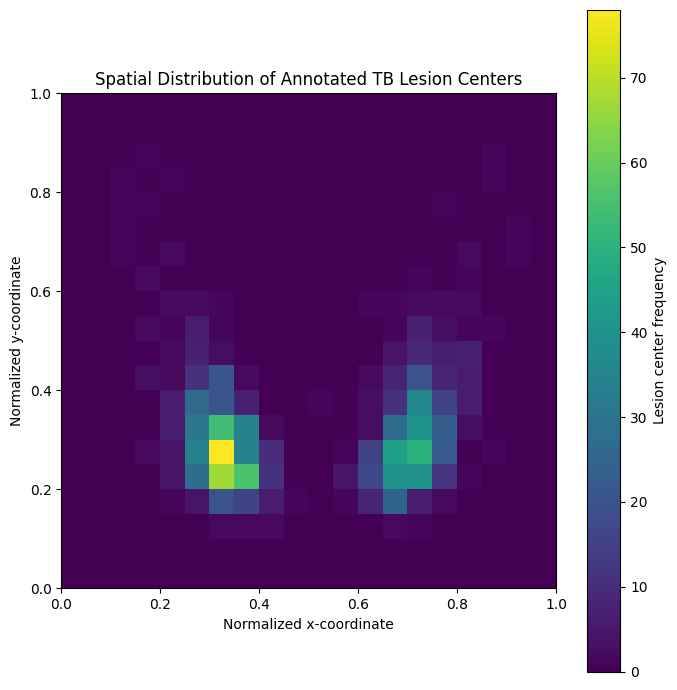

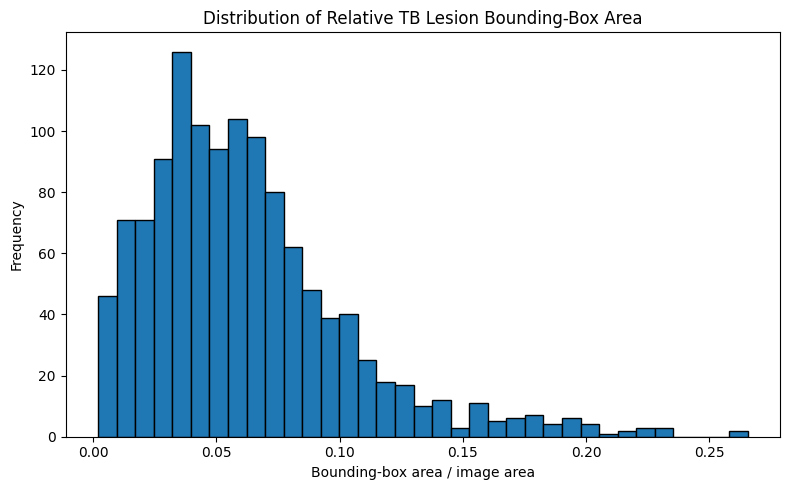


EXACT DUPLICATE / SPLIT LEAKAGE AUDIT
Exact duplicate image rows: 0
Exact duplicates crossing splits: 0

Potential near-duplicate train↔validation pairs (dHash distance ≤4): 83


,train_image,val_image,hamming_distance
0,tb1014.png,tb0754.png,3
1,tb0311.png,tb0467.png,2
2,tb0140.png,tb0297.png,2
3,tb0140.png,tb0015.png,4
4,tb0996.png,tb0231.png,4
5,tb0226.png,tb0635.png,2
6,tb0480.png,tb0365.png,4
7,tb0447.png,tb1028.png,4
8,tb1055.png,tb0297.png,3
9,tb1055.png,tb0009.png,4



IMAGE QUALITY STATISTICS


brightness                          contrast                       \
             mean        std      median       mean       std     median   
split                                                                      
train  132.072810  15.815528  134.213184  69.765701  6.399439  69.754940   
val    131.213305  15.876231  133.052788  69.988696  6.481327  69.884382   

        sharpness                          entropy                      
             mean        std      median      mean       std    median  
split                                                                   
train  187.850068  108.97043  195.380761  7.407626  0.209772  7.449506  
val    195.083243  128.54826  189.888006  7.387627  0.264407  7.452299

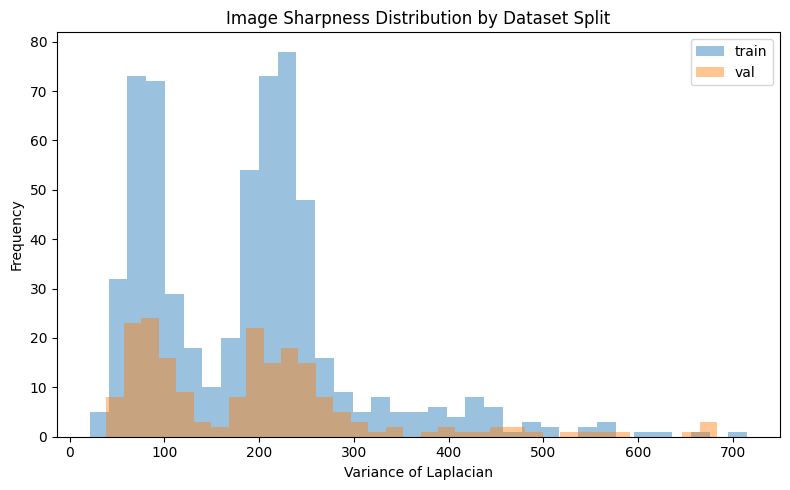


LINEAR ALGEBRA — IMAGE MATRIX + SVD
Image matrix X shape: (300, 4096)
Mathematical space: X ∈ R^(300 × 4096)

Top 10 singular values:
[86.3698 75.3522 59.2984 55.2946 45.4571 40.1615 35.7379 33.6088 30.6425
 26.8579]
Components needed for 80% variance: 26
Components needed for 90% variance: 64
Components needed for 95% variance: 118


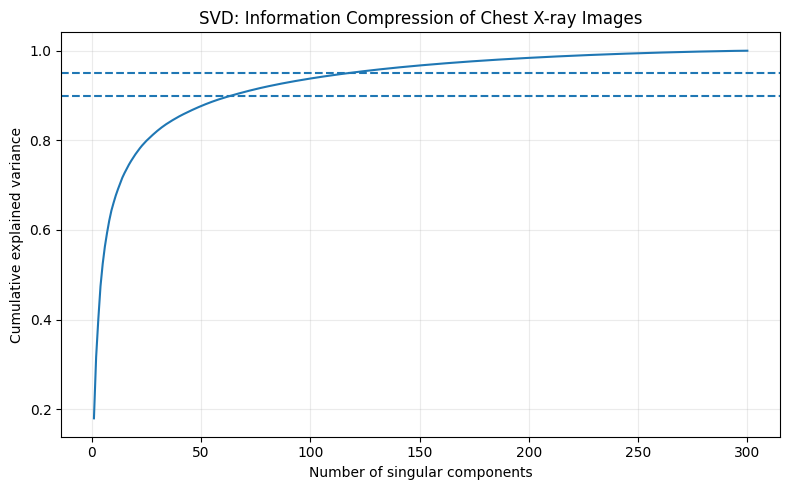

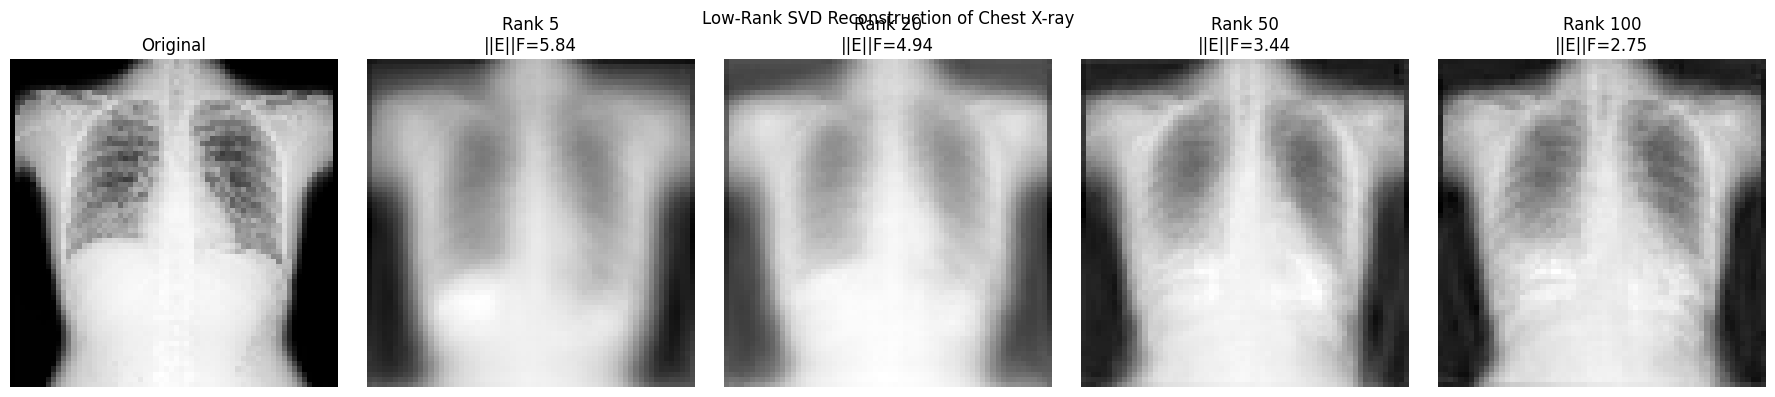


PCA explained variance by first 10 components:
[0.1795 0.1366 0.0846 0.0736 0.0497 0.0388 0.0307 0.0272 0.0226 0.0174]


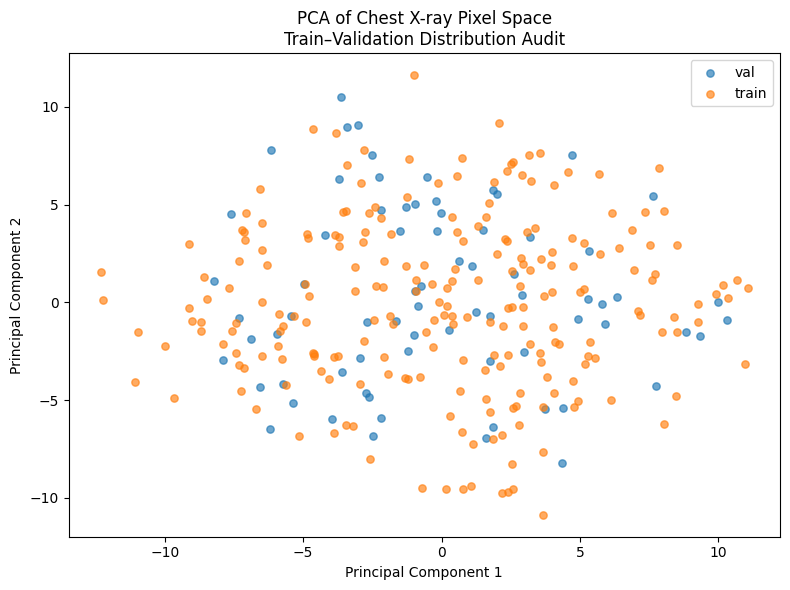


CALCULUS — IMAGE GRADIENT ANALYSIS


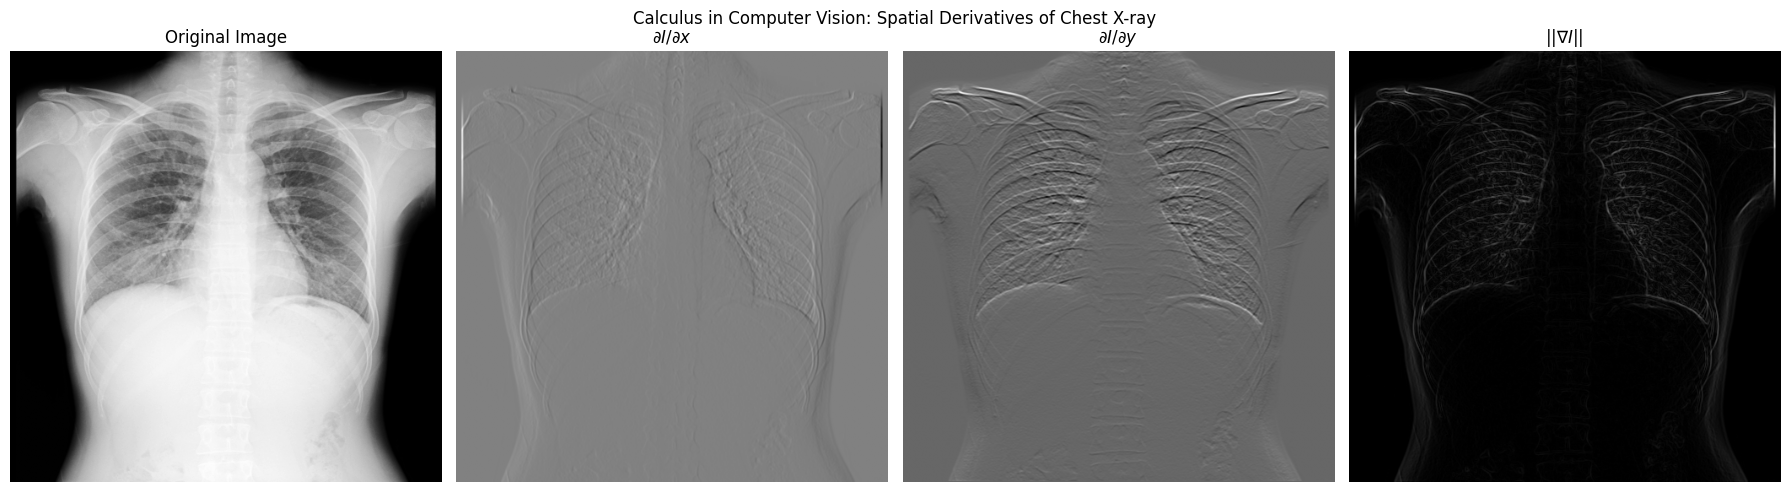


Lesion vs background gradient-energy summary:


,lesion_gradient,background_gradient,gradient_ratio
count,799.000000,799.000000,799.000000
mean,0.174574,0.115872,1.523977
std,0.041851,0.025543,0.267476
min,0.056033,0.052687,0.874202
25%,0.140645,0.094639,1.335585
50%,0.168492,0.114469,1.488719
75%,0.206965,0.138576,1.669284
max,0.309753,0.174960,2.571693


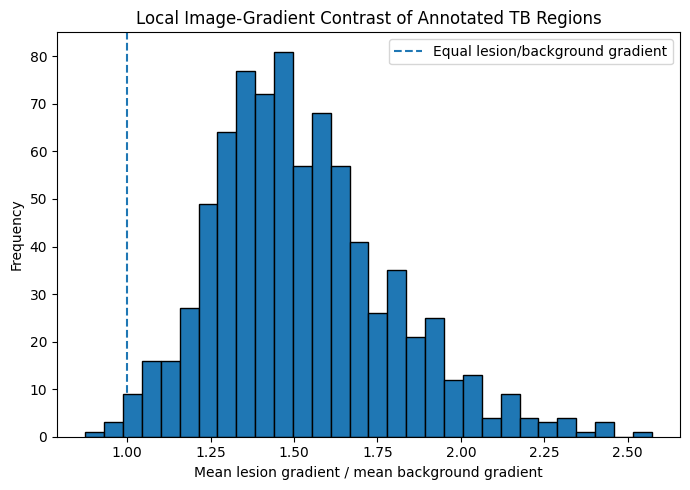

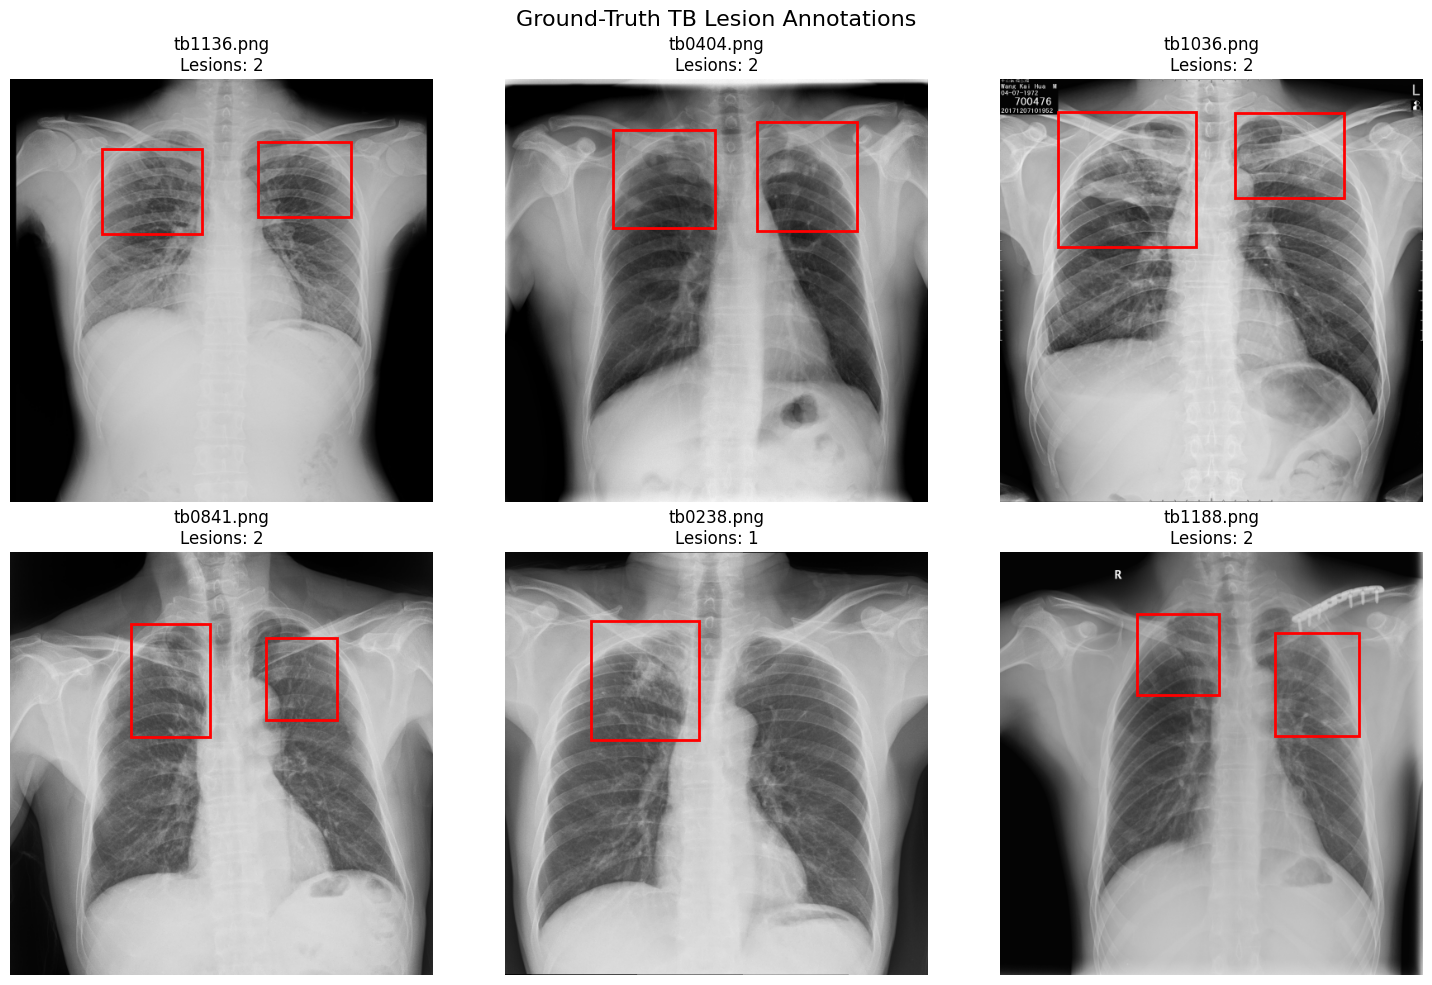


RESEARCH-GRADE AUDIT SUMMARY
Total images                : 799
Total annotated lesions     : 1,211
Images without lesions      : 0
Images with multiple lesions: 382
Invalid normalized boxes    : 0
Out-of-image boxes          : 0
Exact cross-split duplicates: 0
Potential near duplicates   : 83
SVD matrix                  : (300, 4096)
PCA components evaluated    : 50
Gradient-analysis images    : 799

Files saved to:
/kaggle/working/TB_XAI_Advanced

NEXT HIGH-LEVEL MODELING STAGES
✓ Advanced dataset reconstruction
✓ Annotation integrity audit
✓ Exact + perceptual leakage audit
✓ Linear Algebra: SVD
✓ Low-rank approximation
✓ PCA distribution-shift analysis
✓ Calculus: image partial derivatives
✓ Lesion-vs-background gradient analysis

NEXT:
1. Build OWN train/validation/test split
2. DenseNet121 / ConvNeXt classifier
3. Mathematical backpropagation experiment
4. Calibration + Brier score + ECE
5. Custom Grad-CAM WITHOUT external grad-cam package
6. Grad-CAM localization-vs-ground-truth

45766

In [2]:
# ============================================================
# TB-XAI
# ADVANCED STAGE 2–5
#
# 2. Reconstruct YOLO detection dataset
# 3. Data integrity + leakage audit
# 4. Linear Algebra: SVD/PCA + low-rank reconstruction
# 5. Calculus/CV: spatial image gradients + lesion geometry
#
# NO pip install
# NO ultralytics required
# ============================================================

import os
import gc
import cv2
import math
import hashlib
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# 1. LOCATE PROJECT AUTOMATICALLY
# ============================================================

KAGGLE_INPUT = Path("/kaggle/input")

tbx_dirs = list(
    KAGGLE_INPUT.rglob("tbx_yolo")
)

if len(tbx_dirs) == 0:
    raise FileNotFoundError(
        "Could not find 'tbx_yolo' directory."
    )

YOLO_ROOT = tbx_dirs[0]

IMAGE_ROOT = YOLO_ROOT / "images"
LABEL_ROOT = YOLO_ROOT / "labels"

print("=" * 80)
print("TB-XAI — ADVANCED DATASET AUDIT")
print("=" * 80)

print(f"YOLO root  : {YOLO_ROOT}")
print(f"Images     : {IMAGE_ROOT}")
print(f"Labels     : {LABEL_ROOT}")


# ============================================================
# 2. OUTPUT FOLDERS
# ============================================================

OUTPUT_ROOT = Path(
    "/kaggle/working/TB_XAI_Advanced"
)

FIG_DIR = OUTPUT_ROOT / "figures"
TABLE_DIR = OUTPUT_ROOT / "tables"
MATH_DIR = OUTPUT_ROOT / "mathematics"

for d in [
    OUTPUT_ROOT,
    FIG_DIR,
    TABLE_DIR,
    MATH_DIR
]:
    d.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 3. FIND TRAIN / VALIDATION SPLITS
# ============================================================

possible_splits = [
    "train",
    "val",
    "valid",
    "validation",
    "test"
]

available_splits = []

for split in possible_splits:

    img_dir = IMAGE_ROOT / split

    if img_dir.exists():

        available_splits.append(
            split
        )

print("\nAvailable splits:")
print(available_splits)

if "test" not in available_splits:

    print(
        "\n⚠ IMPORTANT:"
        "\nNo independent TEST split detected."
        "\nFor publication-grade evaluation, "
        "an untouched test set should be created "
        "from the original raw dataset."
    )


# ============================================================
# 4. IMAGE EXTENSIONS
# ============================================================

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}


# ============================================================
# 5. READ YOLO LABEL FILE
# ============================================================

def read_yolo_labels(label_path):
    """
    Standard YOLO format:
    class_id x_center y_center width height

    Coordinates are normalized to [0, 1].
    """

    records = []

    if not label_path.exists():
        return records

    text = label_path.read_text().strip()

    if text == "":
        return records

    for line in text.splitlines():

        parts = line.strip().split()

        if len(parts) < 5:
            continue

        try:

            class_id = int(float(parts[0]))

            xc = float(parts[1])
            yc = float(parts[2])
            bw = float(parts[3])
            bh = float(parts[4])

            records.append({
                "class_id": class_id,
                "xc": xc,
                "yc": yc,
                "bw": bw,
                "bh": bh
            })

        except:
            continue

    return records


# ============================================================
# 6. RECONSTRUCT IMAGE-LEVEL + BOX-LEVEL DATA
# ============================================================

image_records = []
box_records = []

for split in available_splits:

    image_dir = IMAGE_ROOT / split
    label_dir = LABEL_ROOT / split

    image_files = [
        p
        for p in image_dir.rglob("*")
        if (
            p.is_file()
            and p.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    ]

    for img_path in image_files:

        img = cv2.imread(
            str(img_path),
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            continue

        h, w = img.shape[:2]

        label_path = (
            label_dir
            / f"{img_path.stem}.txt"
        )

        boxes = read_yolo_labels(
            label_path
        )

        image_records.append({

            "split":
                split,

            "filename":
                img_path.name,

            "stem":
                img_path.stem,

            "image_path":
                str(img_path),

            "label_path":
                str(label_path),

            "width":
                w,

            "height":
                h,

            "aspect_ratio":
                w / h,

            "n_boxes":
                len(boxes),

            "has_label_file":
                label_path.exists()
        })

        for box_id, box in enumerate(boxes):

            xc = box["xc"]
            yc = box["yc"]
            bw = box["bw"]
            bh = box["bh"]

            x1 = xc - bw / 2
            y1 = yc - bh / 2

            x2 = xc + bw / 2
            y2 = yc + bh / 2

            area_norm = bw * bh

            aspect_box = (
                bw / bh
                if bh > 0
                else np.nan
            )

            box_records.append({

                "split":
                    split,

                "filename":
                    img_path.name,

                "class_id":
                    box["class_id"],

                "xc":
                    xc,

                "yc":
                    yc,

                "bw":
                    bw,

                "bh":
                    bh,

                "x1":
                    x1,

                "y1":
                    y1,

                "x2":
                    x2,

                "y2":
                    y2,

                "bbox_area_fraction":
                    area_norm,

                "bbox_aspect_ratio":
                    aspect_box,

                "bbox_area_pixels":
                    area_norm * w * h,

                "image_width":
                    w,

                "image_height":
                    h,

                "valid_normalized":
                    (
                        0 <= xc <= 1
                        and
                        0 <= yc <= 1
                        and
                        0 < bw <= 1
                        and
                        0 < bh <= 1
                    ),

                "inside_image":
                    (
                        x1 >= 0
                        and
                        y1 >= 0
                        and
                        x2 <= 1
                        and
                        y2 <= 1
                    )
            })


image_df = pd.DataFrame(
    image_records
)

box_df = pd.DataFrame(
    box_records
)

print("\n" + "=" * 80)
print("RECONSTRUCTED DATASET")
print("=" * 80)

print(
    f"Images : {len(image_df):,}"
)

print(
    f"Boxes  : {len(box_df):,}"
)

print("\nImages by split:")

display(
    image_df["split"]
    .value_counts()
    .to_frame("Images")
)

print("\nBounding boxes by split:")

display(
    box_df["split"]
    .value_counts()
    .to_frame("Boxes")
)


# ============================================================
# 7. CLASS DISTRIBUTION
# ============================================================

print("\n" + "=" * 80)
print("YOLO CLASS DISTRIBUTION")
print("=" * 80)

if len(box_df) > 0:

    class_table = (
        box_df
        .groupby(
            ["split", "class_id"]
        )
        .size()
        .reset_index(
            name="n_boxes"
        )
    )

    display(
        class_table
    )


# ============================================================
# 8. ANNOTATION VALIDITY AUDIT
# ============================================================

print("\n" + "=" * 80)
print("ANNOTATION VALIDITY AUDIT")
print("=" * 80)

if len(box_df) > 0:

    print(
        "Invalid normalized boxes:",
        (~box_df["valid_normalized"]).sum()
    )

    print(
        "Boxes extending outside image:",
        (~box_df["inside_image"]).sum()
    )

    print(
        "Images without bounding boxes:",
        (image_df["n_boxes"] == 0).sum()
    )

    print(
        "Images with >1 lesion:",
        (image_df["n_boxes"] > 1).sum()
    )


# ============================================================
# 9. BOUNDING BOX GEOMETRY SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("LESION GEOMETRY")
print("=" * 80)

if len(box_df) > 0:

    geometry_cols = [
        "xc",
        "yc",
        "bw",
        "bh",
        "bbox_area_fraction",
        "bbox_aspect_ratio"
    ]

    geometry_summary = (
        box_df[geometry_cols]
        .describe(
            percentiles=[
                0.05,
                0.25,
                0.50,
                0.75,
                0.95
            ]
        )
        .T
    )

    display(
        geometry_summary
    )

    geometry_summary.to_csv(
        TABLE_DIR
        / "bbox_geometry_summary.csv"
    )


# ============================================================
# 10. BOOTSTRAP CI FOR MEAN LESION AREA
# ============================================================

def bootstrap_mean_ci(
    values,
    n_boot=3000,
    ci=0.95,
    seed=42
):

    values = np.asarray(values)

    values = values[
        np.isfinite(values)
    ]

    rng = np.random.default_rng(
        seed
    )

    boot_means = np.empty(
        n_boot
    )

    n = len(values)

    for i in range(n_boot):

        sample = rng.choice(
            values,
            size=n,
            replace=True
        )

        boot_means[i] = sample.mean()

    alpha = 1 - ci

    lower = np.quantile(
        boot_means,
        alpha / 2
    )

    upper = np.quantile(
        boot_means,
        1 - alpha / 2
    )

    return (
        values.mean(),
        lower,
        upper
    )


if len(box_df) > 0:

    mean_area, low_area, high_area = (
        bootstrap_mean_ci(
            box_df[
                "bbox_area_fraction"
            ].values
        )
    )

    print(
        "\nMean lesion-to-image area fraction:"
    )

    print(
        f"{mean_area:.4f} "
        f"(95% bootstrap CI "
        f"{low_area:.4f}–{high_area:.4f})"
    )


# ============================================================
# 11. LESION LOCATION HEATMAP
# ============================================================

if len(box_df) > 0:

    heatmap, xedges, yedges = np.histogram2d(

        box_df["xc"],
        box_df["yc"],

        bins=20,

        range=[
            [0, 1],
            [0, 1]
        ]
    )

    plt.figure(
        figsize=(7, 7)
    )

    plt.imshow(

        heatmap.T,

        origin="lower",

        extent=[
            0,
            1,
            0,
            1
        ],

        aspect="equal"
    )

    plt.colorbar(
        label="Lesion center frequency"
    )

    plt.xlabel(
        "Normalized x-coordinate"
    )

    plt.ylabel(
        "Normalized y-coordinate"
    )

    plt.title(
        "Spatial Distribution of Annotated TB Lesion Centers"
    )

    plt.tight_layout()

    plt.savefig(
        FIG_DIR
        / "lesion_center_heatmap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 12. BOX AREA DISTRIBUTION
# ============================================================

if len(box_df) > 0:

    plt.figure(
        figsize=(8, 5)
    )

    plt.hist(

        box_df[
            "bbox_area_fraction"
        ],

        bins=35,

        edgecolor="black"
    )

    plt.xlabel(
        "Bounding-box area / image area"
    )

    plt.ylabel(
        "Frequency"
    )

    plt.title(
        "Distribution of Relative TB Lesion Bounding-Box Area"
    )

    plt.tight_layout()

    plt.savefig(
        FIG_DIR
        / "bbox_area_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 13. EXACT DUPLICATE / DATA LEAKAGE AUDIT
# ============================================================

def md5_file(path):

    h = hashlib.md5()

    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            h.update(
                chunk
            )

    return h.hexdigest()


print("\n" + "=" * 80)
print("EXACT DUPLICATE / SPLIT LEAKAGE AUDIT")
print("=" * 80)

image_df[
    "md5"
] = image_df[
    "image_path"
].apply(
    md5_file
)

duplicate_hashes = (
    image_df[
        image_df.duplicated(
            "md5",
            keep=False
        )
    ]
    .sort_values(
        "md5"
    )
)

print(
    f"Exact duplicate image rows: "
    f"{len(duplicate_hashes)}"
)

cross_split_duplicate_hashes = []

for md5_value, group in image_df.groupby(
    "md5"
):

    if group["split"].nunique() > 1:

        cross_split_duplicate_hashes.append(
            md5_value
        )

print(
    "Exact duplicates crossing splits:",
    len(
        cross_split_duplicate_hashes
    )
)

if len(cross_split_duplicate_hashes) > 0:

    leakage_df = image_df[
        image_df[
            "md5"
        ].isin(
            cross_split_duplicate_hashes
        )
    ]

    display(
        leakage_df[
            [
                "split",
                "filename",
                "md5"
            ]
        ]
    )

    leakage_df.to_csv(
        TABLE_DIR
        / "exact_cross_split_duplicates.csv",
        index=False
    )


# ============================================================
# 14. PERCEPTUAL HASH FOR NEAR-DUPLICATES
#     dHash: image-appearance similarity
# ============================================================

def dhash_image(
    image_path,
    hash_size=8
):

    img = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        return None

    img = cv2.resize(
        img,
        (
            hash_size + 1,
            hash_size
        )
    )

    difference = (
        img[:, 1:]
        >
        img[:, :-1]
    )

    hash_value = 0

    for bit in difference.flatten():

        hash_value = (
            hash_value << 1
        ) | int(bit)

    return hash_value


def hamming_distance(
    hash1,
    hash2
):

    return (
        hash1 ^ hash2
    ).bit_count()


image_df[
    "dhash"
] = image_df[
    "image_path"
].apply(
    dhash_image
)

train_rows = image_df[
    image_df["split"] == "train"
].copy()

val_names = [
    s
    for s in available_splits
    if s in [
        "val",
        "valid",
        "validation"
    ]
]

if len(val_names) > 0:

    val_rows = image_df[
        image_df["split"].isin(
            val_names
        )
    ].copy()

    near_duplicate_pairs = []

    for _, train_row in train_rows.iterrows():

        if train_row["dhash"] is None:
            continue

        for _, val_row in val_rows.iterrows():

            if val_row["dhash"] is None:
                continue

            distance = hamming_distance(

                train_row["dhash"],
                val_row["dhash"]
            )

            if distance <= 4:

                near_duplicate_pairs.append({

                    "train_image":
                        train_row["filename"],

                    "val_image":
                        val_row["filename"],

                    "hamming_distance":
                        distance
                })

    near_duplicate_df = pd.DataFrame(
        near_duplicate_pairs
    )

    print(
        "\nPotential near-duplicate "
        "train↔validation pairs "
        "(dHash distance ≤4):",
        len(near_duplicate_df)
    )

    if len(near_duplicate_df) > 0:

        display(
            near_duplicate_df.head(
                30
            )
        )

        near_duplicate_df.to_csv(
            TABLE_DIR
            / "near_duplicate_cross_split_pairs.csv",
            index=False
        )


# ============================================================
# 15. IMAGE QUALITY METRICS
#
# Brightness = mean pixel intensity
# Contrast   = standard deviation
# Sharpness  = variance of Laplacian
# Entropy    = information-content proxy
# ============================================================

def image_entropy(
    gray
):

    hist = cv2.calcHist(
        [gray],
        [0],
        None,
        [256],
        [0, 256]
    ).ravel()

    probabilities = (
        hist
        / hist.sum()
    )

    probabilities = probabilities[
        probabilities > 0
    ]

    return float(
        -np.sum(
            probabilities
            * np.log2(
                probabilities
            )
        )
    )


def image_quality_metrics(
    image_path
):

    img = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:

        return {
            "brightness": np.nan,
            "contrast": np.nan,
            "sharpness": np.nan,
            "entropy": np.nan
        }

    brightness = float(
        np.mean(img)
    )

    contrast = float(
        np.std(img)
    )

    sharpness = float(
        cv2.Laplacian(
            img,
            cv2.CV_64F
        ).var()
    )

    entropy = image_entropy(
        img
    )

    return {
        "brightness":
            brightness,

        "contrast":
            contrast,

        "sharpness":
            sharpness,

        "entropy":
            entropy
    }


quality_records = []

for _, row in image_df.iterrows():

    q = image_quality_metrics(
        row["image_path"]
    )

    quality_records.append(
        q
    )

quality_df = pd.DataFrame(
    quality_records
)

image_df = pd.concat(
    [
        image_df.reset_index(
            drop=True
        ),
        quality_df
    ],
    axis=1
)


print("\n" + "=" * 80)
print("IMAGE QUALITY STATISTICS")
print("=" * 80)

quality_summary = (
    image_df.groupby(
        "split"
    )[
        [
            "brightness",
            "contrast",
            "sharpness",
            "entropy"
        ]
    ]
    .agg(
        [
            "mean",
            "std",
            "median"
        ]
    )
)

display(
    quality_summary
)


# ============================================================
# 16. IMAGE QUALITY DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(8, 5)
)

for split in available_splits:

    subset = image_df[
        image_df["split"] == split
    ]

    plt.hist(

        subset["sharpness"],

        bins=35,

        alpha=0.45,

        label=split
    )

plt.xlabel(
    "Variance of Laplacian"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Image Sharpness Distribution by Dataset Split"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR
    / "image_sharpness_by_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 17. LINEAR ALGEBRA
#     BUILD IMAGE MATRIX X
#
# Each 64x64 image becomes a vector in R^4096
# X shape = n_images × 4096
# ============================================================

print("\n" + "=" * 80)
print("LINEAR ALGEBRA — IMAGE MATRIX + SVD")
print("=" * 80)

MAX_SVD_IMAGES = min(
    300,
    len(image_df)
)

svd_sample = image_df.sample(

    n=MAX_SVD_IMAGES,

    random_state=SEED
)

X_list = []

for path in svd_sample[
    "image_path"
]:

    img = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

    img = cv2.resize(
        img,
        (64, 64)
    )

    img = (
        img.astype(
            np.float32
        )
        / 255.0
    )

    X_list.append(
        img.flatten()
    )

X = np.vstack(
    X_list
)

print(
    "Image matrix X shape:",
    X.shape
)

print(
    f"Mathematical space: "
    f"X ∈ R^({X.shape[0]} × {X.shape[1]})"
)


# ============================================================
# 18. CENTER MATRIX
# ============================================================

mean_vector = X.mean(
    axis=0
)

X_centered = (
    X
    - mean_vector
)


# ============================================================
# 19. SINGULAR VALUE DECOMPOSITION
#
# X = U Σ V^T
# ============================================================

U, S, Vt = np.linalg.svd(

    X_centered,

    full_matrices=False
)

explained_variance = (
    S ** 2
)

explained_variance_ratio = (
    explained_variance
    /
    explained_variance.sum()
)

cumulative_variance = np.cumsum(
    explained_variance_ratio
)


print(
    "\nTop 10 singular values:"
)

print(
    np.round(
        S[:10],
        4
    )
)


for target in [
    0.80,
    0.90,
    0.95
]:

    n_components = (
        np.argmax(
            cumulative_variance
            >= target
        )
        + 1
    )

    print(
        f"Components needed for "
        f"{target*100:.0f}% variance: "
        f"{n_components}"
    )


# ============================================================
# 20. SVD CUMULATIVE VARIANCE PLOT
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    np.arange(
        1,
        len(
            cumulative_variance
        )
        + 1
    ),
    cumulative_variance
)

plt.axhline(
    0.90,
    linestyle="--"
)

plt.axhline(
    0.95,
    linestyle="--"
)

plt.xlabel(
    "Number of singular components"
)

plt.ylabel(
    "Cumulative explained variance"
)

plt.title(
    "SVD: Information Compression of Chest X-ray Images"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    MATH_DIR
    / "svd_cumulative_variance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. LOW-RANK MATRIX APPROXIMATION
#
# X_k = U_k Σ_k V_k^T
#
# Demonstrates Eckart–Young approximation.
# ============================================================

example_index = 0

original_vector = (
    X_centered[
        example_index
    ]
)

ranks = [
    5,
    20,
    50,
    100
]

fig, axes = plt.subplots(
    1,
    len(ranks) + 1,
    figsize=(18, 4)
)

original_image = (
    original_vector
    + mean_vector
).reshape(
    64,
    64
)

axes[0].imshow(
    original_image,
    cmap="gray"
)

axes[0].set_title(
    "Original"
)

axes[0].axis(
    "off"
)

for j, rank in enumerate(
    ranks,
    start=1
):

    rank = min(
        rank,
        len(S)
    )

    reconstructed_centered = (
        U[
            example_index,
            :rank
        ]
        @
        np.diag(
            S[:rank]
        )
        @
        Vt[
            :rank,
            :
        ]
    )

    reconstructed = (
        reconstructed_centered
        + mean_vector
    ).reshape(
        64,
        64
    )

    reconstruction_error = np.linalg.norm(

        original_image
        - reconstructed,

        ord="fro"
    )

    axes[j].imshow(
        reconstructed,
        cmap="gray"
    )

    axes[j].set_title(
        f"Rank {rank}\n"
        f"||E||F={reconstruction_error:.2f}"
    )

    axes[j].axis(
        "off"
    )

plt.suptitle(
    "Low-Rank SVD Reconstruction of Chest X-ray"
)

plt.tight_layout()

plt.savefig(
    MATH_DIR
    / "svd_low_rank_reconstruction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. PCA OF IMAGE SPACE
# ============================================================

N_PCA = min(
    50,
    X.shape[0] - 1,
    X.shape[1]
)

pca = PCA(
    n_components=N_PCA,
    random_state=SEED
)

X_pca = pca.fit_transform(
    X_centered
)


print(
    "\nPCA explained variance "
    "by first 10 components:"
)

print(
    np.round(
        pca.explained_variance_ratio_[
            :10
        ],
        4
    )
)


# ============================================================
# 23. PCA SCATTER — CHECK SPLIT DISTRIBUTION
#
# Useful for detecting train/validation distribution shift.
# ============================================================

plt.figure(
    figsize=(8, 6)
)

sample_splits = (
    svd_sample[
        "split"
    ]
    .reset_index(
        drop=True
    )
)

for split in sample_splits.unique():

    mask = (
        sample_splits
        == split
    )

    plt.scatter(

        X_pca[
            mask,
            0
        ],

        X_pca[
            mask,
            1
        ],

        s=28,

        alpha=0.65,

        label=split
    )

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "PCA of Chest X-ray Pixel Space\n"
    "Train–Validation Distribution Audit"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    MATH_DIR
    / "pca_train_validation_shift.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 24. CALCULUS / COMPUTER VISION
#
# Image gradient:
#
# ∇I = [∂I/∂x, ∂I/∂y]
#
# magnitude:
#
# ||∇I|| = sqrt(
#     (∂I/∂x)^2 +
#     (∂I/∂y)^2
# )
# ============================================================

print("\n" + "=" * 80)
print("CALCULUS — IMAGE GRADIENT ANALYSIS")
print("=" * 80)

candidate_images = (
    image_df[
        image_df["n_boxes"] > 0
    ]
)

if len(candidate_images) > 0:

    sample_row = candidate_images.sample(
        1,
        random_state=SEED
    ).iloc[0]

    image_path = sample_row[
        "image_path"
    ]

    filename = sample_row[
        "filename"
    ]

    gray = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    gray_float = (
        gray.astype(
            np.float32
        )
        / 255.0
    )

    # First partial derivative dI/dx
    grad_x = cv2.Sobel(

        gray_float,

        cv2.CV_32F,

        1,
        0,

        ksize=3
    )

    # First partial derivative dI/dy
    grad_y = cv2.Sobel(

        gray_float,

        cv2.CV_32F,

        0,
        1,

        ksize=3
    )

    gradient_magnitude = np.sqrt(

        grad_x ** 2
        +
        grad_y ** 2
    )

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(18, 5)
    )

    axes[0].imshow(
        gray,
        cmap="gray"
    )

    axes[0].set_title(
        "Original Image"
    )

    axes[1].imshow(
        grad_x,
        cmap="gray"
    )

    axes[1].set_title(
        r"$\partial I / \partial x$"
    )

    axes[2].imshow(
        grad_y,
        cmap="gray"
    )

    axes[2].set_title(
        r"$\partial I / \partial y$"
    )

    axes[3].imshow(
        gradient_magnitude,
        cmap="gray"
    )

    axes[3].set_title(
        r"$||\nabla I||$"
    )

    for ax in axes:
        ax.axis(
            "off"
        )

    plt.suptitle(
        "Calculus in Computer Vision: "
        "Spatial Derivatives of Chest X-ray"
    )

    plt.tight_layout()

    plt.savefig(
        MATH_DIR
        / "image_gradient_calculus.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 25. LESION vs BACKGROUND GRADIENT ENERGY
#
# For each annotated lesion:
# compare average gradient magnitude inside bbox
# versus outside bbox.
#
# This connects calculus directly to the
# annotated medical-image problem.
# ============================================================

gradient_energy_records = []

for _, img_row in image_df.iterrows():

    filename = img_row[
        "filename"
    ]

    image_boxes = box_df[
        box_df["filename"]
        == filename
    ]

    if len(image_boxes) == 0:
        continue

    gray = cv2.imread(
        img_row[
            "image_path"
        ],
        cv2.IMREAD_GRAYSCALE
    )

    if gray is None:
        continue

    gray_float = (
        gray.astype(
            np.float32
        )
        / 255.0
    )

    gx = cv2.Sobel(
        gray_float,
        cv2.CV_32F,
        1,
        0,
        ksize=3
    )

    gy = cv2.Sobel(
        gray_float,
        cv2.CV_32F,
        0,
        1,
        ksize=3
    )

    grad = np.sqrt(
        gx ** 2
        +
        gy ** 2
    )

    h, w = gray.shape

    lesion_mask = np.zeros(
        (h, w),
        dtype=bool
    )

    for _, b in image_boxes.iterrows():

        x1 = int(
            max(
                0,
                b["x1"] * w
            )
        )

        y1 = int(
            max(
                0,
                b["y1"] * h
            )
        )

        x2 = int(
            min(
                w,
                b["x2"] * w
            )
        )

        y2 = int(
            min(
                h,
                b["y2"] * h
            )
        )

        lesion_mask[
            y1:y2,
            x1:x2
        ] = True

    if lesion_mask.sum() == 0:
        continue

    lesion_gradient = float(
        grad[
            lesion_mask
        ].mean()
    )

    background_gradient = float(
        grad[
            ~lesion_mask
        ].mean()
    )

    gradient_energy_records.append({

        "split":
            img_row["split"],

        "filename":
            filename,

        "lesion_gradient":
            lesion_gradient,

        "background_gradient":
            background_gradient,

        "gradient_ratio":
            lesion_gradient
            /
            (
                background_gradient
                + 1e-8
            )
    })


gradient_df = pd.DataFrame(
    gradient_energy_records
)

if len(gradient_df) > 0:

    print(
        "\nLesion vs background "
        "gradient-energy summary:"
    )

    display(
        gradient_df[
            [
                "lesion_gradient",
                "background_gradient",
                "gradient_ratio"
            ]
        ]
        .describe()
    )

    gradient_df.to_csv(
        TABLE_DIR
        / "lesion_vs_background_gradient.csv",
        index=False
    )

    plt.figure(
        figsize=(7, 5)
    )

    plt.hist(
        gradient_df[
            "gradient_ratio"
        ],
        bins=30,
        edgecolor="black"
    )

    plt.axvline(
        1.0,
        linestyle="--",
        label="Equal lesion/background gradient"
    )

    plt.xlabel(
        "Mean lesion gradient / mean background gradient"
    )

    plt.ylabel(
        "Frequency"
    )

    plt.title(
        "Local Image-Gradient Contrast of Annotated TB Regions"
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        MATH_DIR
        / "lesion_gradient_ratio.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 26. VISUALIZE REAL YOLO ANNOTATIONS
# ============================================================

positive_images = image_df[
    image_df["n_boxes"] > 0
]

if len(positive_images) >= 6:

    examples = positive_images.sample(
        6,
        random_state=SEED
    )

else:

    examples = positive_images


if len(examples) > 0:

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 10)
    )

    axes = axes.flatten()

    for ax in axes:
        ax.axis(
            "off"
        )

    for ax, (_, row) in zip(
        axes,
        examples.iterrows()
    ):

        img = cv2.imread(
            row["image_path"]
        )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        h, w = img.shape[:2]

        ax.imshow(
            img
        )

        boxes = box_df[
            box_df[
                "filename"
            ]
            ==
            row[
                "filename"
            ]
        ]

        for _, b in boxes.iterrows():

            x1 = (
                b["x1"] * w
            )

            y1 = (
                b["y1"] * h
            )

            bw = (
                b["bw"] * w
            )

            bh = (
                b["bh"] * h
            )

            rect = patches.Rectangle(

                (
                    x1,
                    y1
                ),

                bw,
                bh,

                linewidth=2,

                edgecolor="red",

                facecolor="none"
            )

            ax.add_patch(
                rect
            )

        ax.set_title(
            f"{row['filename']}\n"
            f"Lesions: {row['n_boxes']}"
        )

        ax.axis(
            "off"
        )

    plt.suptitle(
        "Ground-Truth TB Lesion Annotations",
        fontsize=16
    )

    plt.tight_layout()

    plt.savefig(
        FIG_DIR
        / "ground_truth_tb_boxes.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 27. SAVE MASTER TABLES
# ============================================================

image_df.to_csv(
    TABLE_DIR
    / "tbx_image_level_master.csv",
    index=False
)

box_df.to_csv(
    TABLE_DIR
    / "tbx_box_level_master.csv",
    index=False
)


# ============================================================
# 28. RESEARCH-GRADE AUDIT SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("RESEARCH-GRADE AUDIT SUMMARY")
print("=" * 80)

print(
    f"Total images                : "
    f"{len(image_df):,}"
)

print(
    f"Total annotated lesions     : "
    f"{len(box_df):,}"
)

print(
    f"Images without lesions      : "
    f"{(image_df['n_boxes']==0).sum():,}"
)

print(
    f"Images with multiple lesions: "
    f"{(image_df['n_boxes']>1).sum():,}"
)

if len(box_df) > 0:

    print(
        f"Invalid normalized boxes    : "
        f"{(~box_df['valid_normalized']).sum():,}"
    )

    print(
        f"Out-of-image boxes          : "
        f"{(~box_df['inside_image']).sum():,}"
    )

print(
    f"Exact cross-split duplicates: "
    f"{len(cross_split_duplicate_hashes):,}"
)

if "near_duplicate_df" in globals():

    print(
        f"Potential near duplicates   : "
        f"{len(near_duplicate_df):,}"
    )

print(
    f"SVD matrix                  : "
    f"{X.shape}"
)

print(
    f"PCA components evaluated    : "
    f"{N_PCA}"
)

print(
    f"Gradient-analysis images    : "
    f"{len(gradient_df):,}"
)

print(
    "\nFiles saved to:"
)

print(
    OUTPUT_ROOT
)

print("\n" + "=" * 80)
print("NEXT HIGH-LEVEL MODELING STAGES")
print("=" * 80)

print(
    "✓ Advanced dataset reconstruction"
)

print(
    "✓ Annotation integrity audit"
)

print(
    "✓ Exact + perceptual leakage audit"
)

print(
    "✓ Linear Algebra: SVD"
)

print(
    "✓ Low-rank approximation"
)

print(
    "✓ PCA distribution-shift analysis"
)

print(
    "✓ Calculus: image partial derivatives"
)

print(
    "✓ Lesion-vs-background gradient analysis"
)

print(
    "\nNEXT:"
)

print(
    "1. Build OWN train/validation/test split"
)

print(
    "2. DenseNet121 / ConvNeXt classifier"
)

print(
    "3. Mathematical backpropagation experiment"
)

print(
    "4. Calibration + Brier score + ECE"
)

print(
    "5. Custom Grad-CAM WITHOUT external grad-cam package"
)

print(
    "6. Grad-CAM localization-vs-ground-truth IoU"
)

print(
    "7. Bootstrap AUROC / sensitivity CIs"
)

print(
    "8. Failure-case / false-positive analysis"
)

print(
    "9. YOLO localization"
)

print(
    "10. Streamlit research prototype"
)

print("=" * 80)

gc.collect()

TB-XAI — STAGE 6
LEAKAGE-SAFE DATA SPLITTING
Images available : 799
Lesion boxes     : 1,211

Searching for perceptually similar images...
Near-duplicate similarity edges: 197

Unique perceptual groups : 670
Groups containing >1 image: 21
Largest group size       : 99

Searching for optimal leakage-safe split...

LEAKAGE VERIFICATION
Duplicate groups crossing splits: 0

FINAL SPLIT


,Images,Percent
final_split,,
train,580,72.59
val,113,14.14
test,106,13.27



Lesion-count distribution (%):


lesion_count_category,1 lesion,2 lesions,3+ lesions
final_split,,,
test,50.00,46.23,3.77
train,52.41,44.48,3.10
val,53.10,42.48,4.42



Mean lesion-area balance:


,mean,std,median
final_split,,,
test,0.063792,0.040489,0.056599
train,0.058126,0.035505,0.052487
val,0.060037,0.039961,0.050263



Image-quality balance:


,brightness,contrast,sharpness,entropy
final_split,,,,
test,131.320567,69.704094,195.397251,7.398010
train,132.441685,69.865548,189.086858,7.405728
val,129.363868,69.705684,187.224369,7.390990


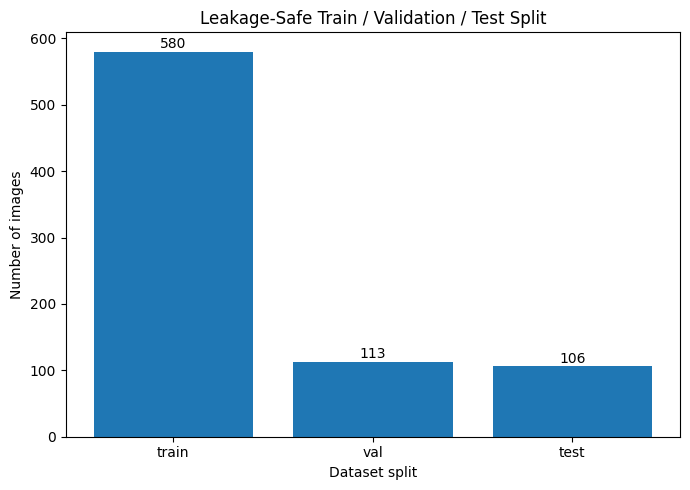

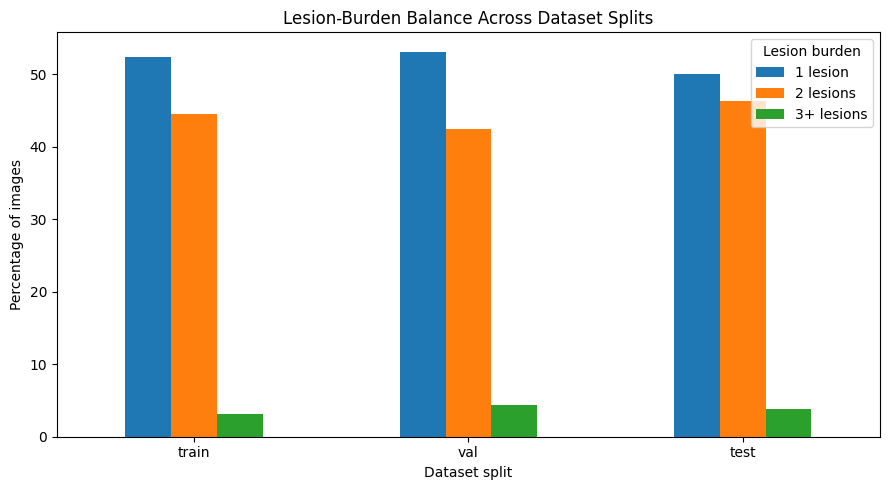


STAGE 6 COMPLETE
Original images       : 799
Train                 : 580
Validation            : 113
Test                  : 106
Perceptual groups     : 670
Cross-split groups    : 0
Copied images         : 799
Copied labels         : 799

Clean YOLO dataset:
/kaggle/working/TB_XAI_CleanSplit

Dataset YAML:
/kaggle/working/TB_XAI_CleanSplit/tb_xai.yaml

Split manifest:
/kaggle/working/TB_XAI_CleanSplit/split_manifest.csv

NEXT ANALYSES
✓ Stage 6: leakage-safe split complete
NEXT Stage 7: mathematical backpropagation from scratch
NEXT Stage 8: DenseNet121 / ConvNeXt training
NEXT Stage 9: bootstrap AUROC + calibration + ECE
NEXT Stage 10: custom Grad-CAM from scratch
NEXT Stage 11: Grad-CAM vs ground-truth localization
NEXT Stage 12: YOLO lesion detection
NEXT Stage 13: failure-mode analysis
NEXT Stage 14: Streamlit research app


In [3]:
# ============================================================
# TB-XAI
# STAGE 6
# LEAKAGE-SAFE TRAIN / VALIDATION / TEST SPLIT
#
# Key idea:
# Near-duplicate images must stay in the SAME split.
#
# Output:
# /kaggle/working/TB_XAI_CleanSplit/
#       images/train
#       images/val
#       images/test
#       labels/train
#       labels/val
#       labels/test
#
# ============================================================

import os
import cv2
import math
import shutil
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit


# ============================================================
# 1. SETTINGS
# ============================================================

SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

DHASH_THRESHOLD = 4

random.seed(SEED)
np.random.seed(SEED)


# ============================================================
# 2. CHECK PREVIOUS OBJECTS
# ============================================================

required_objects = [
    "image_df",
    "box_df",
    "YOLO_ROOT"
]

missing_objects = [
    x
    for x in required_objects
    if x not in globals()
]

if missing_objects:

    raise RuntimeError(
        "Please run the previous Advanced Audit cell first.\n"
        f"Missing objects: {missing_objects}"
    )


print("=" * 85)
print("TB-XAI — STAGE 6")
print("LEAKAGE-SAFE DATA SPLITTING")
print("=" * 85)

print(
    f"Images available : {len(image_df):,}"
)

print(
    f"Lesion boxes     : {len(box_df):,}"
)


# ============================================================
# 3. dHASH FUNCTION
# ============================================================

def compute_dhash(
    image_path,
    hash_size=8
):

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        return None

    resized = cv2.resize(
        image,
        (
            hash_size + 1,
            hash_size
        )
    )

    difference = (
        resized[:, 1:]
        >
        resized[:, :-1]
    )

    hash_value = 0

    for bit in difference.flatten():

        hash_value = (
            hash_value << 1
        ) | int(bit)

    return hash_value


def hamming_distance(
    hash1,
    hash2
):

    return (
        hash1 ^ hash2
    ).bit_count()


# ============================================================
# 4. RECOMPUTE dHASH IF NEEDED
# ============================================================

if (
    "dhash" not in image_df.columns
    or
    image_df["dhash"].isna().any()
):

    print(
        "\nComputing perceptual hashes..."
    )

    image_df[
        "dhash"
    ] = image_df[
        "image_path"
    ].apply(
        compute_dhash
    )


# ============================================================
# 5. UNION-FIND
#
# Images with similar perceptual hashes become
# members of the SAME connected component.
#
# If:
# A ~ B
# and
# B ~ C
#
# then:
# A, B, C stay in same split.
# ============================================================

n_images = len(
    image_df
)

parent = list(
    range(
        n_images
    )
)

rank = [
    0
] * n_images


def find(x):

    while parent[x] != x:

        parent[x] = parent[
            parent[x]
        ]

        x = parent[x]

    return x


def union(a, b):

    root_a = find(a)
    root_b = find(b)

    if root_a == root_b:
        return

    if rank[root_a] < rank[root_b]:

        parent[root_a] = root_b

    elif rank[root_a] > rank[root_b]:

        parent[root_b] = root_a

    else:

        parent[root_b] = root_a

        rank[root_a] += 1


# ============================================================
# 6. CONNECT NEAR-DUPLICATES
# ============================================================

print(
    "\nSearching for perceptually similar images..."
)

hashes = image_df[
    "dhash"
].tolist()

near_duplicate_edges = 0


for i in range(
    n_images
):

    if hashes[i] is None:
        continue

    for j in range(
        i + 1,
        n_images
    ):

        if hashes[j] is None:
            continue

        distance = hamming_distance(
            hashes[i],
            hashes[j]
        )

        if distance <= DHASH_THRESHOLD:

            union(
                i,
                j
            )

            near_duplicate_edges += 1


print(
    f"Near-duplicate similarity edges: "
    f"{near_duplicate_edges:,}"
)


# ============================================================
# 7. CREATE DUPLICATE GROUP IDs
# ============================================================

roots = [
    find(i)
    for i in range(
        n_images
    )
]

unique_roots = {
    root: idx
    for idx, root
    in enumerate(
        sorted(
            set(
                roots
            )
        )
    )
}

image_df[
    "duplicate_group"
] = [
    unique_roots[
        root
    ]
    for root in roots
]


group_sizes = (
    image_df[
        "duplicate_group"
    ]
    .value_counts()
)


print(
    f"\nUnique perceptual groups : "
    f"{image_df['duplicate_group'].nunique():,}"
)

print(
    f"Groups containing >1 image: "
    f"{(group_sizes > 1).sum():,}"
)

print(
    f"Largest group size       : "
    f"{group_sizes.max():,}"
)


# ============================================================
# 8. ADD LESION-LEVEL CHARACTERISTICS
# ============================================================

lesion_summary = (
    box_df
    .groupby(
        "filename"
    )
    .agg(

        lesion_count=(
            "filename",
            "size"
        ),

        mean_lesion_area=(
            "bbox_area_fraction",
            "mean"
        ),

        max_lesion_area=(
            "bbox_area_fraction",
            "max"
        )
    )
    .reset_index()
)


image_df = (
    image_df
    .drop(
        columns=[
            "lesion_count",
            "mean_lesion_area",
            "max_lesion_area"
        ],
        errors="ignore"
    )
    .merge(
        lesion_summary,
        on="filename",
        how="left"
    )
)


image_df[
    "lesion_count"
] = image_df[
    "lesion_count"
].fillna(
    0
)


image_df[
    "mean_lesion_area"
] = image_df[
    "mean_lesion_area"
].fillna(
    0
)


image_df[
    "max_lesion_area"
] = image_df[
    "max_lesion_area"
].fillna(
    0
)


# ============================================================
# 9. LESION BURDEN CATEGORY
#
# Used ONLY to assess balance between splits.
# ============================================================

def lesion_count_category(x):

    if x <= 1:
        return "1 lesion"

    elif x == 2:
        return "2 lesions"

    else:
        return "3+ lesions"


image_df[
    "lesion_count_category"
] = image_df[
    "lesion_count"
].apply(
    lesion_count_category
)


# ============================================================
# 10. AREA QUARTILE
# ============================================================

try:

    image_df[
        "area_group"
    ] = pd.qcut(

        image_df[
            "mean_lesion_area"
        ],

        q=4,

        labels=[
            "Q1",
            "Q2",
            "Q3",
            "Q4"
        ],

        duplicates="drop"
    )

except:

    image_df[
        "area_group"
    ] = "All"


# ============================================================
# 11. SPLIT QUALITY FUNCTION
#
# We search many random group-aware splits
# and choose the one with:
#
# - correct sample sizes
# - balanced lesion counts
# - balanced lesion sizes
#
# ============================================================

def distribution_distance(
    full_series,
    subset_series
):

    full_dist = (
        full_series
        .value_counts(
            normalize=True
        )
    )

    subset_dist = (
        subset_series
        .value_counts(
            normalize=True
        )
    )

    all_categories = (
        full_dist.index
        .union(
            subset_dist.index
        )
    )

    full_dist = (
        full_dist
        .reindex(
            all_categories,
            fill_value=0
        )
    )

    subset_dist = (
        subset_dist
        .reindex(
            all_categories,
            fill_value=0
        )
    )

    return float(
        np.abs(
            full_dist
            -
            subset_dist
        ).sum()
    )


def split_balance_score(
    train_df,
    val_df,
    test_df
):

    n = len(
        image_df
    )

    # --------------------------------
    # Sample-size error
    # --------------------------------

    size_error = (

        abs(
            len(train_df) / n
            -
            TRAIN_RATIO
        )

        +

        abs(
            len(val_df) / n
            -
            VAL_RATIO
        )

        +

        abs(
            len(test_df) / n
            -
            TEST_RATIO
        )
    )


    # --------------------------------
    # Lesion-count balance
    # --------------------------------

    lesion_error = 0

    for subset in [
        train_df,
        val_df,
        test_df
    ]:

        lesion_error += (
            distribution_distance(

                image_df[
                    "lesion_count_category"
                ],

                subset[
                    "lesion_count_category"
                ]
            )
        )


    # --------------------------------
    # Lesion-area balance
    # --------------------------------

    area_error = 0

    for subset in [
        train_df,
        val_df,
        test_df
    ]:

        area_error += (
            distribution_distance(

                image_df[
                    "area_group"
                ],

                subset[
                    "area_group"
                ]
            )
        )


    return (

        5 * size_error
        +
        lesion_error
        +
        area_error
    )


# ============================================================
# 12. SEARCH FOR BEST GROUP-AWARE SPLIT
# ============================================================

best_score = np.inf
best_split = None


N_CANDIDATES = 250


print(
    "\nSearching for optimal leakage-safe split..."
)


for trial_seed in range(
    SEED,
    SEED + N_CANDIDATES
):

    # --------------------------------
    # Train = 70%
    # Temporary = 30%
    # --------------------------------

    splitter1 = GroupShuffleSplit(

        n_splits=1,

        train_size=TRAIN_RATIO,

        random_state=trial_seed
    )


    train_idx, temp_idx = next(

        splitter1.split(

            image_df,

            groups=image_df[
                "duplicate_group"
            ]
        )
    )


    train_candidate = (
        image_df.iloc[
            train_idx
        ]
    )


    temp_candidate = (
        image_df.iloc[
            temp_idx
        ]
    )


    # --------------------------------
    # Split remaining 30%:
    # 15% validation
    # 15% test
    # --------------------------------

    splitter2 = GroupShuffleSplit(

        n_splits=1,

        train_size=0.50,

        random_state=trial_seed + 10000
    )


    val_relative_idx, test_relative_idx = next(

        splitter2.split(

            temp_candidate,

            groups=temp_candidate[
                "duplicate_group"
            ]
        )
    )


    val_candidate = (
        temp_candidate.iloc[
            val_relative_idx
        ]
    )


    test_candidate = (
        temp_candidate.iloc[
            test_relative_idx
        ]
    )


    score = split_balance_score(

        train_candidate,
        val_candidate,
        test_candidate
    )


    if score < best_score:

        best_score = score

        best_split = (

            train_candidate.copy(),
            val_candidate.copy(),
            test_candidate.copy()
        )


train_df, val_df, test_df = best_split


# ============================================================
# 13. ASSIGN FINAL SPLIT LABEL
# ============================================================

image_df[
    "final_split"
] = "UNASSIGNED"


image_df.loc[
    train_df.index,
    "final_split"
] = "train"


image_df.loc[
    val_df.index,
    "final_split"
] = "val"


image_df.loc[
    test_df.index,
    "final_split"
] = "test"


# ============================================================
# 14. VERIFY EVERY IMAGE ASSIGNED
# ============================================================

assert (
    image_df[
        "final_split"
    ]
    !=
    "UNASSIGNED"
).all()


# ============================================================
# 15. VERIFY DUPLICATE GROUPS DO NOT CROSS SPLITS
# ============================================================

group_split_counts = (

    image_df
    .groupby(
        "duplicate_group"
    )[
        "final_split"
    ]
    .nunique()
)


leaking_groups = (
    group_split_counts > 1
).sum()


print("\n" + "=" * 85)
print("LEAKAGE VERIFICATION")
print("=" * 85)


print(
    f"Duplicate groups crossing splits: "
    f"{leaking_groups}"
)


assert leaking_groups == 0


# ============================================================
# 16. FINAL SAMPLE SIZE TABLE
# ============================================================

split_summary = (

    image_df[
        "final_split"
    ]
    .value_counts()
    .reindex(
        [
            "train",
            "val",
            "test"
        ]
    )
    .to_frame(
        "Images"
    )
)


split_summary[
    "Percent"
] = (

    split_summary[
        "Images"
    ]

    /
    len(
        image_df
    )

    *
    100
).round(
    2
)


print("\n" + "=" * 85)
print("FINAL SPLIT")
print("=" * 85)


display(
    split_summary
)


# ============================================================
# 17. LESION COUNT BALANCE
# ============================================================

lesion_balance = pd.crosstab(

    image_df[
        "final_split"
    ],

    image_df[
        "lesion_count_category"
    ],

    normalize="index"
) * 100


print(
    "\nLesion-count distribution (%):"
)

display(
    lesion_balance.round(
        2
    )
)


# ============================================================
# 18. LESION SIZE BALANCE
# ============================================================

area_balance = (

    image_df
    .groupby(
        "final_split"
    )[
        "mean_lesion_area"
    ]
    .agg(
        [
            "mean",
            "std",
            "median"
        ]
    )
)


print(
    "\nMean lesion-area balance:"
)

display(
    area_balance
)


# ============================================================
# 19. IMAGE QUALITY BALANCE
# ============================================================

quality_columns = [
    x
    for x in [
        "brightness",
        "contrast",
        "sharpness",
        "entropy"
    ]
    if x in image_df.columns
]


if len(
    quality_columns
) > 0:

    quality_balance = (

        image_df
        .groupby(
            "final_split"
        )[
            quality_columns
        ]
        .mean()
    )


    print(
        "\nImage-quality balance:"
    )

    display(
        quality_balance
    )


# ============================================================
# 20. CREATE CLEAN YOLO DIRECTORY
# ============================================================

CLEAN_ROOT = Path(
    "/kaggle/working/TB_XAI_CleanSplit"
)


for split in [
    "train",
    "val",
    "test"
]:

    (
        CLEAN_ROOT
        /
        "images"
        /
        split
    ).mkdir(
        parents=True,
        exist_ok=True
    )


    (
        CLEAN_ROOT
        /
        "labels"
        /
        split
    ).mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 21. COPY IMAGE + LABEL FILES
# ============================================================

copied_images = 0
copied_labels = 0


for _, row in image_df.iterrows():

    split = row[
        "final_split"
    ]


    source_image = Path(
        row[
            "image_path"
        ]
    )


    source_label = Path(
        row[
            "label_path"
        ]
    )


    destination_image = (

        CLEAN_ROOT
        /
        "images"
        /
        split
        /
        source_image.name
    )


    destination_label = (

        CLEAN_ROOT
        /
        "labels"
        /
        split
        /
        (
            source_image.stem
            + ".txt"
        )
    )


    shutil.copy2(
        source_image,
        destination_image
    )

    copied_images += 1


    if source_label.exists():

        shutil.copy2(
            source_label,
            destination_label
        )

        copied_labels += 1


# ============================================================
# 22. CREATE YOLO YAML
# ============================================================

yaml_text = f"""
path: {CLEAN_ROOT}
train: images/train
val: images/val
test: images/test

names:
  0: TB_lesion
"""


YAML_PATH = (
    CLEAN_ROOT
    /
    "tb_xai.yaml"
)


YAML_PATH.write_text(
    yaml_text.strip()
)


# ============================================================
# 23. SAVE MASTER SPLIT MANIFEST
# ============================================================

manifest_columns = [

    "filename",
    "image_path",
    "label_path",

    "duplicate_group",
    "dhash",

    "lesion_count",
    "mean_lesion_area",
    "max_lesion_area",

    "lesion_count_category",
    "area_group",

    "width",
    "height",

    "brightness",
    "contrast",
    "sharpness",
    "entropy",

    "final_split"
]


manifest_columns = [

    column

    for column in manifest_columns

    if column
    in image_df.columns
]


MANIFEST_PATH = (

    CLEAN_ROOT
    /
    "split_manifest.csv"
)


image_df[
    manifest_columns
].to_csv(

    MANIFEST_PATH,

    index=False
)


# ============================================================
# 24. COPY BOX-LEVEL TABLE WITH FINAL SPLIT
# ============================================================

box_final = (

    box_df
    .drop(
        columns=[
            "final_split"
        ],
        errors="ignore"
    )
    .merge(

        image_df[
            [
                "filename",
                "final_split"
            ]
        ],

        on="filename",

        how="left"
    )
)


box_final.to_csv(

    CLEAN_ROOT
    /
    "box_level_manifest.csv",

    index=False
)


# ============================================================
# 25. SPLIT DISTRIBUTION FIGURE
# ============================================================

counts = (

    image_df[
        "final_split"
    ]
    .value_counts()
    .reindex(
        [
            "train",
            "val",
            "test"
        ]
    )
)


plt.figure(
    figsize=(7, 5)
)


bars = plt.bar(

    counts.index,

    counts.values
)


for bar, value in zip(
    bars,
    counts.values
):

    plt.text(

        bar.get_x()
        +
        bar.get_width()
        /
        2,

        bar.get_height()
        +
        5,

        str(
            value
        ),

        ha="center"
    )


plt.ylabel(
    "Number of images"
)


plt.xlabel(
    "Dataset split"
)


plt.title(
    "Leakage-Safe Train / Validation / Test Split"
)


plt.tight_layout()


plt.savefig(

    CLEAN_ROOT
    /
    "split_distribution.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 26. LESION BURDEN FIGURE
# ============================================================

plot_table = pd.crosstab(

    image_df[
        "final_split"
    ],

    image_df[
        "lesion_count_category"
    ],

    normalize="index"
) * 100


plot_table = plot_table.reindex(
    [
        "train",
        "val",
        "test"
    ]
)


plot_table.plot(
    kind="bar",
    figsize=(9, 5)
)


plt.ylabel(
    "Percentage of images"
)


plt.xlabel(
    "Dataset split"
)


plt.title(
    "Lesion-Burden Balance Across Dataset Splits"
)


plt.xticks(
    rotation=0
)


plt.legend(
    title="Lesion burden"
)


plt.tight_layout()


plt.savefig(

    CLEAN_ROOT
    /
    "lesion_burden_balance.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 27. FINAL ASSERTIONS
# ============================================================

# No filename overlap
train_names = set(
    image_df.loc[
        image_df[
            "final_split"
        ]
        ==
        "train",
        "filename"
    ]
)


val_names = set(
    image_df.loc[
        image_df[
            "final_split"
        ]
        ==
        "val",
        "filename"
    ]
)


test_names = set(
    image_df.loc[
        image_df[
            "final_split"
        ]
        ==
        "test",
        "filename"
    ]
)


assert len(
    train_names
    &
    val_names
) == 0


assert len(
    train_names
    &
    test_names
) == 0


assert len(
    val_names
    &
    test_names
) == 0


# ============================================================
# 28. FINAL REPORT
# ============================================================

print("\n" + "=" * 85)
print("STAGE 6 COMPLETE")
print("=" * 85)


print(
    f"Original images       : "
    f"{len(image_df):,}"
)


print(
    f"Train                 : "
    f"{(image_df['final_split']=='train').sum():,}"
)


print(
    f"Validation            : "
    f"{(image_df['final_split']=='val').sum():,}"
)


print(
    f"Test                  : "
    f"{(image_df['final_split']=='test').sum():,}"
)


print(
    f"Perceptual groups     : "
    f"{image_df['duplicate_group'].nunique():,}"
)


print(
    f"Cross-split groups    : "
    f"{leaking_groups}"
)


print(
    f"Copied images         : "
    f"{copied_images:,}"
)


print(
    f"Copied labels         : "
    f"{copied_labels:,}"
)


print(
    f"\nClean YOLO dataset:"
    f"\n{CLEAN_ROOT}"
)


print(
    f"\nDataset YAML:"
    f"\n{YAML_PATH}"
)


print(
    f"\nSplit manifest:"
    f"\n{MANIFEST_PATH}"
)


print("\n" + "=" * 85)
print("NEXT ANALYSES")
print("=" * 85)


print(
    "✓ Stage 6: leakage-safe split complete"
)

print(
    "NEXT Stage 7: mathematical backpropagation from scratch"
)

print(
    "NEXT Stage 8: DenseNet121 / ConvNeXt training"
)

print(
    "NEXT Stage 9: bootstrap AUROC + calibration + ECE"
)

print(
    "NEXT Stage 10: custom Grad-CAM from scratch"
)

print(
    "NEXT Stage 11: Grad-CAM vs ground-truth localization"
)

print(
    "NEXT Stage 12: YOLO lesion detection"
)

print(
    "NEXT Stage 13: failure-mode analysis"
)

print(
    "NEXT Stage 14: Streamlit research app"
)

print("=" * 85)

TB-XAI — STAGE 7
CALCULUS + LINEAR ALGEBRA + BACKPROPAGATION FROM SCRATCH

Mathematical demonstration target:
0 = Single annotated lesion
1 = Multiple annotated lesions

Target distribution:


multiple_lesions,0.0,1.0,All
final_split,,,
test,53,53,106
train,304,276,580
val,60,53,113
All,417,382,799



Converting X-rays into vectors...
Feature matrix shape: (799, 1024)
Target vector shape : (799, 1)

X ∈ R^(799 × 1024)

Dataset matrices:
Train: (580, 1024) (580, 1)
Val  : (113, 1024) (113, 1)
Test : (106, 1024) (106, 1)

NETWORK ARCHITECTURE
Input dimension  : 1024
Hidden neurons   : 64
Output neurons   : 1

Architecture:
1024 → 64 → 1

NUMERICAL GRADIENT CHECK


,Parameter,Index,Analytical,Numerical,Relative_Error
0,W1,"(0, 0)",-0.031920,-0.031920,3.446284e-11
1,W1,"(100, 10)",-0.001234,-0.001234,5.069092e-09
2,W1,"(500, 30)",0.001665,0.001665,3.659799e-09
3,W2,"(0, 0)",-1.000056,-1.000056,6.999566e-13
4,W2,"(20, 0)",-0.169897,-0.169897,1.922419e-12
5,b1,"(0, 5)",-0.052913,-0.052913,3.331537e-11
6,b2,"(0, 0)",-0.463157,-0.463157,1.068049e-11



Median relative error: 3.33e-11

MANUAL BACKPROPAGATION TRAINING
Epoch 001 | Train Loss: 0.5513 | Val Loss: 0.7226 | Train AUC: 0.7953 | Val AUC: 0.6531 | ||∇L||: 3.4621
Epoch 010 | Train Loss: 0.1339 | Val Loss: 0.7421 | Train AUC: 0.9990 | Val AUC: 0.7154 | ||∇L||: 1.4640
Epoch 020 | Train Loss: 0.0326 | Val Loss: 0.8534 | Train AUC: 1.0000 | Val AUC: 0.7003 | ||∇L||: 0.3815

Early stopping at epoch 24

Best validation loss: 0.68374

FINAL PERFORMANCE


,Accuracy,Precision,Sensitivity,Specificity,F1,AUROC
Train,0.9207,0.9389,0.8913,0.9474,0.9145,0.9780
Validation,0.6283,0.5965,0.6415,0.6167,0.6182,0.6893
Test,0.6321,0.6207,0.6792,0.5849,0.6486,0.6340


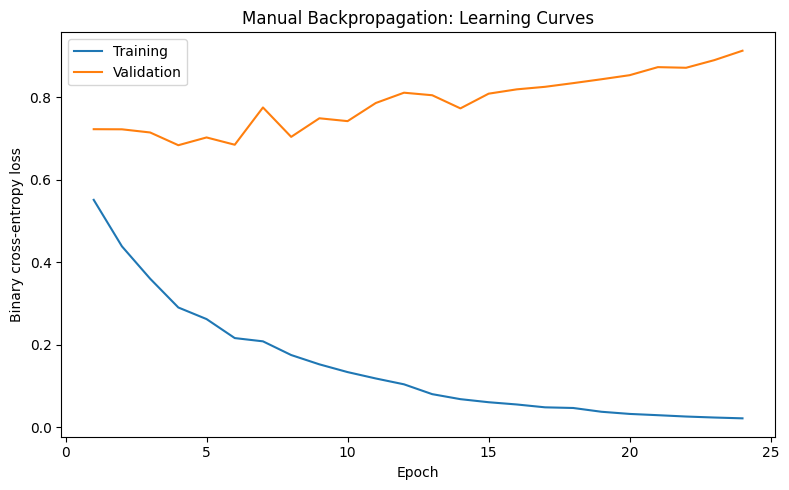

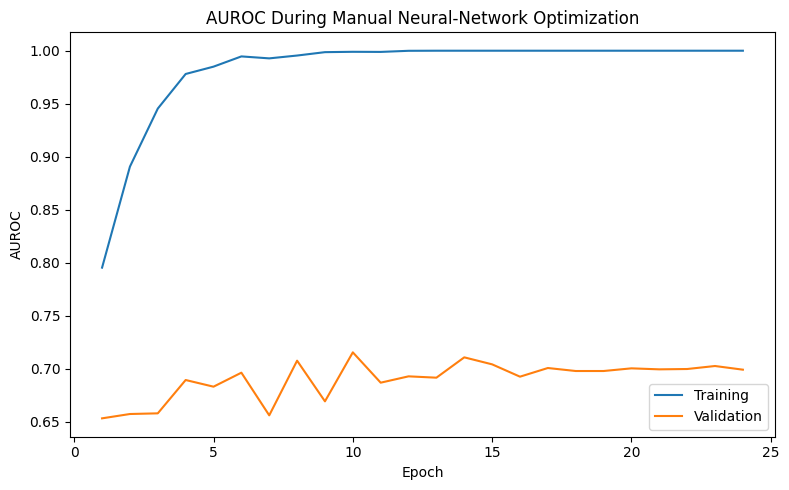

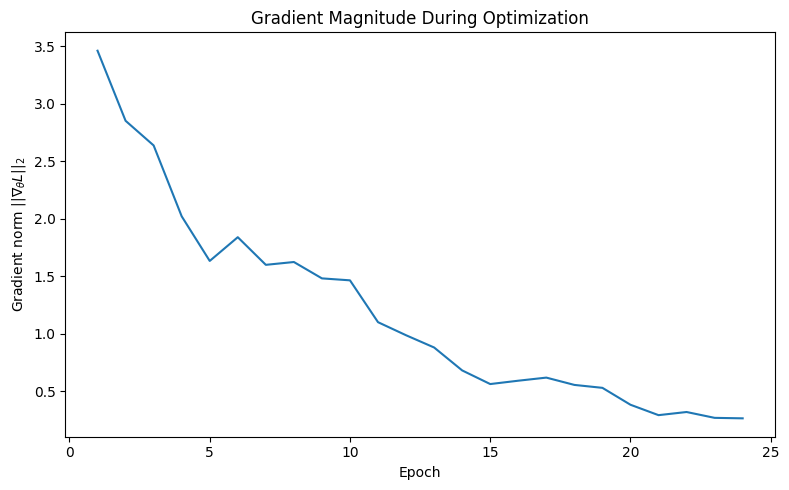

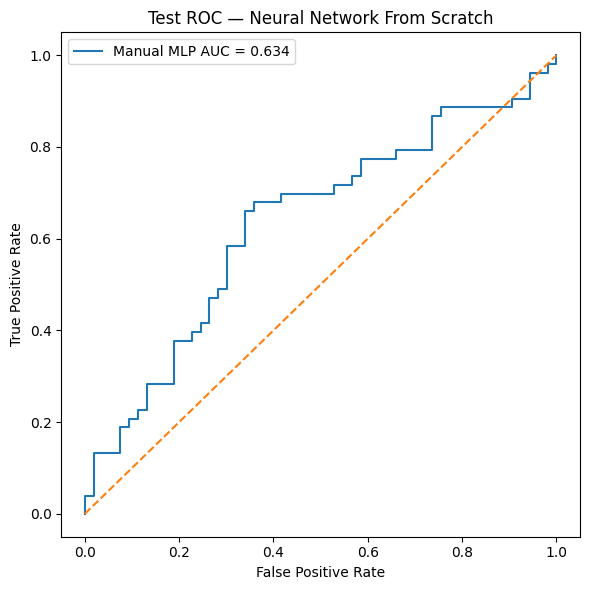


LINEAR ALGEBRA OF LEARNED WEIGHT MATRIX
W1 shape         : (1024, 64)
Spectral norm    : 1.9230
Frobenius norm   : 11.5254
Stable rank      : 35.92
90% effective rank: 55
95% effective rank: 59


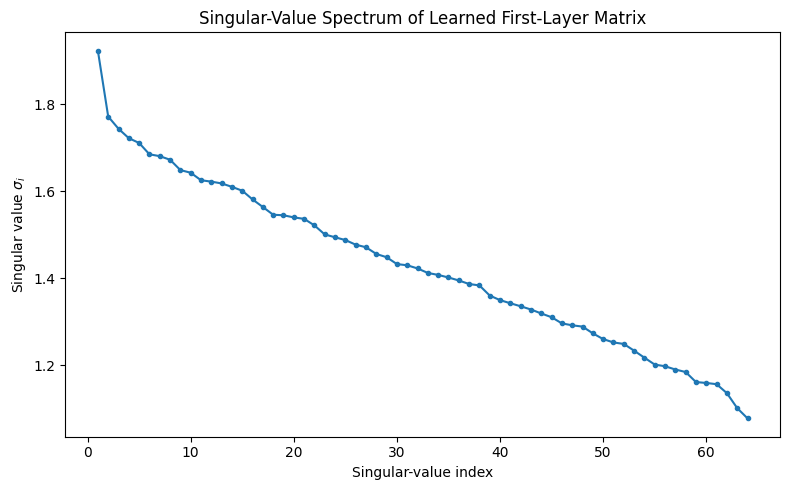

,Quantity,Value
0,Input dimension,1.024000e+03
1,Hidden dimension,6.400000e+01
2,Train sample size,5.800000e+02
3,Validation sample size,1.130000e+02
4,Test sample size,1.060000e+02
5,Gradient-check median relative error,3.331537e-11
6,Spectral norm,1.923039e+00
7,Frobenius norm,1.152540e+01
8,Stable rank,3.591994e+01
9,90% effective rank,5.500000e+01



STAGE 7 COMPLETE
✓ Real chest X-rays converted to vectors
✓ Matrix multiplication implemented manually
✓ ReLU implemented manually
✓ Sigmoid implemented manually
✓ Binary cross-entropy implemented manually
✓ Chain-rule backpropagation implemented manually
✓ Numerical gradient checking completed
✓ Adam optimizer implemented manually
✓ Gradient trajectory analyzed
✓ Independent test-set evaluation completed
✓ Learned weight matrix analyzed using SVD
✓ Spectral norm computed
✓ Stable rank computed
✓ Effective rank computed

Outputs saved:
/kaggle/working/TB_XAI_Stage7_Math

NEXT — STAGE 8
Deep CNN representation learning:
1. DenseNet121
2. ConvNeXt-Tiny
3. Transfer learning
4. Augmentation
5. Early stopping
6. Learning-rate scheduling
7. Model comparison
8. Ablation experiment
9. Bootstrap confidence intervals
10. Calibration analysis


In [4]:
# ============================================================
# TB-XAI
# STAGE 7
# MATHEMATICAL NEURAL NETWORK FROM SCRATCH
#
# Goal:
# Demonstrate Linear Algebra + Calculus + Backpropagation
# WITHOUT PyTorch autograd.
#
# Secondary mathematical task:
# Chest X-ray -> Single vs Multiple Annotated TB Lesions
#
# Architecture:
# X -> W1X+b1 -> ReLU -> W2H+b2 -> Sigmoid
#
# Includes:
# ✓ Matrix formulation
# ✓ BCE loss
# ✓ Chain rule
# ✓ Manual backpropagation
# ✓ Manual Adam optimizer
# ✓ Numerical gradient checking
# ✓ Gradient norms
# ✓ Early stopping
# ✓ AUROC / F1 / Sensitivity / Specificity
# ✓ SVD of learned weight matrix
# ✓ Effective rank / stable rank
# ============================================================


# ============================================================
# 1. LIBRARIES
# ============================================================

import copy
import math
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)


# ============================================================
# 3. CHECK STAGE 6 OBJECTS
# ============================================================

required_columns = [
    "image_path",
    "lesion_count",
    "final_split"
]

missing_columns = [
    x
    for x in required_columns
    if x not in image_df.columns
]

if missing_columns:

    raise RuntimeError(
        "Run Stage 6 first.\n"
        f"Missing columns: {missing_columns}"
    )


# ============================================================
# 4. OUTPUT DIRECTORY
# ============================================================

STAGE7_ROOT = Path(
    "/kaggle/working/TB_XAI_Stage7_Math"
)

STAGE7_ROOT.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 5. DEFINE MATHEMATICAL TARGET
#
# y = 0 -> single lesion
# y = 1 -> multiple lesions
# ============================================================

math_df = image_df.copy()

math_df[
    "multiple_lesions"
] = (
    math_df["lesion_count"] >= 2
).astype(
    np.float32
)


print("=" * 85)
print("TB-XAI — STAGE 7")
print("CALCULUS + LINEAR ALGEBRA + BACKPROPAGATION FROM SCRATCH")
print("=" * 85)

print(
    "\nMathematical demonstration target:"
)

print(
    "0 = Single annotated lesion"
)

print(
    "1 = Multiple annotated lesions"
)


print(
    "\nTarget distribution:"
)

display(
    pd.crosstab(
        math_df["final_split"],
        math_df["multiple_lesions"],
        margins=True
    )
)


# ============================================================
# 6. IMAGE -> VECTOR
#
# Each 32 × 32 image:
#
# I ∈ R^(32×32)
#
# Flatten:
#
# x ∈ R^1024
#
# ============================================================

IMAGE_SIZE = 32


def image_to_vector(
    path,
    image_size=32
):

    img = cv2.imread(
        str(path),
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:

        raise ValueError(
            f"Cannot read image: {path}"
        )

    img = cv2.resize(
        img,
        (
            image_size,
            image_size
        )
    )

    img = (
        img.astype(
            np.float64
        )
        / 255.0
    )

    return img.reshape(
        -1
    )


print(
    "\nConverting X-rays into vectors..."
)


X_all = np.stack(

    math_df[
        "image_path"
    ].apply(
        image_to_vector
    ).values
)


y_all = math_df[
    "multiple_lesions"
].values.reshape(
    -1,
    1
)


print(
    "Feature matrix shape:",
    X_all.shape
)

print(
    "Target vector shape :",
    y_all.shape
)

print(
    f"\nX ∈ R^({X_all.shape[0]} × {X_all.shape[1]})"
)


# ============================================================
# 7. TRAIN / VAL / TEST MASKS
# ============================================================

train_mask = (
    math_df[
        "final_split"
    ].values
    ==
    "train"
)

val_mask = (
    math_df[
        "final_split"
    ].values
    ==
    "val"
)

test_mask = (
    math_df[
        "final_split"
    ].values
    ==
    "test"
)


X_train = X_all[
    train_mask
]

y_train = y_all[
    train_mask
]


X_val = X_all[
    val_mask
]

y_val = y_all[
    val_mask
]


X_test = X_all[
    test_mask
]

y_test = y_all[
    test_mask
]


print("\nDataset matrices:")

print(
    "Train:",
    X_train.shape,
    y_train.shape
)

print(
    "Val  :",
    X_val.shape,
    y_val.shape
)

print(
    "Test :",
    X_test.shape,
    y_test.shape
)


# ============================================================
# 8. TRAIN-ONLY STANDARDIZATION
#
# IMPORTANT:
# mean and std estimated ONLY from training set
#
# z = (x - μ) / σ
# ============================================================

feature_mean = X_train.mean(
    axis=0,
    keepdims=True
)

feature_std = X_train.std(
    axis=0,
    keepdims=True
)

feature_std[
    feature_std < 1e-8
] = 1.0


X_train = (
    X_train
    -
    feature_mean
) / feature_std


X_val = (
    X_val
    -
    feature_mean
) / feature_std


X_test = (
    X_test
    -
    feature_mean
) / feature_std


# ============================================================
# 9. NETWORK ARCHITECTURE
#
# Input:
# X ∈ R^(m × 1024)
#
# Layer 1:
# Z1 = XW1 + b1
#
# W1 ∈ R^(1024 × 64)
#
# ReLU:
# A1 = max(0, Z1)
#
# Output:
# Z2 = A1W2 + b2
#
# sigmoid:
# p = 1 / (1 + exp(-Z2))
# ============================================================

INPUT_DIM = X_train.shape[1]

HIDDEN_DIM = 64

OUTPUT_DIM = 1


print("\n" + "=" * 85)
print("NETWORK ARCHITECTURE")
print("=" * 85)

print(
    f"Input dimension  : {INPUT_DIM}"
)

print(
    f"Hidden neurons   : {HIDDEN_DIM}"
)

print(
    f"Output neurons   : {OUTPUT_DIM}"
)

print(
    "\nArchitecture:"
)

print(
    f"{INPUT_DIM} → {HIDDEN_DIM} → 1"
)


# ============================================================
# 10. HE INITIALIZATION
#
# W ~ N(0, 2/n_in)
# ============================================================

rng = np.random.default_rng(
    SEED
)


W1 = (
    rng.standard_normal(
        (
            INPUT_DIM,
            HIDDEN_DIM
        )
    )
    *
    np.sqrt(
        2.0
        /
        INPUT_DIM
    )
)


b1 = np.zeros(
    (
        1,
        HIDDEN_DIM
    )
)


W2 = (
    rng.standard_normal(
        (
            HIDDEN_DIM,
            1
        )
    )
    *
    np.sqrt(
        2.0
        /
        HIDDEN_DIM
    )
)


b2 = np.zeros(
    (
        1,
        1
    )
)


params = {

    "W1":
        W1,

    "b1":
        b1,

    "W2":
        W2,

    "b2":
        b2
}


# ============================================================
# 11. ACTIVATION FUNCTIONS
# ============================================================

def relu(z):

    return np.maximum(
        0,
        z
    )


def relu_derivative(z):

    return (
        z > 0
    ).astype(
        np.float64
    )


def sigmoid(z):

    # Numerical stability

    z = np.clip(
        z,
        -50,
        50
    )

    return (
        1.0
        /
        (
            1.0
            +
            np.exp(
                -z
            )
        )
    )


# ============================================================
# 12. FORWARD PROPAGATION
#
# Z1 = XW1+b1
# A1 = ReLU(Z1)
#
# Z2 = A1W2+b2
# P  = sigmoid(Z2)
# ============================================================

def forward_pass(
    X,
    params
):

    W1 = params[
        "W1"
    ]

    b1 = params[
        "b1"
    ]

    W2 = params[
        "W2"
    ]

    b2 = params[
        "b2"
    ]


    Z1 = (
        X @ W1
        +
        b1
    )


    A1 = relu(
        Z1
    )


    Z2 = (
        A1 @ W2
        +
        b2
    )


    P = sigmoid(
        Z2
    )


    cache = {

        "X":
            X,

        "Z1":
            Z1,

        "A1":
            A1,

        "Z2":
            Z2,

        "P":
            P
    }


    return (
        P,
        cache
    )


# ============================================================
# 13. BINARY CROSS-ENTROPY
#
# L =
# -1/m Σ [
# y log(p) +
# (1-y) log(1-p)
# ]
#
# + L2 regularization
# ============================================================

LAMBDA = 1e-4


def compute_loss(
    y,
    P,
    params,
    l2_lambda=LAMBDA
):

    m = len(
        y
    )


    eps = 1e-12


    P = np.clip(
        P,
        eps,
        1 - eps
    )


    bce = -np.mean(

        y * np.log(
            P
        )

        +

        (
            1 - y
        )
        *
        np.log(
            1 - P
        )
    )


    l2_penalty = (

        l2_lambda
        /
        (
            2 * m
        )
    ) * (

        np.sum(
            params[
                "W1"
            ] ** 2
        )

        +

        np.sum(
            params[
                "W2"
            ] ** 2
        )
    )


    return (
        bce
        +
        l2_penalty
    )


# ============================================================
# 14. MANUAL BACKPROPAGATION
#
# For sigmoid + BCE:
#
# dZ2 = P - Y
#
# dW2 = A1^T dZ2 / m
#
# db2 = ΣdZ2 / m
#
# dA1 = dZ2 W2^T
#
# dZ1 = dA1 ⊙ ReLU'(Z1)
#
# dW1 = X^T dZ1 / m
#
# db1 = ΣdZ1 / m
# ============================================================

def backward_pass(
    y,
    cache,
    params,
    l2_lambda=LAMBDA
):

    X = cache[
        "X"
    ]

    Z1 = cache[
        "Z1"
    ]

    A1 = cache[
        "A1"
    ]

    P = cache[
        "P"
    ]


    W1 = params[
        "W1"
    ]

    W2 = params[
        "W2"
    ]


    m = len(
        y
    )


    # --------------------------------
    # OUTPUT LAYER
    # --------------------------------

    dZ2 = (
        P
        -
        y
    )


    dW2 = (
        A1.T @ dZ2
    ) / m


    dW2 += (
        l2_lambda
        /
        m
    ) * W2


    db2 = np.sum(
        dZ2,
        axis=0,
        keepdims=True
    ) / m


    # --------------------------------
    # HIDDEN LAYER
    # --------------------------------

    dA1 = (
        dZ2
        @
        W2.T
    )


    dZ1 = (

        dA1

        *

        relu_derivative(
            Z1
        )
    )


    dW1 = (
        X.T
        @
        dZ1
    ) / m


    dW1 += (
        l2_lambda
        /
        m
    ) * W1


    db1 = np.sum(
        dZ1,
        axis=0,
        keepdims=True
    ) / m


    grads = {

        "W1":
            dW1,

        "b1":
            db1,

        "W2":
            dW2,

        "b2":
            db2
    }


    return grads


# ============================================================
# 15. NUMERICAL GRADIENT CHECKING
#
# ∂L/∂θ ≈
#
# L(θ+ε)-L(θ-ε)
# -----------------
#        2ε
#
# Compare numerical gradient vs
# analytical backprop gradient.
# ============================================================

print("\n" + "=" * 85)
print("NUMERICAL GRADIENT CHECK")
print("=" * 85)


GRAD_CHECK_N = min(
    8,
    len(
        X_train
    )
)


X_gc = X_train[
    :GRAD_CHECK_N
]

y_gc = y_train[
    :GRAD_CHECK_N
]


P_gc, cache_gc = forward_pass(
    X_gc,
    params
)


analytical_grads = backward_pass(
    y_gc,
    cache_gc,
    params
)


EPSILON = 1e-5


gradient_checks = []


# ============================================================
# 16. CHECK SELECTED PARAMETERS
# ============================================================

check_locations = [

    (
        "W1",
        (0, 0)
    ),

    (
        "W1",
        (100, 10)
    ),

    (
        "W1",
        (500, 30)
    ),

    (
        "W2",
        (0, 0)
    ),

    (
        "W2",
        (20, 0)
    ),

    (
        "b1",
        (0, 5)
    ),

    (
        "b2",
        (0, 0)
    )
]


for param_name, index in check_locations:

    original_value = (
        params[
            param_name
        ][
            index
        ]
    )


    # θ + ε

    params[
        param_name
    ][
        index
    ] = (
        original_value
        +
        EPSILON
    )


    P_plus, _ = forward_pass(
        X_gc,
        params
    )


    loss_plus = compute_loss(
        y_gc,
        P_plus,
        params
    )


    # θ - ε

    params[
        param_name
    ][
        index
    ] = (
        original_value
        -
        EPSILON
    )


    P_minus, _ = forward_pass(
        X_gc,
        params
    )


    loss_minus = compute_loss(
        y_gc,
        P_minus,
        params
    )


    # Restore parameter

    params[
        param_name
    ][
        index
    ] = original_value


    numerical_gradient = (

        loss_plus
        -
        loss_minus

    ) / (

        2
        *
        EPSILON
    )


    analytical_gradient = (

        analytical_grads[
            param_name
        ][
            index
        ]
    )


    relative_error = (

        abs(
            numerical_gradient
            -
            analytical_gradient
        )

        /

        (
            abs(
                numerical_gradient
            )

            +

            abs(
                analytical_gradient
            )

            +

            1e-12
        )
    )


    gradient_checks.append({

        "Parameter":
            param_name,

        "Index":
            str(
                index
            ),

        "Analytical":
            analytical_gradient,

        "Numerical":
            numerical_gradient,

        "Relative_Error":
            relative_error
    })


gradient_check_df = pd.DataFrame(
    gradient_checks
)


display(
    gradient_check_df
)


gradient_check_df.to_csv(

    STAGE7_ROOT
    /
    "gradient_check.csv",

    index=False
)


print(
    "\nMedian relative error:",
    f"{gradient_check_df['Relative_Error'].median():.2e}"
)


# ============================================================
# 17. MANUAL ADAM OPTIMIZER
#
# m_t = β1 m_(t-1) + (1-β1)g_t
#
# v_t = β2 v_(t-1) + (1-β2)g_t²
#
# θ_t =
# θ_(t-1) -
# α m_hat / (sqrt(v_hat)+ε)
# ============================================================

LEARNING_RATE = 1e-3

BETA1 = 0.9

BETA2 = 0.999

ADAM_EPS = 1e-8


adam_m = {

    name:
        np.zeros_like(
            value
        )

    for name, value
    in params.items()
}


adam_v = {

    name:
        np.zeros_like(
            value
        )

    for name, value
    in params.items()
}


def adam_step(
    params,
    grads,
    adam_m,
    adam_v,
    step,
    learning_rate=LEARNING_RATE
):

    for name in params.keys():

        adam_m[
            name
        ] = (

            BETA1
            *
            adam_m[
                name
            ]

            +

            (
                1 - BETA1
            )
            *
            grads[
                name
            ]
        )


        adam_v[
            name
        ] = (

            BETA2
            *
            adam_v[
                name
            ]

            +

            (
                1 - BETA2
            )
            *
            (
                grads[
                    name
                ] ** 2
            )
        )


        m_hat = (

            adam_m[
                name
            ]

            /

            (
                1
                -
                BETA1 ** step
            )
        )


        v_hat = (

            adam_v[
                name
            ]

            /

            (
                1
                -
                BETA2 ** step
            )
        )


        params[
            name
        ] -= (

            learning_rate

            *

            m_hat

            /

            (
                np.sqrt(
                    v_hat
                )
                +
                ADAM_EPS
            )
        )


# ============================================================
# 18. METRIC FUNCTION
# ============================================================

def evaluate_binary(
    y_true,
    probabilities,
    threshold=0.5
):

    y_true = y_true.reshape(
        -1
    )

    probabilities = probabilities.reshape(
        -1
    )

    predictions = (
        probabilities >= threshold
    ).astype(
        int
    )


    accuracy = accuracy_score(
        y_true,
        predictions
    )


    precision = precision_score(
        y_true,
        predictions,
        zero_division=0
    )


    sensitivity = recall_score(
        y_true,
        predictions,
        zero_division=0
    )


    f1 = f1_score(
        y_true,
        predictions,
        zero_division=0
    )


    tn, fp, fn, tp = confusion_matrix(

        y_true,
        predictions,

        labels=[
            0,
            1
        ]

    ).ravel()


    specificity = (

        tn
        /
        (
            tn
            +
            fp
        )

        if
        (
            tn
            +
            fp
        )
        >
        0

        else
        np.nan
    )


    auc = roc_auc_score(
        y_true,
        probabilities
    )


    return {

        "Accuracy":
            accuracy,

        "Precision":
            precision,

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "F1":
            f1,

        "AUROC":
            auc
    }


# ============================================================
# 19. TRAINING SETTINGS
# ============================================================

EPOCHS = 150

BATCH_SIZE = 32

PATIENCE = 20


history = {

    "train_loss": [],

    "val_loss": [],

    "train_auc": [],

    "val_auc": [],

    "gradient_norm": []
}


best_val_loss = np.inf

best_params = None

epochs_without_improvement = 0

optimizer_step = 0


# ============================================================
# 20. TRAIN FROM SCRATCH
# ============================================================

print("\n" + "=" * 85)
print("MANUAL BACKPROPAGATION TRAINING")
print("=" * 85)


for epoch in range(
    1,
    EPOCHS + 1
):

    indices = np.random.permutation(
        len(
            X_train
        )
    )


    batch_gradient_norms = []


    for start in range(
        0,
        len(
            X_train
        ),
        BATCH_SIZE
    ):

        batch_idx = indices[
            start:
            start
            +
            BATCH_SIZE
        ]


        X_batch = X_train[
            batch_idx
        ]


        y_batch = y_train[
            batch_idx
        ]


        # -----------------------------
        # Forward
        # -----------------------------

        P_batch, cache = forward_pass(

            X_batch,

            params
        )


        # -----------------------------
        # Backward
        # -----------------------------

        grads = backward_pass(

            y_batch,

            cache,

            params
        )


        # -----------------------------
        # Gradient norm
        # -----------------------------

        grad_norm = np.sqrt(

            sum(

                np.sum(
                    g ** 2
                )

                for g in grads.values()
            )
        )


        batch_gradient_norms.append(
            grad_norm
        )


        # -----------------------------
        # Adam update
        # -----------------------------

        optimizer_step += 1


        adam_step(

            params,

            grads,

            adam_m,

            adam_v,

            optimizer_step
        )


    # ========================================================
    # END-OF-EPOCH EVALUATION
    # ========================================================

    train_prob, _ = forward_pass(
        X_train,
        params
    )


    val_prob, _ = forward_pass(
        X_val,
        params
    )


    train_loss = compute_loss(
        y_train,
        train_prob,
        params
    )


    val_loss = compute_loss(
        y_val,
        val_prob,
        params
    )


    train_auc = roc_auc_score(
        y_train,
        train_prob
    )


    val_auc = roc_auc_score(
        y_val,
        val_prob
    )


    mean_grad_norm = np.mean(
        batch_gradient_norms
    )


    history[
        "train_loss"
    ].append(
        train_loss
    )


    history[
        "val_loss"
    ].append(
        val_loss
    )


    history[
        "train_auc"
    ].append(
        train_auc
    )


    history[
        "val_auc"
    ].append(
        val_auc
    )


    history[
        "gradient_norm"
    ].append(
        mean_grad_norm
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_params = copy.deepcopy(
            params
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if (
        epoch == 1
        or
        epoch % 10 == 0
    ):

        print(

            f"Epoch {epoch:03d} | "

            f"Train Loss: "
            f"{train_loss:.4f} | "

            f"Val Loss: "
            f"{val_loss:.4f} | "

            f"Train AUC: "
            f"{train_auc:.4f} | "

            f"Val AUC: "
            f"{val_auc:.4f} | "

            f"||∇L||: "
            f"{mean_grad_norm:.4f}"
        )


    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping at epoch {epoch}"
        )

        break


# ============================================================
# 21. RESTORE BEST PARAMETERS
# ============================================================

params = best_params


print(
    "\nBest validation loss:",
    round(
        best_val_loss,
        5
    )
)


# ============================================================
# 22. FINAL PREDICTIONS
# ============================================================

train_prob, _ = forward_pass(
    X_train,
    params
)


val_prob, _ = forward_pass(
    X_val,
    params
)


test_prob, _ = forward_pass(
    X_test,
    params
)


# ============================================================
# 23. FINAL PERFORMANCE
# ============================================================

train_metrics = evaluate_binary(
    y_train,
    train_prob
)


val_metrics = evaluate_binary(
    y_val,
    val_prob
)


test_metrics = evaluate_binary(
    y_test,
    test_prob
)


metrics_df = pd.DataFrame({

    "Train":
        train_metrics,

    "Validation":
        val_metrics,

    "Test":
        test_metrics
}).T


print("\n" + "=" * 85)
print("FINAL PERFORMANCE")
print("=" * 85)


display(
    metrics_df.round(
        4
    )
)


metrics_df.to_csv(

    STAGE7_ROOT
    /
    "manual_mlp_performance.csv"
)


# ============================================================
# 24. LEARNING CURVES
# ============================================================

epochs_run = len(
    history[
        "train_loss"
    ]
)


plt.figure(
    figsize=(8, 5)
)


plt.plot(

    range(
        1,
        epochs_run + 1
    ),

    history[
        "train_loss"
    ],

    label="Training"
)


plt.plot(

    range(
        1,
        epochs_run + 1
    ),

    history[
        "val_loss"
    ],

    label="Validation"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Binary cross-entropy loss"
)

plt.title(
    "Manual Backpropagation: Learning Curves"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    STAGE7_ROOT
    /
    "manual_backprop_loss.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 25. AUROC LEARNING
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    range(
        1,
        epochs_run + 1
    ),

    history[
        "train_auc"
    ],

    label="Training"
)


plt.plot(

    range(
        1,
        epochs_run + 1
    ),

    history[
        "val_auc"
    ],

    label="Validation"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "AUROC"
)

plt.title(
    "AUROC During Manual Neural-Network Optimization"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    STAGE7_ROOT
    /
    "manual_backprop_auc.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 26. GRADIENT-NORM TRAJECTORY
#
# Useful for understanding optimization stability
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    range(
        1,
        epochs_run + 1
    ),

    history[
        "gradient_norm"
    ]
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    r"Gradient norm $||\nabla_\theta L||_2$"
)

plt.title(
    "Gradient Magnitude During Optimization"
)

plt.tight_layout()


plt.savefig(

    STAGE7_ROOT
    /
    "gradient_norm_trajectory.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 27. TEST ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test.reshape(
        -1
    ),
    test_prob.reshape(
        -1
    )
)


test_auc = roc_auc_score(
    y_test,
    test_prob
)


plt.figure(
    figsize=(6, 6)
)


plt.plot(

    fpr,
    tpr,

    label=f"Manual MLP AUC = {test_auc:.3f}"
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Test ROC — Neural Network From Scratch"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    STAGE7_ROOT
    /
    "manual_mlp_test_roc.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 28. LINEAR ALGEBRA OF LEARNED WEIGHTS
#
# W1 = U Σ V^T
#
# Analyze singular-value spectrum
# ============================================================

print("\n" + "=" * 85)
print("LINEAR ALGEBRA OF LEARNED WEIGHT MATRIX")
print("=" * 85)


W1_final = params[
    "W1"
]


U_w, S_w, Vt_w = np.linalg.svd(

    W1_final,

    full_matrices=False
)


spectral_norm = S_w[
    0
]


frobenius_norm = np.linalg.norm(

    W1_final,

    ord="fro"
)


stable_rank = (

    frobenius_norm ** 2

    /

    spectral_norm ** 2
)


variance = (
    S_w ** 2
)


variance_ratio = (

    variance
    /
    variance.sum()
)


cumulative = np.cumsum(
    variance_ratio
)


effective_rank_90 = (

    np.argmax(
        cumulative >= 0.90
    )
    +
    1
)


effective_rank_95 = (

    np.argmax(
        cumulative >= 0.95
    )
    +
    1
)


print(
    f"W1 shape         : {W1_final.shape}"
)

print(
    f"Spectral norm    : {spectral_norm:.4f}"
)

print(
    f"Frobenius norm   : {frobenius_norm:.4f}"
)

print(
    f"Stable rank      : {stable_rank:.2f}"
)

print(
    f"90% effective rank: {effective_rank_90}"
)

print(
    f"95% effective rank: {effective_rank_95}"
)


# ============================================================
# 29. SINGULAR VALUE SPECTRUM
# ============================================================

plt.figure(
    figsize=(8, 5)
)


plt.plot(

    np.arange(
        1,
        len(
            S_w
        )
        +
        1
    ),

    S_w,

    marker="o",

    markersize=3
)


plt.xlabel(
    "Singular-value index"
)

plt.ylabel(
    r"Singular value $\sigma_i$"
)

plt.title(
    "Singular-Value Spectrum of Learned First-Layer Matrix"
)

plt.tight_layout()


plt.savefig(

    STAGE7_ROOT
    /
    "learned_weight_singular_values.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 30. SAVE MODEL PARAMETERS
# ============================================================

np.savez(

    STAGE7_ROOT
    /
    "manual_mlp_parameters.npz",

    W1=params[
        "W1"
    ],

    b1=params[
        "b1"
    ],

    W2=params[
        "W2"
    ],

    b2=params[
        "b2"
    ],

    feature_mean=
        feature_mean,

    feature_std=
        feature_std
)


# ============================================================
# 31. SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(

    STAGE7_ROOT
    /
    "training_history.csv",

    index=False
)


# ============================================================
# 32. MATHEMATICAL SUMMARY TABLE
# ============================================================

math_summary = pd.DataFrame({

    "Quantity": [

        "Input dimension",

        "Hidden dimension",

        "Train sample size",

        "Validation sample size",

        "Test sample size",

        "Gradient-check median relative error",

        "Spectral norm",

        "Frobenius norm",

        "Stable rank",

        "90% effective rank",

        "95% effective rank",

        "Test AUROC",

        "Test F1"
    ],

    "Value": [

        INPUT_DIM,

        HIDDEN_DIM,

        len(
            X_train
        ),

        len(
            X_val
        ),

        len(
            X_test
        ),

        gradient_check_df[
            "Relative_Error"
        ].median(),

        spectral_norm,

        frobenius_norm,

        stable_rank,

        effective_rank_90,

        effective_rank_95,

        test_metrics[
            "AUROC"
        ],

        test_metrics[
            "F1"
        ]
    ]
})


display(
    math_summary
)


math_summary.to_csv(

    STAGE7_ROOT
    /
    "mathematical_summary.csv",

    index=False
)


# ============================================================
# 33. FINAL STAGE SUMMARY
# ============================================================

print("\n" + "=" * 85)
print("STAGE 7 COMPLETE")
print("=" * 85)


print(
    "✓ Real chest X-rays converted to vectors"
)

print(
    "✓ Matrix multiplication implemented manually"
)

print(
    "✓ ReLU implemented manually"
)

print(
    "✓ Sigmoid implemented manually"
)

print(
    "✓ Binary cross-entropy implemented manually"
)

print(
    "✓ Chain-rule backpropagation implemented manually"
)

print(
    "✓ Numerical gradient checking completed"
)

print(
    "✓ Adam optimizer implemented manually"
)

print(
    "✓ Gradient trajectory analyzed"
)

print(
    "✓ Independent test-set evaluation completed"
)

print(
    "✓ Learned weight matrix analyzed using SVD"
)

print(
    "✓ Spectral norm computed"
)

print(
    "✓ Stable rank computed"
)

print(
    "✓ Effective rank computed"
)


print(
    f"\nOutputs saved:"
    f"\n{STAGE7_ROOT}"
)


print("\n" + "=" * 85)
print("NEXT — STAGE 8")
print("=" * 85)


print(
    "Deep CNN representation learning:"
)

print(
    "1. DenseNet121"
)

print(
    "2. ConvNeXt-Tiny"
)

print(
    "3. Transfer learning"
)

print(
    "4. Augmentation"
)

print(
    "5. Early stopping"
)

print(
    "6. Learning-rate scheduling"
)

print(
    "7. Model comparison"
)

print(
    "8. Ablation experiment"
)

print(
    "9. Bootstrap confidence intervals"
)

print(
    "10. Calibration analysis"
)

print("=" * 85)

TB-XAI — STAGE 8
ADVANCED CNN REPRESENTATION LEARNING
Device: cuda
GPU: Tesla T4

Target distribution:


target,0,1,All
final_split,,,
test,53,53,106
train,304,276,580
val,60,53,113
All,417,382,799



Configuration:
Image size       : 224
Batch size       : 16
Phase A epochs   : 5
Phase B epochs   : 15

Sample sizes:
Train: 580
Validation: 113
Test: 106

Training class counts:
Negative: 304
Positive: 276
Positive class weight: 1.1014

Official ImageNet cache:
DenseNet121: False
ConvNeXt-Tiny: False

TRAINING DenseNet121
Official ImageNet weights used: False

Phase A trainable parameters: 1,025 / 6,954,881
DenseNet121    | Frozen     | Epoch 01 | Train loss 0.7572 | Val loss 0.7294 | AUC 0.4305 | AUPRC 0.4471
DenseNet121    | Frozen     | Epoch 02 | Train loss 0.7340 | Val loss 0.7434 | AUC 0.4374 | AUPRC 0.4414
DenseNet121    | Frozen     | Epoch 03 | Train loss 0.7525 | Val loss 0.7277 | AUC 0.4569 | AUPRC 0.4717
DenseNet121    | Frozen     | Epoch 04 | Train loss 0.7395 | Val loss 0.7375 | AUC 0.5330 | AUPRC 0.4929
DenseNet121    | Frozen     | Epoch 05 | Train loss 0.7467 | Val loss 0.7232 | AUC 0.5588 | AUPRC 0.5164

Phase B trainable parameters: 2,161,153 / 6,954,881
DenseNet1

,AUROC,AUPRC,Accuracy,Precision,Sensitivity,Specificity,F1,MCC,Brier,ECE,Threshold
0,0.5457,0.5235,0.5566,0.5536,0.5849,0.5283,0.5688,0.1134,0.25,0.0577,0.4962



TRAINING ConvNeXtTiny
Official ImageNet weights used: False

Phase A trainable parameters: 2,305 / 27,820,897
ConvNeXtTiny   | Frozen     | Epoch 01 | Train loss 0.7674 | Val loss 0.7401 | AUC 0.5069 | AUPRC 0.4906
ConvNeXtTiny   | Frozen     | Epoch 02 | Train loss 0.7445 | Val loss 0.7434 | AUC 0.5025 | AUPRC 0.4518
ConvNeXtTiny   | Frozen     | Epoch 03 | Train loss 0.7405 | Val loss 0.7299 | AUC 0.5060 | AUPRC 0.4623
ConvNeXtTiny   | Frozen     | Epoch 04 | Train loss 0.7410 | Val loss 0.7325 | AUC 0.5217 | AUPRC 0.4725
ConvNeXtTiny   | Frozen     | Epoch 05 | Train loss 0.7413 | Val loss 0.7493 | AUC 0.5085 | AUPRC 0.4719

Phase B trainable parameters: 15,472,897 / 27,820,897
ConvNeXtTiny   | FineTune   | Epoch 01 | Train loss 0.7432 | Val loss 0.7380 | AUC 0.4903 | AUPRC 0.4737
ConvNeXtTiny   | FineTune   | Epoch 02 | Train loss 0.7415 | Val loss 0.7351 | AUC 0.4742 | AUPRC 0.4725
ConvNeXtTiny   | FineTune   | Epoch 03 | Train loss 0.7337 | Val loss 0.7466 | AUC 0.5126 | AUPRC 0

...


MODEL COMPARISON


,Model,Pretrained,Frozen_Val_AUROC,AUROC,AUPRC,Accuracy,Precision,Sensitivity,Specificity,F1,MCC,Brier,ECE,Threshold
0,DenseNet121,False,0.5588,0.5457,0.5235,0.5566,0.5536,0.5849,0.5283,0.5688,0.1134,0.2500,0.0577,0.4962
1,ConvNeXtTiny,False,0.5060,0.5333,0.5847,0.5000,0.5000,0.5660,0.4340,0.5310,0.0000,0.2478,0.0356,0.4959



Bootstrap AUROC 95% CIs:


,Model,AUROC,CI_Lower,CI_Upper
0,DenseNet121,0.5457,0.4315,0.6587
1,ConvNeXtTiny,0.5333,0.4237,0.6408



PAIRED MODEL COMPARISON
ΔAUROC (ConvNeXt − DenseNet): -0.0125
95% paired bootstrap CI: -0.1660 to 0.1426


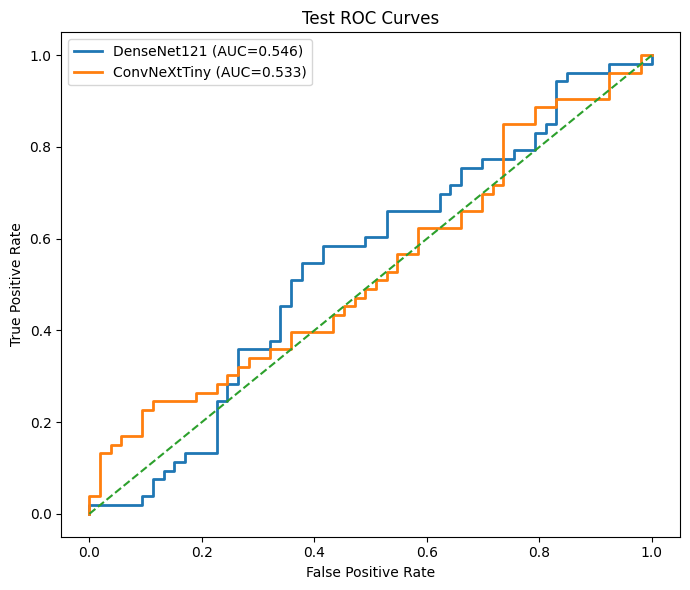

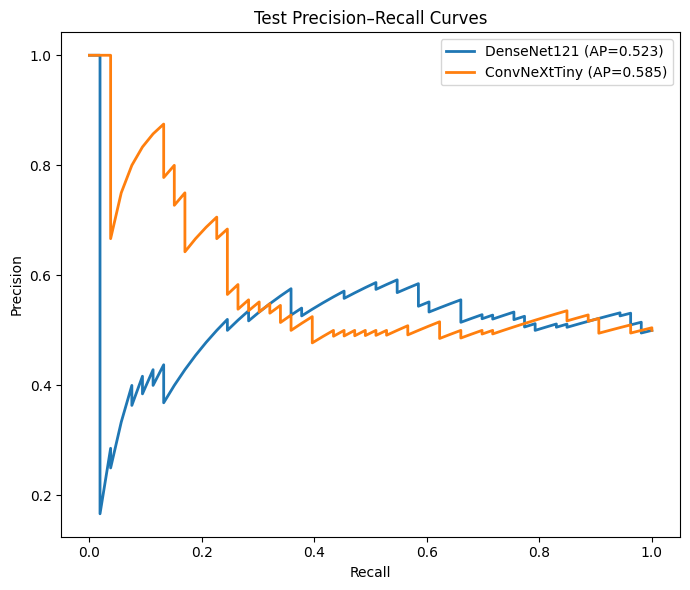

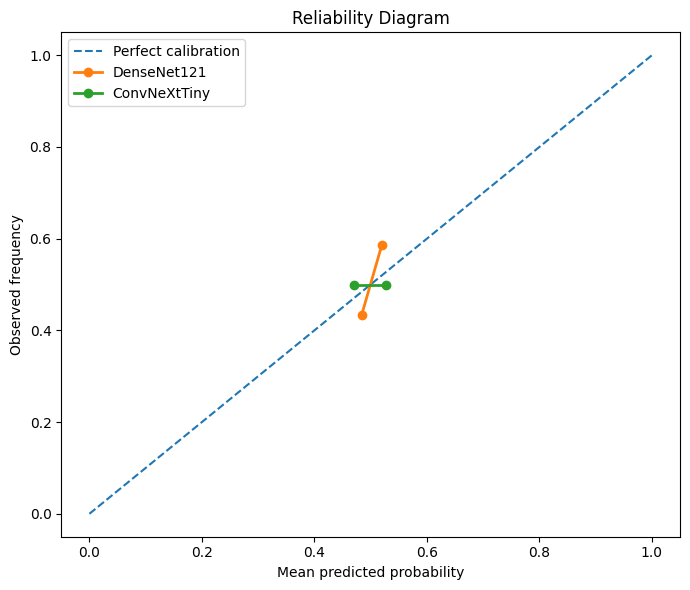

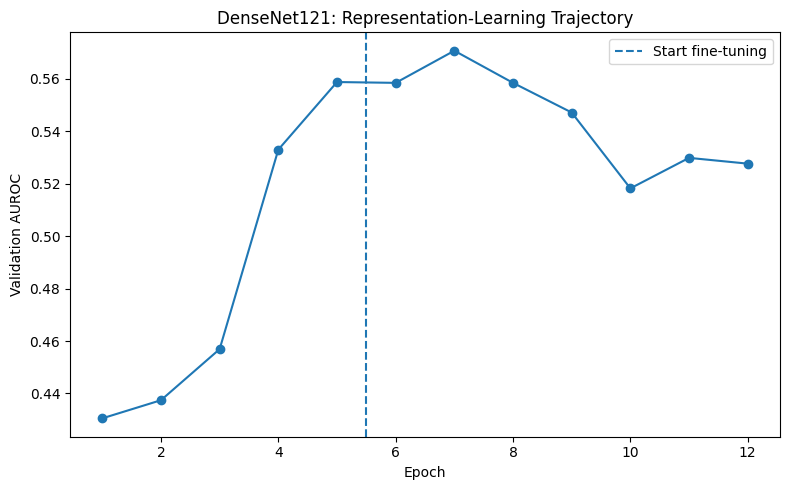

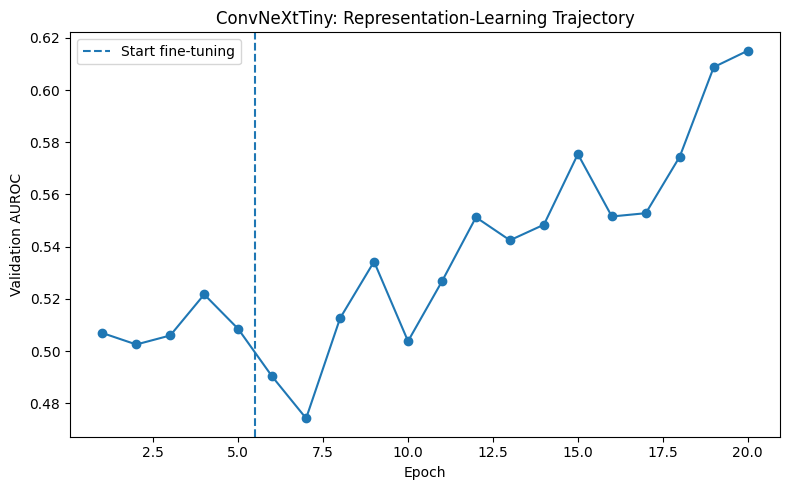


STAGE 8 COMPLETE
✓ DenseNet121 evaluated
✓ ConvNeXt-Tiny evaluated
✓ Frozen-feature ablation completed
✓ Partial fine-tuning completed
✓ Leakage-safe split preserved
✓ Class weighting applied
✓ Validation-only threshold selected
✓ Independent test evaluation completed
✓ AUROC and AUPRC computed
✓ Sensitivity and specificity computed
✓ MCC computed
✓ Brier score computed
✓ Expected calibration error computed
✓ Bootstrap 95% AUROC CI computed
✓ Paired bootstrap model comparison completed
✓ Reliability diagram generated

Outputs saved to:
/kaggle/working/TB_XAI_Stage8_CNN

IMPORTANT INTERPRETATION
⚠ Official ImageNet pretrained weights were NOT locally available.
These results should be treated as from-scratch/pilot CNN results.
For final transfer-learning results, attach/download official ImageNet weights and rerun this stage.

NEXT — STAGE 9 / 10
1. Select final architecture using validation evidence
2. Temperature scaling for probability calibration
3. Decision-curve / net-benefit ana

In [5]:
# ============================================================
# TB-XAI
# STAGE 8
# ADVANCED DEEP CNN REPRESENTATION LEARNING
#
# CURRENT TASK:
# Single-lesion vs Multiple-lesion burden classification
#
# IMPORTANT:
# This is NOT yet TB vs Non-TB diagnosis.
#
# Models:
#   1. DenseNet121
#   2. ConvNeXt-Tiny
#
# Includes:
# ✓ Leakage-safe Stage-6 split
# ✓ Image augmentation
# ✓ Class weighting
# ✓ Two-stage training
#       Phase A: linear probe / frozen backbone
#       Phase B: partial fine-tuning
# ✓ AdamW
# ✓ LR scheduling
# ✓ Early stopping
# ✓ Validation-selected threshold
# ✓ AUROC
# ✓ AUPRC
# ✓ Sensitivity
# ✓ Specificity
# ✓ MCC
# ✓ Brier score
# ✓ ECE calibration error
# ✓ Bootstrap 95% CI
# ✓ Paired bootstrap comparison
# ✓ ROC / PR / calibration curves
# ✓ Publication-ready result tables
# ============================================================


# ============================================================
# 1. LIBRARIES
# ============================================================

import os
import gc
import copy
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import transforms

from torchvision.models import (
    densenet121,
    convnext_tiny,
    DenseNet121_Weights,
    ConvNeXt_Tiny_Weights
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    brier_score_loss
)

warnings.filterwarnings("ignore")


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# 3. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("=" * 90)
print("TB-XAI — STAGE 8")
print("ADVANCED CNN REPRESENTATION LEARNING")
print("=" * 90)

print(
    f"Device: {DEVICE}"
)


if torch.cuda.is_available():

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

else:

    print(
        "\n⚠ CPU detected."
    )

    print(
        "The code will automatically use a lighter pilot configuration."
    )

    print(
        "For final portfolio results, rerun with Kaggle GPU enabled."
    )


# ============================================================
# 4. CHECK STAGE 6 DATA
# ============================================================

required_columns = [

    "image_path",
    "lesion_count",
    "final_split"
]


missing = [

    c
    for c in required_columns
    if c not in image_df.columns
]


if missing:

    raise RuntimeError(
        f"Run Stage 6 first. Missing: {missing}"
    )


cnn_df = image_df.copy()


# ============================================================
# 5. TARGET
#
# 0 = single annotated lesion
# 1 = multiple annotated lesions
# ============================================================

cnn_df[
    "target"
] = (

    cnn_df[
        "lesion_count"
    ]

    >= 2

).astype(
    int
)


print("\nTarget distribution:")

display(

    pd.crosstab(

        cnn_df[
            "final_split"
        ],

        cnn_df[
            "target"
        ],

        margins=True
    )
)


# ============================================================
# 6. OUTPUT DIRECTORIES
# ============================================================

STAGE8_ROOT = Path(
    "/kaggle/working/TB_XAI_Stage8_CNN"
)

MODEL_DIR = (
    STAGE8_ROOT
    /
    "models"
)

FIG_DIR = (
    STAGE8_ROOT
    /
    "figures"
)

TABLE_DIR = (
    STAGE8_ROOT
    /
    "tables"
)

PRED_DIR = (
    STAGE8_ROOT
    /
    "predictions"
)


for directory in [

    STAGE8_ROOT,
    MODEL_DIR,
    FIG_DIR,
    TABLE_DIR,
    PRED_DIR

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# 7. CPU/GPU-ADAPTIVE CONFIGURATION
# ============================================================

if DEVICE.type == "cuda":

    IMAGE_SIZE = 224

    BATCH_SIZE = 16

    PHASE_A_EPOCHS = 5

    PHASE_B_EPOCHS = 15

    PATIENCE = 5

else:

    # Pilot setting for CPU.
    # Rerun final experiment on GPU.

    IMAGE_SIZE = 160

    BATCH_SIZE = 8

    PHASE_A_EPOCHS = 2

    PHASE_B_EPOCHS = 5

    PATIENCE = 3


NUM_WORKERS = 2

HEAD_LR = 1e-3

FINETUNE_LR = 2e-5

WEIGHT_DECAY = 1e-4


print("\nConfiguration:")

print(
    f"Image size       : {IMAGE_SIZE}"
)

print(
    f"Batch size       : {BATCH_SIZE}"
)

print(
    f"Phase A epochs   : {PHASE_A_EPOCHS}"
)

print(
    f"Phase B epochs   : {PHASE_B_EPOCHS}"
)


# ============================================================
# 8. TRANSFORMS
#
# Train:
# modest medical-image augmentation
#
# IMPORTANT:
# Avoid extreme transforms that may distort anatomy.
# ============================================================

imagenet_mean = [
    0.485,
    0.456,
    0.406
]

imagenet_std = [
    0.229,
    0.224,
    0.225
]


train_transform = transforms.Compose([

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        )
    ),

    transforms.RandomHorizontalFlip(
        p=0.50
    ),

    transforms.RandomRotation(
        degrees=5
    ),

    transforms.RandomAffine(

        degrees=0,

        translate=(
            0.03,
            0.03
        ),

        scale=(
            0.95,
            1.05
        )
    ),

    transforms.ColorJitter(

        brightness=0.10,

        contrast=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        imagenet_mean,
        imagenet_std
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(
        (
            IMAGE_SIZE,
            IMAGE_SIZE
        )
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        imagenet_mean,
        imagenet_std
    )
])


# ============================================================
# 9. DATASET CLASS
# ============================================================

class ChestXrayDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = (
            dataframe
            .reset_index(
                drop=True
            )
        )

        self.transform = transform


    def __len__(
        self
    ):

        return len(
            self.df
        )


    def __getitem__(
        self,
        idx
    ):

        row = self.df.iloc[
            idx
        ]


        image = Image.open(
            row[
                "image_path"
            ]
        ).convert(
            "RGB"
        )


        if self.transform:

            image = self.transform(
                image
            )


        target = torch.tensor(

            row[
                "target"
            ],

            dtype=torch.float32
        )


        return (

            image,
            target,
            row[
                "filename"
            ]
        )


# ============================================================
# 10. SPLIT DATAFRAMES
# ============================================================

train_df = cnn_df[
    cnn_df[
        "final_split"
    ]
    ==
    "train"
].copy()


val_df = cnn_df[
    cnn_df[
        "final_split"
    ]
    ==
    "val"
].copy()


test_df = cnn_df[
    cnn_df[
        "final_split"
    ]
    ==
    "test"
].copy()


print("\nSample sizes:")

print(
    "Train:",
    len(
        train_df
    )
)

print(
    "Validation:",
    len(
        val_df
    )
)

print(
    "Test:",
    len(
        test_df
    )
)


# ============================================================
# 11. DATASETS
# ============================================================

train_dataset = ChestXrayDataset(

    train_df,

    train_transform
)


val_dataset = ChestXrayDataset(

    val_df,

    eval_transform
)


test_dataset = ChestXrayDataset(

    test_df,

    eval_transform
)


# ============================================================
# 12. DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type
        ==
        "cuda"
    )
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type
        ==
        "cuda"
    )
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=(
        DEVICE.type
        ==
        "cuda"
    )
)


# ============================================================
# 13. CLASS WEIGHT
#
# pos_weight =
# N_negative / N_positive
# ============================================================

n_negative = (

    train_df[
        "target"
    ]
    ==
    0

).sum()


n_positive = (

    train_df[
        "target"
    ]
    ==
    1

).sum()


POS_WEIGHT = (

    n_negative

    /

    n_positive
)


print(
    "\nTraining class counts:"
)

print(
    "Negative:",
    n_negative
)

print(
    "Positive:",
    n_positive
)

print(
    f"Positive class weight: {POS_WEIGHT:.4f}"
)


pos_weight_tensor = torch.tensor(

    [
        POS_WEIGHT
    ],

    dtype=torch.float32,

    device=DEVICE
)


criterion = nn.BCEWithLogitsLoss(

    pos_weight=pos_weight_tensor
)


# ============================================================
# 14. CHECK FOR LOCALLY CACHED IMAGENET WEIGHTS
#
# We DO NOT use the existing TB-trained model from
# another notebook.
#
# This checks only official torchvision ImageNet cache.
# ============================================================

TORCH_CACHE = (

    Path(
        torch.hub.get_dir()
    )

    /
    "checkpoints"
)


DENSENET_CACHE = (
    TORCH_CACHE
    /
    "densenet121-a639ec97.pth"
)


CONVNEXT_CACHE = (
    TORCH_CACHE
    /
    "convnext_tiny-983f1562.pth"
)


print("\nOfficial ImageNet cache:")

print(
    "DenseNet121:",
    DENSENET_CACHE.exists()
)

print(
    "ConvNeXt-Tiny:",
    CONVNEXT_CACHE.exists()
)


# ============================================================
# 15. MODEL FACTORY
#
# If official weights are cached -> transfer learning.
# Otherwise -> random initialization.
#
# This avoids internet-related crashes.
# ============================================================

def build_model(
    model_name
):

    pretrained_used = False


    # ========================================================
    # DENSENET121
    # ========================================================

    if model_name == "DenseNet121":

        model = densenet121(
            weights=None
        )


        if DENSENET_CACHE.exists():

            state = torch.load(

                DENSENET_CACHE,

                map_location="cpu",

                weights_only=True
            )


            model.load_state_dict(
                state
            )


            pretrained_used = True


        n_features = (
            model.classifier.in_features
        )


        model.classifier = nn.Sequential(

            nn.Dropout(
                p=0.30
            ),

            nn.Linear(
                n_features,
                1
            )
        )


    # ========================================================
    # CONVNEXT-TINY
    # ========================================================

    elif model_name == "ConvNeXtTiny":

        model = convnext_tiny(
            weights=None
        )


        if CONVNEXT_CACHE.exists():

            state = torch.load(

                CONVNEXT_CACHE,

                map_location="cpu",

                weights_only=True
            )


            model.load_state_dict(
                state
            )


            pretrained_used = True


        n_features = (
            model.classifier[
                2
            ].in_features
        )


        model.classifier[
            2
        ] = nn.Linear(

            n_features,

            1
        )


    else:

        raise ValueError(
            model_name
        )


    return (
        model,
        pretrained_used
    )


# ============================================================
# 16. FREEZE BACKBONE
# ============================================================

def freeze_backbone(
    model,
    model_name
):

    for parameter in model.parameters():

        parameter.requires_grad = False


    if model_name == "DenseNet121":

        for parameter in (
            model.classifier.parameters()
        ):

            parameter.requires_grad = True


    elif model_name == "ConvNeXtTiny":

        for parameter in (
            model.classifier.parameters()
        ):

            parameter.requires_grad = True


# ============================================================
# 17. PARTIAL UNFREEZING
#
# Avoid full-network fine-tuning on tiny dataset.
# ============================================================

def partial_unfreeze(
    model,
    model_name
):

    # Keep earlier layers frozen

    for parameter in model.parameters():

        parameter.requires_grad = False


    if model_name == "DenseNet121":

        # Last DenseNet block

        for parameter in (

            model.features.denseblock4
            .parameters()

        ):

            parameter.requires_grad = True


        for parameter in (

            model.features.norm5
            .parameters()

        ):

            parameter.requires_grad = True


        for parameter in (

            model.classifier
            .parameters()

        ):

            parameter.requires_grad = True


    elif model_name == "ConvNeXtTiny":

        # Last two feature stages

        for parameter in (

            model.features[
                -2:
            ].parameters()

        ):

            parameter.requires_grad = True


        for parameter in (

            model.classifier
            .parameters()

        ):

            parameter.requires_grad = True


# ============================================================
# 18. TRAINABLE PARAMETER COUNTER
# ============================================================

def parameter_summary(
    model
):

    total = sum(

        p.numel()

        for p in model.parameters()
    )


    trainable = sum(

        p.numel()

        for p in model.parameters()

        if p.requires_grad
    )


    return (
        total,
        trainable
    )


# ============================================================
# 19. EVALUATION PREDICTION FUNCTION
# ============================================================

@torch.no_grad()
def predict_loader(
    model,
    loader
):

    model.eval()


    all_targets = []

    all_probabilities = []

    all_names = []


    for images, targets, names in loader:

        images = images.to(
            DEVICE
        )


        logits = model(
            images
        ).reshape(
            -1
        )


        probabilities = torch.sigmoid(
            logits
        )


        all_targets.extend(

            targets.numpy()
            .astype(
                int
            )
            .tolist()
        )


        all_probabilities.extend(

            probabilities
            .cpu()
            .numpy()
            .tolist()
        )


        all_names.extend(
            list(
                names
            )
        )


    return (

        np.asarray(
            all_targets
        ),

        np.asarray(
            all_probabilities
        ),

        all_names
    )


# ============================================================
# 20. VALIDATION LOSS
# ============================================================

@torch.no_grad()
def calculate_loss(
    model,
    loader
):

    model.eval()

    running_loss = 0

    n_samples = 0


    for images, targets, _ in loader:

        images = images.to(
            DEVICE
        )


        targets = targets.to(
            DEVICE
        )


        logits = model(
            images
        ).reshape(
            -1
        )


        loss = criterion(

            logits,

            targets
        )


        running_loss += (

            loss.item()

            *
            len(
                targets
            )
        )


        n_samples += len(
            targets
        )


    return (

        running_loss

        /
        n_samples
    )


# ============================================================
# 21. TRAIN ONE PHASE
# ============================================================

def train_phase(

    model,

    model_name,

    phase_name,

    train_loader,

    val_loader,

    epochs,

    learning_rate,

    patience

):

    trainable_parameters = [

        p

        for p in model.parameters()

        if p.requires_grad
    ]


    optimizer = torch.optim.AdamW(

        trainable_parameters,

        lr=learning_rate,

        weight_decay=WEIGHT_DECAY
    )


    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(

            optimizer,

            mode="min",

            factor=0.5,

            patience=2,

            min_lr=1e-7
        )
    )


    scaler = torch.amp.GradScaler(

        "cuda",

        enabled=(
            DEVICE.type
            ==
            "cuda"
        )
    )


    history = []


    best_state = copy.deepcopy(
        model.state_dict()
    )


    best_val_loss = np.inf

    no_improvement = 0


    for epoch in range(
        1,
        epochs + 1
    ):

        model.train()


        train_loss_sum = 0

        train_count = 0


        for images, targets, _ in train_loader:

            images = images.to(
                DEVICE
            )


            targets = targets.to(
                DEVICE
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            with torch.amp.autocast(

                device_type=DEVICE.type,

                enabled=(
                    DEVICE.type
                    ==
                    "cuda"
                )
            ):

                logits = model(
                    images
                ).reshape(
                    -1
                )


                loss = criterion(

                    logits,

                    targets
                )


            scaler.scale(
                loss
            ).backward()


            # Gradient clipping

            scaler.unscale_(
                optimizer
            )


            torch.nn.utils.clip_grad_norm_(

                trainable_parameters,

                max_norm=5.0
            )


            scaler.step(
                optimizer
            )


            scaler.update()


            train_loss_sum += (

                loss.item()

                *
                len(
                    targets
                )
            )


            train_count += len(
                targets
            )


        train_loss = (

            train_loss_sum

            /
            train_count
        )


        val_loss = calculate_loss(

            model,

            val_loader
        )


        y_val, p_val, _ = predict_loader(

            model,

            val_loader
        )


        val_auc = roc_auc_score(

            y_val,

            p_val
        )


        val_ap = average_precision_score(

            y_val,

            p_val
        )


        scheduler.step(
            val_loss
        )


        current_lr = optimizer.param_groups[
            0
        ][
            "lr"
        ]


        history.append({

            "phase":
                phase_name,

            "epoch":
                epoch,

            "train_loss":
                train_loss,

            "val_loss":
                val_loss,

            "val_auc":
                val_auc,

            "val_auprc":
                val_ap,

            "lr":
                current_lr
        })


        print(

            f"{model_name:14s} | "

            f"{phase_name:10s} | "

            f"Epoch {epoch:02d} | "

            f"Train loss "
            f"{train_loss:.4f} | "

            f"Val loss "
            f"{val_loss:.4f} | "

            f"AUC "
            f"{val_auc:.4f} | "

            f"AUPRC "
            f"{val_ap:.4f}"
        )


        if val_loss < best_val_loss:

            best_val_loss = val_loss


            best_state = copy.deepcopy(

                model.state_dict()
            )


            no_improvement = 0


        else:

            no_improvement += 1


        if no_improvement >= patience:

            print(

                f"Early stopping "
                f"{phase_name}"
            )

            break


    model.load_state_dict(
        best_state
    )


    return (

        model,

        pd.DataFrame(
            history
        )
    )


# ============================================================
# 22. SELECT THRESHOLD USING VALIDATION ONLY
#
# Youden:
#
# J = sensitivity + specificity - 1
# ============================================================

def select_threshold_youden(

    y_true,

    probabilities

):

    fpr, tpr, thresholds = roc_curve(

        y_true,

        probabilities
    )


    J = (

        tpr

        -
        fpr
    )


    idx = np.argmax(
        J
    )


    threshold = thresholds[
        idx
    ]


    if not np.isfinite(
        threshold
    ):

        threshold = 0.5


    return float(
        threshold
    )


# ============================================================
# 23. EXPECTED CALIBRATION ERROR
# ============================================================

def expected_calibration_error(

    y_true,

    probabilities,

    n_bins=10

):

    bins = np.linspace(

        0,
        1,
        n_bins + 1
    )


    bin_ids = np.digitize(

        probabilities,

        bins[1:-1],

        right=True
    )


    ece = 0.0


    for b in range(
        n_bins
    ):

        mask = (
            bin_ids
            ==
            b
        )


        if mask.sum() == 0:
            continue


        confidence = (
            probabilities[
                mask
            ].mean()
        )


        accuracy = (
            y_true[
                mask
            ].mean()
        )


        ece += (

            mask.mean()

            *

            abs(
                confidence
                -
                accuracy
            )
        )


    return float(
        ece
    )


# ============================================================
# 24. METRIC FUNCTION
# ============================================================

def calculate_metrics(

    y_true,

    probabilities,

    threshold

):

    predictions = (

        probabilities

        >=

        threshold

    ).astype(
        int
    )


    tn, fp, fn, tp = confusion_matrix(

        y_true,

        predictions,

        labels=[
            0,
            1
        ]

    ).ravel()


    sensitivity = (

        tp
        /
        (
            tp
            +
            fn
        )

        if
        (
            tp
            +
            fn
        )
        >
        0

        else
        np.nan
    )


    specificity = (

        tn
        /
        (
            tn
            +
            fp
        )

        if
        (
            tn
            +
            fp
        )
        >
        0

        else
        np.nan
    )


    return {

        "AUROC":
            roc_auc_score(
                y_true,
                probabilities
            ),

        "AUPRC":
            average_precision_score(
                y_true,
                probabilities
            ),

        "Accuracy":
            accuracy_score(
                y_true,
                predictions
            ),

        "Precision":
            precision_score(

                y_true,

                predictions,

                zero_division=0
            ),

        "Sensitivity":
            sensitivity,

        "Specificity":
            specificity,

        "F1":
            f1_score(

                y_true,

                predictions,

                zero_division=0
            ),

        "MCC":
            matthews_corrcoef(

                y_true,

                predictions
            ),

        "Brier":
            brier_score_loss(

                y_true,

                probabilities
            ),

        "ECE":
            expected_calibration_error(

                y_true,

                probabilities
            ),

        "Threshold":
            threshold
    }


# ============================================================
# 25. TRAIN COMPLETE MODEL
# ============================================================

def train_model_pipeline(
    model_name
):

    print("\n" + "=" * 90)

    print(
        f"TRAINING {model_name}"
    )

    print("=" * 90)


    model, pretrained_used = build_model(

        model_name
    )


    print(
        f"Official ImageNet weights used: "
        f"{pretrained_used}"
    )


    model = model.to(
        DEVICE
    )


    # ========================================================
    # PHASE A
    # Frozen feature extractor
    # ========================================================

    freeze_backbone(

        model,

        model_name
    )


    total, trainable = parameter_summary(
        model
    )


    print(

        f"\nPhase A trainable parameters: "
        f"{trainable:,} / {total:,}"
    )


    model, phaseA_history = train_phase(

        model,

        model_name,

        "Frozen",

        train_loader,

        val_loader,

        PHASE_A_EPOCHS,

        HEAD_LR,

        PATIENCE
    )


    # Save frozen-stage validation result

    y_val_A, p_val_A, _ = predict_loader(

        model,

        val_loader
    )


    phaseA_auc = roc_auc_score(

        y_val_A,

        p_val_A
    )


    # ========================================================
    # PHASE B
    # Partial fine-tuning
    # ========================================================

    partial_unfreeze(

        model,

        model_name
    )


    total, trainable = parameter_summary(
        model
    )


    print(

        f"\nPhase B trainable parameters: "
        f"{trainable:,} / {total:,}"
    )


    model, phaseB_history = train_phase(

        model,

        model_name,

        "FineTune",

        train_loader,

        val_loader,

        PHASE_B_EPOCHS,

        FINETUNE_LR,

        PATIENCE
    )


    # ========================================================
    # FINAL VALIDATION
    # ========================================================

    y_val, p_val, val_names = predict_loader(

        model,

        val_loader
    )


    threshold = select_threshold_youden(

        y_val,

        p_val
    )


    # ========================================================
    # TEST
    # ========================================================

    y_test, p_test, test_names = predict_loader(

        model,

        test_loader
    )


    metrics = calculate_metrics(

        y_test,

        p_test,

        threshold
    )


    # ========================================================
    # SAVE MODEL
    # ========================================================

    model_path = (

        MODEL_DIR

        /

        f"{model_name}_best.pth"
    )


    torch.save(

        model.state_dict(),

        model_path
    )


    # ========================================================
    # SAVE TEST PREDICTIONS
    # ========================================================

    prediction_df = pd.DataFrame({

        "filename":
            test_names,

        "target":
            y_test,

        "probability":
            p_test,

        "prediction":
            (
                p_test
                >=
                threshold
            ).astype(
                int
            )
    })


    prediction_df.to_csv(

        PRED_DIR
        /
        f"{model_name}_test_predictions.csv",

        index=False
    )


    # ========================================================
    # COMBINE HISTORY
    # ========================================================

    history = pd.concat(

        [
            phaseA_history,
            phaseB_history
        ],

        ignore_index=True
    )


    history.to_csv(

        TABLE_DIR
        /
        f"{model_name}_training_history.csv",

        index=False
    )


    print(
        f"\n{model_name} frozen-stage "
        f"validation AUROC: "
        f"{phaseA_auc:.4f}"
    )


    print(
        f"Validation-selected threshold: "
        f"{threshold:.4f}"
    )


    print(
        "\nTest metrics:"
    )


    display(

        pd.DataFrame(
            [metrics]
        ).round(
            4
        )
    )


    return {

        "model":
            model,

        "pretrained":
            pretrained_used,

        "history":
            history,

        "phaseA_val_auc":
            phaseA_auc,

        "y_val":
            y_val,

        "p_val":
            p_val,

        "y_test":
            y_test,

        "p_test":
            p_test,

        "test_names":
            test_names,

        "threshold":
            threshold,

        "metrics":
            metrics
    }


# ============================================================
# 26. TRAIN DENSENET121
# ============================================================

results = {}


results[
    "DenseNet121"
] = train_model_pipeline(
    "DenseNet121"
)


gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 27. TRAIN CONVNEXT-TINY
# ============================================================

results[
    "ConvNeXtTiny"
] = train_model_pipeline(
    "ConvNeXtTiny"
)


gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()


# ============================================================
# 28. MODEL COMPARISON TABLE
# ============================================================

comparison_rows = []


for model_name, result in results.items():

    row = {

        "Model":
            model_name,

        "Pretrained":
            result[
                "pretrained"
            ],

        "Frozen_Val_AUROC":
            result[
                "phaseA_val_auc"
            ]
    }


    row.update(
        result[
            "metrics"
        ]
    )


    comparison_rows.append(
        row
    )


comparison_df = pd.DataFrame(
    comparison_rows
)


print("\n" + "=" * 90)
print("MODEL COMPARISON")
print("=" * 90)


display(

    comparison_df.round(
        4
    )
)


comparison_df.to_csv(

    TABLE_DIR
    /
    "cnn_model_comparison.csv",

    index=False
)


# ============================================================
# 29. BOOTSTRAP AUROC 95% CI
# ============================================================

def bootstrap_auc_ci(

    y_true,

    probabilities,

    n_boot=2000,

    seed=42

):

    rng = np.random.default_rng(
        seed
    )


    auc_values = []


    n = len(
        y_true
    )


    for _ in range(
        n_boot
    ):

        idx = rng.integers(

            0,

            n,

            size=n
        )


        y_sample = y_true[
            idx
        ]


        p_sample = probabilities[
            idx
        ]


        if np.unique(
            y_sample
        ).size < 2:

            continue


        auc_values.append(

            roc_auc_score(

                y_sample,

                p_sample
            )
        )


    auc_values = np.asarray(
        auc_values
    )


    return (

        roc_auc_score(

            y_true,

            probabilities
        ),

        np.percentile(
            auc_values,
            2.5
        ),

        np.percentile(
            auc_values,
            97.5
        )
    )


bootstrap_rows = []


for model_name, result in results.items():

    auc, lower, upper = bootstrap_auc_ci(

        result[
            "y_test"
        ],

        result[
            "p_test"
        ]
    )


    bootstrap_rows.append({

        "Model":
            model_name,

        "AUROC":
            auc,

        "CI_Lower":
            lower,

        "CI_Upper":
            upper
    })


bootstrap_df = pd.DataFrame(
    bootstrap_rows
)


print("\nBootstrap AUROC 95% CIs:")


display(

    bootstrap_df.round(
        4
    )
)


bootstrap_df.to_csv(

    TABLE_DIR
    /
    "bootstrap_auc_ci.csv",

    index=False
)


# ============================================================
# 30. PAIRED BOOTSTRAP MODEL COMPARISON
#
# ΔAUROC =
# AUROC(ConvNeXt) - AUROC(DenseNet)
# ============================================================

y_test = results[
    "DenseNet121"
][
    "y_test"
]


p_dense = results[
    "DenseNet121"
][
    "p_test"
]


p_conv = results[
    "ConvNeXtTiny"
][
    "p_test"
]


rng = np.random.default_rng(
    SEED
)


delta_auc = []


N_BOOT = 2000


for _ in range(
    N_BOOT
):

    idx = rng.integers(

        0,

        len(
            y_test
        ),

        size=len(
            y_test
        )
    )


    y_b = y_test[
        idx
    ]


    if np.unique(
        y_b
    ).size < 2:

        continue


    dense_auc = roc_auc_score(

        y_b,

        p_dense[
            idx
        ]
    )


    conv_auc = roc_auc_score(

        y_b,

        p_conv[
            idx
        ]
    )


    delta_auc.append(

        conv_auc
        -
        dense_auc
    )


delta_auc = np.asarray(
    delta_auc
)


observed_delta = (

    roc_auc_score(

        y_test,

        p_conv
    )

    -

    roc_auc_score(

        y_test,

        p_dense
    )
)


delta_lower = np.percentile(

    delta_auc,

    2.5
)


delta_upper = np.percentile(

    delta_auc,

    97.5
)


print("\n" + "=" * 90)
print("PAIRED MODEL COMPARISON")
print("=" * 90)


print(
    "ΔAUROC "
    "(ConvNeXt − DenseNet): "
    f"{observed_delta:.4f}"
)


print(
    "95% paired bootstrap CI: "
    f"{delta_lower:.4f} to "
    f"{delta_upper:.4f}"
)


# ============================================================
# 31. ROC CURVES
# ============================================================

plt.figure(
    figsize=(
        7,
        6
    )
)


for model_name, result in results.items():

    fpr, tpr, _ = roc_curve(

        result[
            "y_test"
        ],

        result[
            "p_test"
        ]
    )


    auc = roc_auc_score(

        result[
            "y_test"
        ],

        result[
            "p_test"
        ]
    )


    plt.plot(

        fpr,

        tpr,

        linewidth=2,

        label=(
            f"{model_name} "
            f"(AUC={auc:.3f})"
        )
    )


plt.plot(

    [
        0,
        1
    ],

    [
        0,
        1
    ],

    linestyle="--"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Test ROC Curves"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    FIG_DIR
    /
    "cnn_test_roc_comparison.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 32. PRECISION-RECALL CURVES
# ============================================================

plt.figure(
    figsize=(
        7,
        6
    )
)


for model_name, result in results.items():

    precision, recall, _ = precision_recall_curve(

        result[
            "y_test"
        ],

        result[
            "p_test"
        ]
    )


    ap = average_precision_score(

        result[
            "y_test"
        ],

        result[
            "p_test"
        ]
    )


    plt.plot(

        recall,

        precision,

        linewidth=2,

        label=(
            f"{model_name} "
            f"(AP={ap:.3f})"
        )
    )


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Test Precision–Recall Curves"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    FIG_DIR
    /
    "cnn_test_pr_comparison.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 33. CALIBRATION CURVE FUNCTION
# ============================================================

def calibration_points(

    y_true,

    probabilities,

    n_bins=8

):

    edges = np.linspace(

        0,

        1,

        n_bins + 1
    )


    centers = []

    observed = []

    counts = []


    for i in range(
        n_bins
    ):

        if i < n_bins - 1:

            mask = (

                (
                    probabilities
                    >=
                    edges[
                        i
                    ]
                )

                &

                (
                    probabilities
                    <
                    edges[
                        i + 1
                    ]
                )
            )

        else:

            mask = (

                (
                    probabilities
                    >=
                    edges[
                        i
                    ]
                )

                &

                (
                    probabilities
                    <=
                    edges[
                        i + 1
                    ]
                )
            )


        if mask.sum() == 0:
            continue


        centers.append(

            probabilities[
                mask
            ].mean()
        )


        observed.append(

            y_true[
                mask
            ].mean()
        )


        counts.append(
            mask.sum()
        )


    return (

        np.asarray(
            centers
        ),

        np.asarray(
            observed
        ),

        np.asarray(
            counts
        )
    )


# ============================================================
# 34. RELIABILITY DIAGRAM
# ============================================================

plt.figure(
    figsize=(
        7,
        6
    )
)


plt.plot(

    [
        0,
        1
    ],

    [
        0,
        1
    ],

    linestyle="--",

    label="Perfect calibration"
)


for model_name, result in results.items():

    predicted, observed, counts = (

        calibration_points(

            result[
                "y_test"
            ],

            result[
                "p_test"
            ]
        )
    )


    plt.plot(

        predicted,

        observed,

        marker="o",

        linewidth=2,

        label=model_name
    )


plt.xlabel(
    "Mean predicted probability"
)

plt.ylabel(
    "Observed frequency"
)

plt.title(
    "Reliability Diagram"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    FIG_DIR
    /
    "cnn_calibration_comparison.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 35. TRAINING HISTORY FIGURE
# ============================================================

for model_name, result in results.items():

    history = result[
        "history"
    ]


    history = history.copy()


    history[
        "global_epoch"
    ] = np.arange(

        1,

        len(
            history
        )
        +
        1
    )


    plt.figure(
        figsize=(
            8,
            5
        )
    )


    plt.plot(

        history[
            "global_epoch"
        ],

        history[
            "val_auc"
        ],

        marker="o"
    )


    phase_change = (

        history[
            "phase"
        ]
        ==
        "Frozen"
    ).sum()


    if phase_change < len(
        history
    ):

        plt.axvline(

            phase_change
            +
            0.5,

            linestyle="--",

            label="Start fine-tuning"
        )


    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Validation AUROC"
    )

    plt.title(
        f"{model_name}: "
        f"Representation-Learning Trajectory"
    )

    plt.legend()

    plt.tight_layout()


    plt.savefig(

        FIG_DIR
        /
        f"{model_name}_validation_auc.png",

        dpi=300,

        bbox_inches="tight"
    )


    plt.show()


# ============================================================
# 36. SAVE PAIRED COMPARISON
# ============================================================

paired_comparison_df = pd.DataFrame({

    "Comparison": [
        "ConvNeXtTiny - DenseNet121"
    ],

    "Delta_AUROC": [
        observed_delta
    ],

    "CI_Lower": [
        delta_lower
    ],

    "CI_Upper": [
        delta_upper
    ]
})


paired_comparison_df.to_csv(

    TABLE_DIR
    /
    "paired_bootstrap_model_comparison.csv",

    index=False
)


# ============================================================
# 37. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("STAGE 8 COMPLETE")
print("=" * 90)


print(
    "✓ DenseNet121 evaluated"
)

print(
    "✓ ConvNeXt-Tiny evaluated"
)

print(
    "✓ Frozen-feature ablation completed"
)

print(
    "✓ Partial fine-tuning completed"
)

print(
    "✓ Leakage-safe split preserved"
)

print(
    "✓ Class weighting applied"
)

print(
    "✓ Validation-only threshold selected"
)

print(
    "✓ Independent test evaluation completed"
)

print(
    "✓ AUROC and AUPRC computed"
)

print(
    "✓ Sensitivity and specificity computed"
)

print(
    "✓ MCC computed"
)

print(
    "✓ Brier score computed"
)

print(
    "✓ Expected calibration error computed"
)

print(
    "✓ Bootstrap 95% AUROC CI computed"
)

print(
    "✓ Paired bootstrap model comparison completed"
)

print(
    "✓ Reliability diagram generated"
)


print(
    f"\nOutputs saved to:\n"
    f"{STAGE8_ROOT}"
)


print("\n" + "=" * 90)
print("IMPORTANT INTERPRETATION")
print("=" * 90)


if not any(

    result[
        "pretrained"
    ]

    for result in results.values()
):

    print(
        "⚠ Official ImageNet pretrained weights "
        "were NOT locally available."
    )

    print(
        "These results should be treated as "
        "from-scratch/pilot CNN results."
    )

    print(
        "For final transfer-learning results, "
        "attach/download official ImageNet weights "
        "and rerun this stage."
    )

else:

    print(
        "✓ Official ImageNet initialization "
        "was available for at least one model."
    )


print("\n" + "=" * 90)
print("NEXT — STAGE 9 / 10")
print("=" * 90)


print(
    "1. Select final architecture using validation evidence"
)

print(
    "2. Temperature scaling for probability calibration"
)

print(
    "3. Decision-curve / net-benefit analysis"
)

print(
    "4. Custom Grad-CAM implemented with PyTorch hooks"
)

print(
    "5. Grad-CAM++ mathematical comparison"
)

print(
    "6. Ground-truth bounding-box vs CAM overlap"
)

print(
    "7. CAM IoU"
)

print(
    "8. Pointing-game localization accuracy"
)

print(
    "9. Explanation concentration inside lesion"
)

print(
    "10. Correct-vs-error XAI analysis"
)

print(
    "11. Failure-mode taxonomy"
)

print(
    "12. External/raw TBX11K classification branch"
)

print("=" * 90)

TB-XAI — STAGE 9 + 10
CALIBRATION + CUSTOM GRAD-CAM + LOCALIZATION VALIDATION

Validation-only architecture selection:


,Model,Validation_AUROC
0,ConvNeXtTiny,0.5745
1,DenseNet121,0.5708



Selected architecture: ConvNeXtTiny

TEMPERATURE SCALING
Learned temperature T = 0.9915

Calibration comparison:


,Metric,Before,After_Temperature_Scaling
0,Brier score,0.2478,0.2478
1,ECE,0.0356,0.0359
2,AUROC,0.5333,0.5333
3,AUPRC,0.5847,0.5847



Validation-selected calibrated threshold: 0.4959

Final calibrated test performance:


,Metric,Value
0,AUROC,0.5333
1,AUPRC,0.5847
2,Accuracy,0.5000
3,Precision,0.5000
4,Sensitivity,0.5660
5,Specificity,0.4340
6,F1,0.5310
7,MCC,0.0000
8,Brier score,0.2478
9,ECE,0.0359


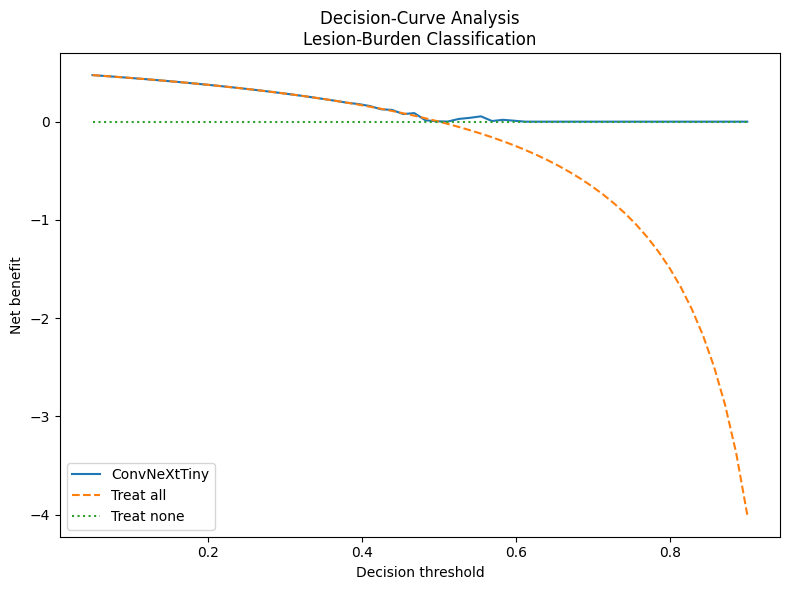

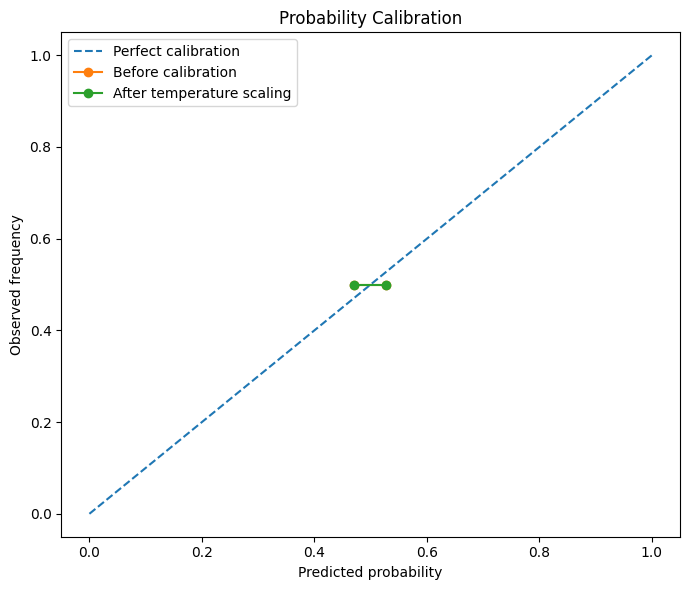


Grad-CAM target layer:
Sequential(
  (0): CNBlock(
    (block): Sequential(
      (0): Conv2d(768, 768, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=768)
      (1): Permute()
      (2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (3): Linear(in_features=768, out_features=3072, bias=True)
      (4): GELU(approximate='none')
      (5): Linear(in_features=3072, out_features=768, bias=True)
      (6): Permute()
    )
    (stochastic_depth): StochasticDepth(p=0.08823529411764706, mode=row)
  )
  (1): CNBlock(
    (block): Sequential(
      (0): Conv2d(768, 768, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=768)
      (1): Permute()
      (2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (3): Linear(in_features=768, out_features=3072, bias=True)
      (4): GELU(approximate='none')
      (5): Linear(in_features=3072, out_features=768, bias=True)
      (6): Permute()
    )
    (stochastic_depth): StochasticDepth(p=0.09411764705882353, mo

,Metric,GradCAM,GradCAM++
0,Mean IoU,0.0436,0.0370
1,Median IoU,0.0267,0.0197
2,Mean Dice,0.0788,0.0674
3,Pointing-game accuracy,0.0849,0.0472
4,Mean lesion energy fraction,0.1187,0.0949



Correct vs incorrect prediction XAI:


GradCAM_IoU                     GradCAMPP_IoU                      \
               mean    median       std          mean    median       std   
correct                                                                     
False      0.043045  0.033605  0.048707      0.035317  0.015046  0.053954   
True       0.044104  0.019659  0.058891      0.038596  0.023350  0.043795   

        GradCAM_Energy                     GradCAMPP_Energy            \
                  mean    median       std             mean    median   
correct                                                                 
False         0.113530  0.064817  0.115959         0.084783  0.053721   
True          0.123879  0.094240  0.110294         0.104991  0.077498   

                   
              std  
correct            
False    0.083407  
True     0.102956


CAM-threshold sensitivity:


,threshold,IoU,Dice
0,0.3,0.0823,0.1424
1,0.4,0.0613,0.1090
2,0.5,0.0436,0.0788
3,0.6,0.0285,0.0515
4,0.7,0.0161,0.0293


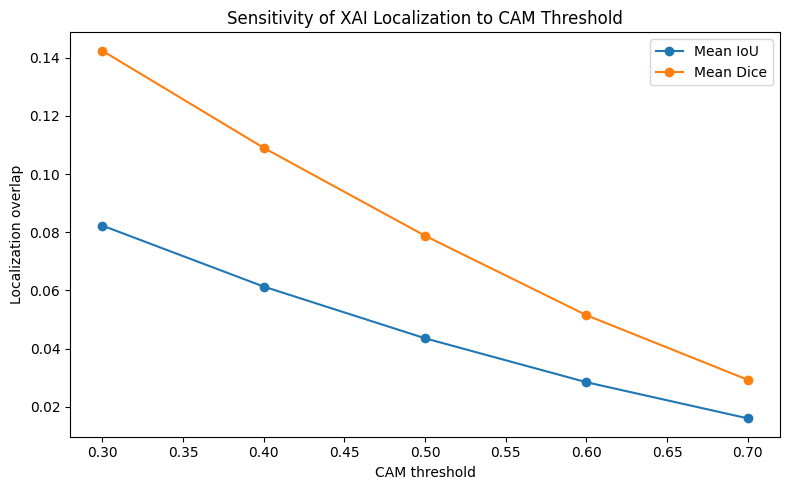

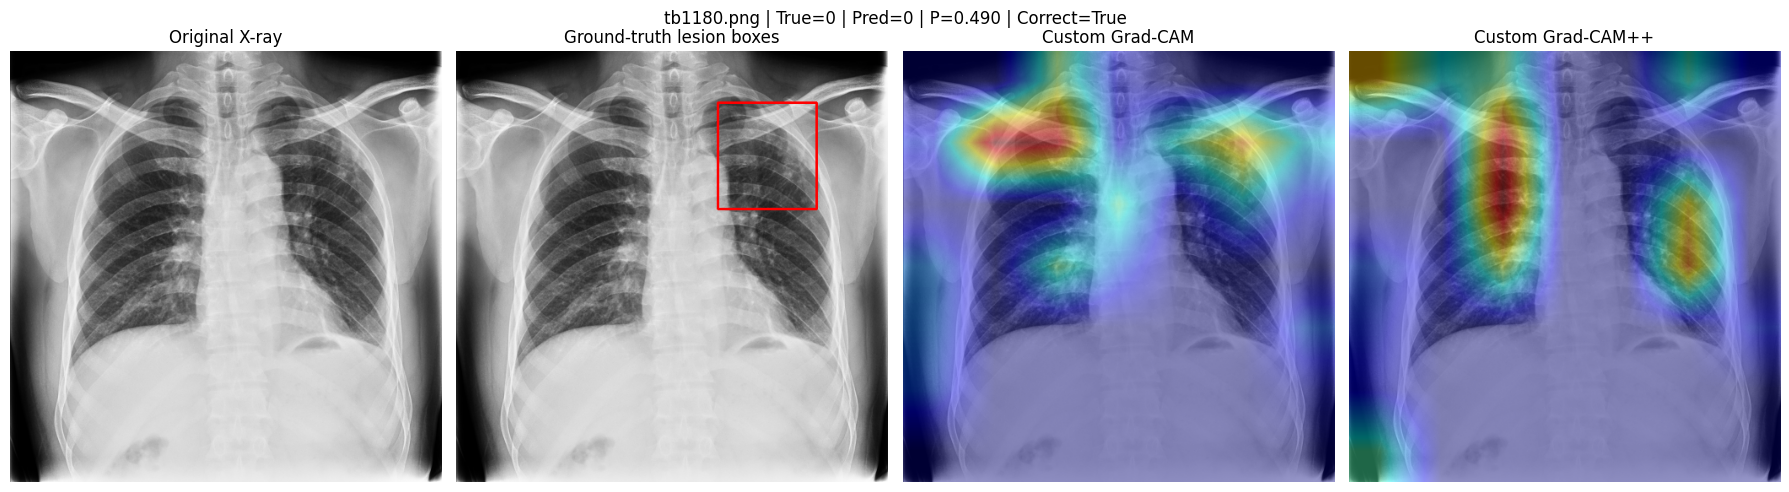

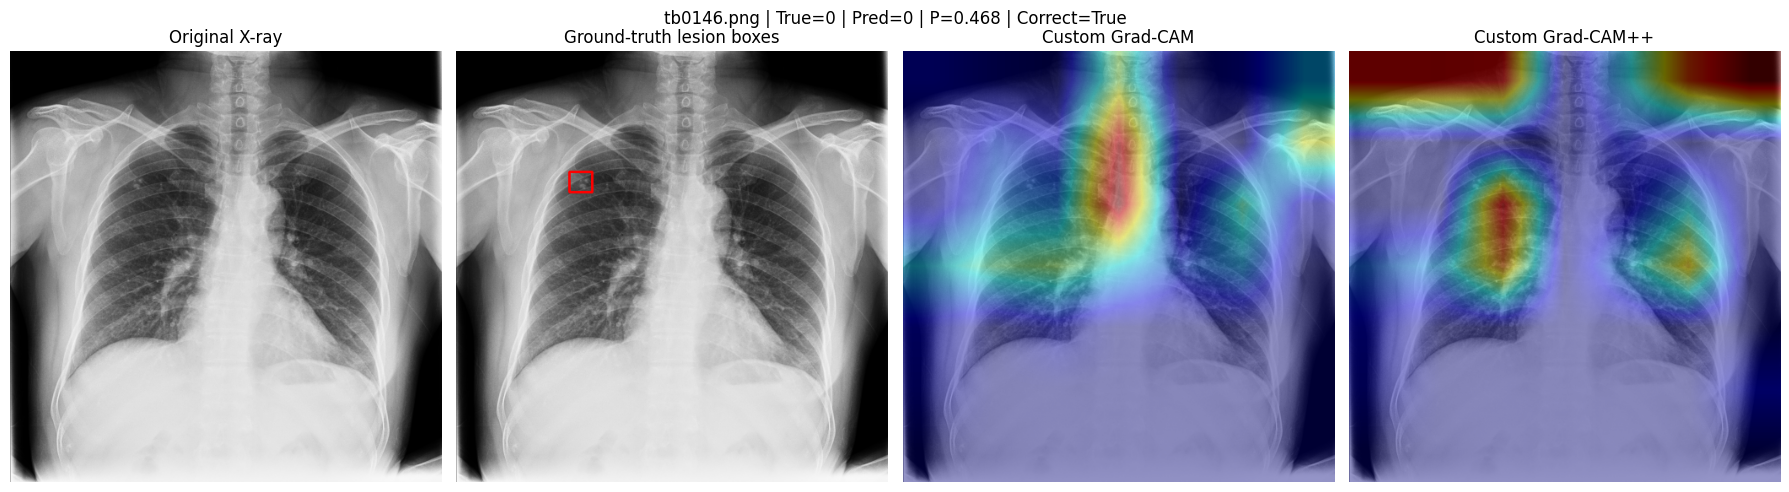

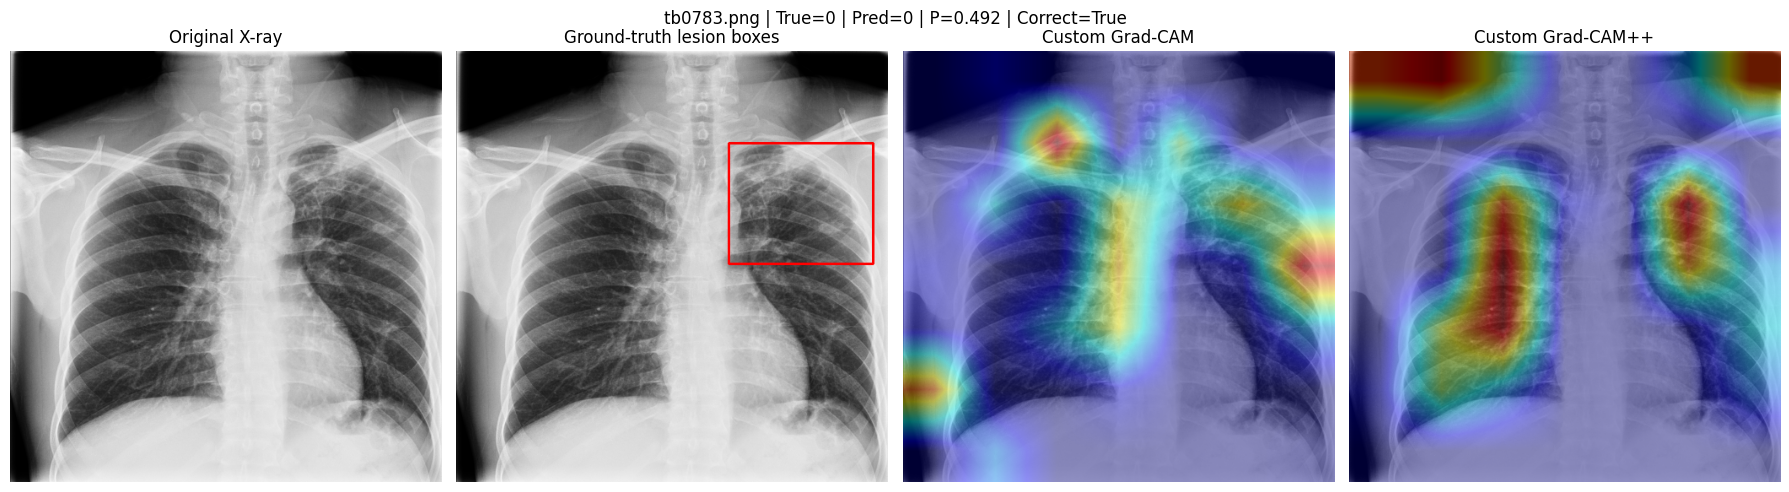

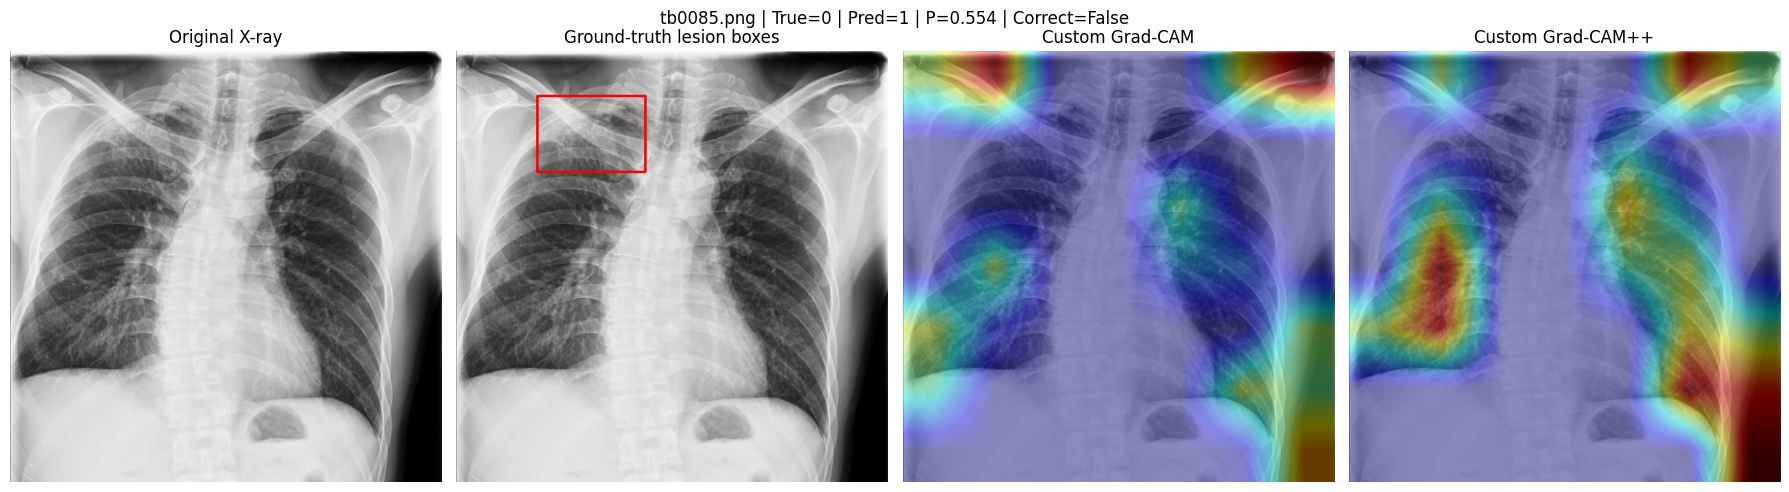

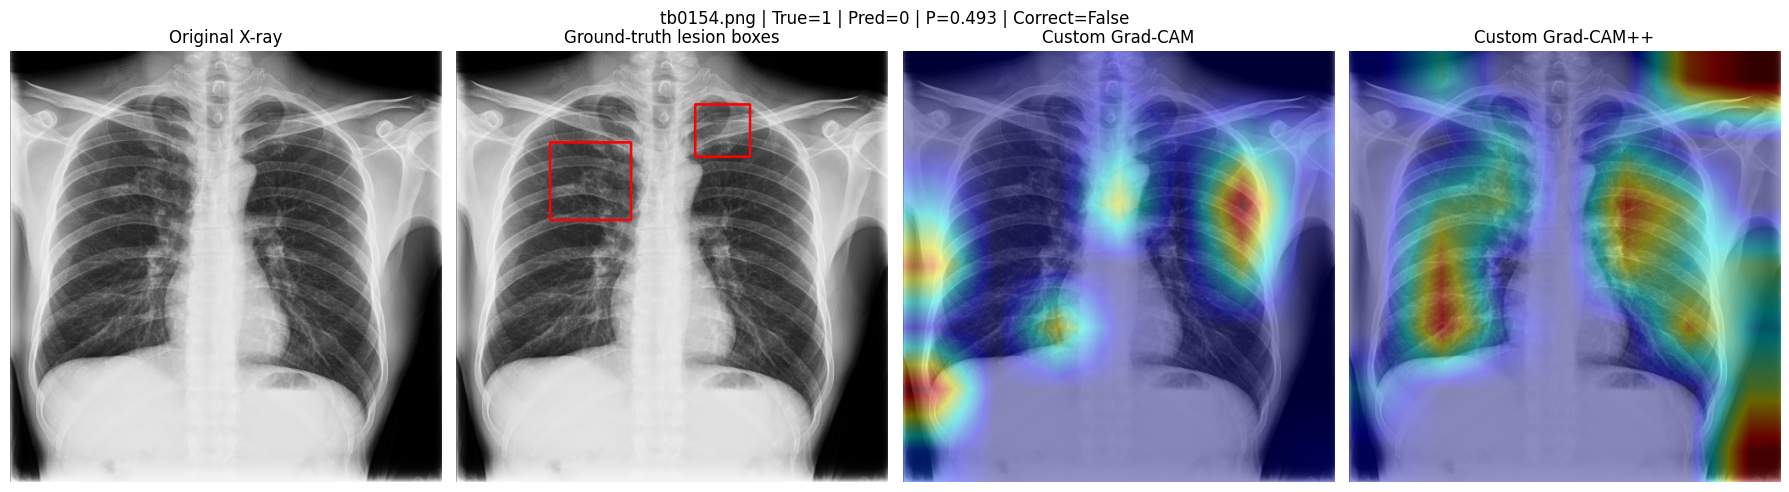

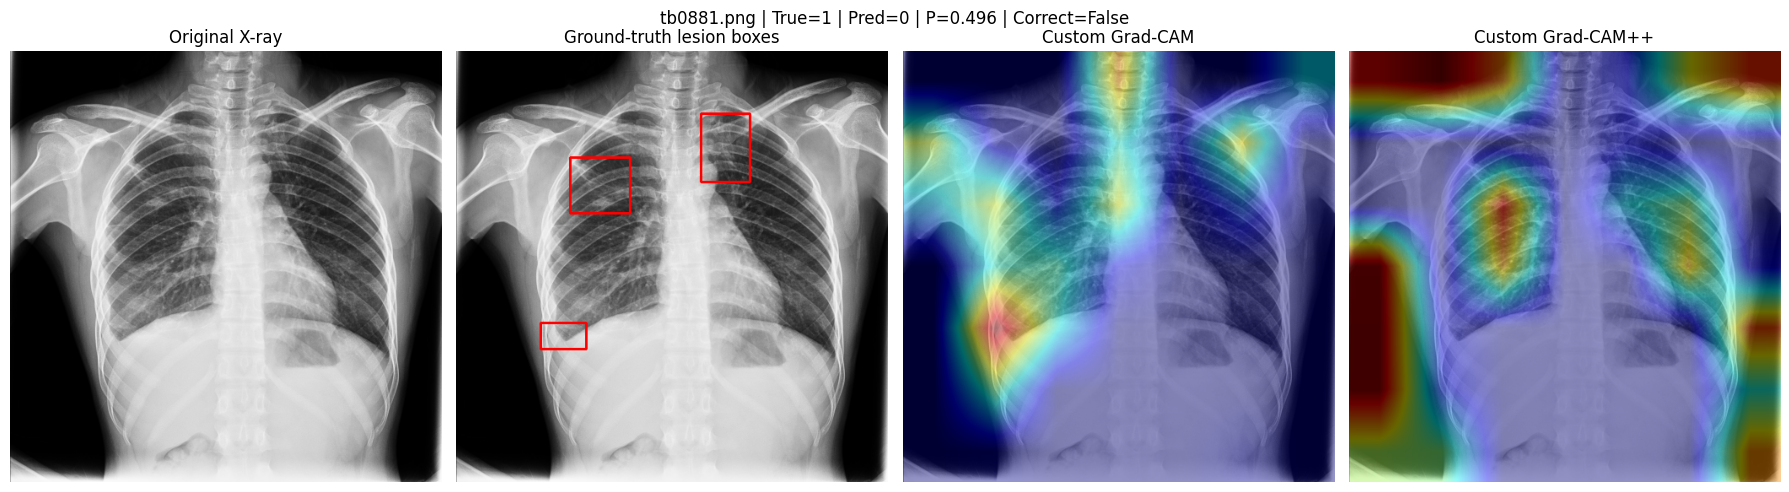

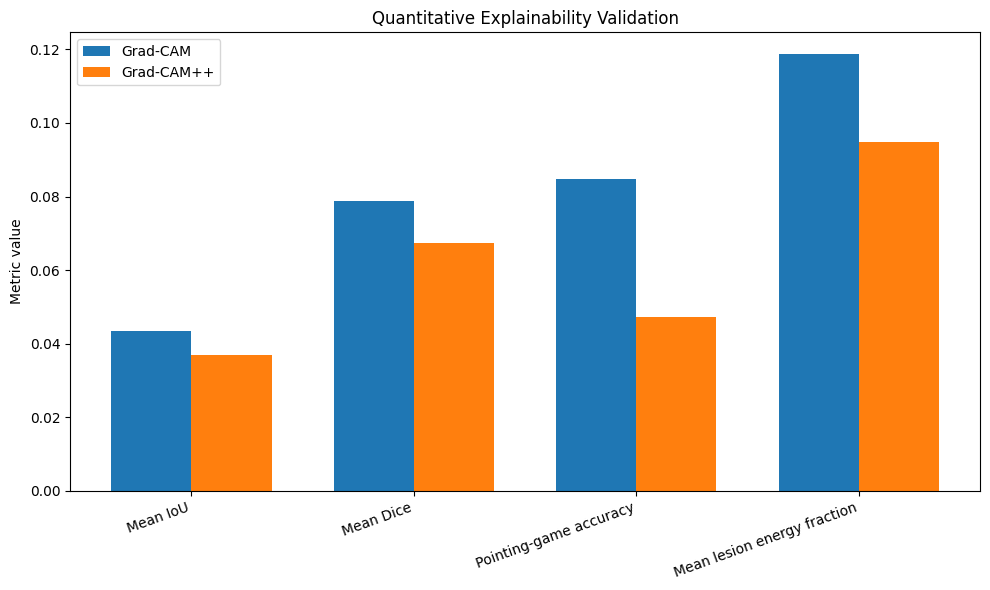


Failure-mode XAI summary:


,Outcome_Type,N,Mean_GradCAM_IoU,Mean_GradCAMPP_IoU,Mean_GradCAM_Energy,Mean_GradCAMPP_Energy,Pointing_Accuracy
0,False negative,23,0.0708,0.0667,0.2019,0.1461,0.2174
1,False positive,30,0.0218,0.0112,0.0458,0.0378,0.0000
2,True negative,23,0.0617,0.0315,0.0909,0.0597,0.0870
3,True positive,30,0.0306,0.0441,0.1492,0.1397,0.0667



STAGE 9 + 10 COMPLETE
Selected model                 : ConvNeXtTiny
Temperature                    : 0.9915
Calibrated threshold           : 0.4959
Test AUROC                     : 0.5333
Test AUPRC                     : 0.5847
Grad-CAM mean IoU              : 0.0436
Grad-CAM++ mean IoU            : 0.0370
Grad-CAM pointing accuracy     : 0.0849
Grad-CAM++ pointing accuracy   : 0.0472
Grad-CAM lesion energy         : 0.1187
Grad-CAM++ lesion energy       : 0.0949

Outputs saved to:
/kaggle/working/TB_XAI_Stage9_10_XAI

Completed:
✓ Validation-only model selection
✓ Temperature scaling
✓ Calibration analysis
✓ Decision-curve analysis
✓ Custom Grad-CAM
✓ Custom Grad-CAM++
✓ Ground-truth lesion-mask reconstruction
✓ CAM IoU
✓ CAM Dice overlap
✓ Pointing-game localization
✓ Explanation-energy localization
✓ CAM-threshold sensitivity
✓ Correct-vs-error XAI analysis
✓ Failure-mode XAI analysis

NEXT
Stage 11: YOLO lesion detector evaluation
Stage 12: CNN-XAI vs YOLO localization comparison


In [6]:
# ============================================================
# TB-XAI
# STAGE 9 + 10
#
# ADVANCED CALIBRATION + CUSTOM XAI +
# QUANTITATIVE LOCALIZATION VALIDATION
#
# Requires previous notebook objects:
#   results
#   image_df
#   box_df
#   eval_transform
#   DEVICE
#
# Includes:
# ✓ Final architecture chosen from VALIDATION only
# ✓ Temperature scaling
# ✓ Brier score before/after calibration
# ✓ ECE before/after calibration
# ✓ Validation-only threshold selection
# ✓ Decision-curve / net-benefit analysis
# ✓ Custom Grad-CAM from scratch
# ✓ Custom Grad-CAM++ from scratch
# ✓ Ground-truth lesion masks
# ✓ CAM IoU
# ✓ Dice overlap
# ✓ Pointing-game accuracy
# ✓ Heatmap energy inside lesion
# ✓ Correct vs error explanation analysis
# ✓ XAI examples
# ✓ Research-grade CSV outputs
# ============================================================


# ============================================================
# 1. LIBRARIES
# ============================================================

import gc
import math
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    matthews_corrcoef,
    brier_score_loss,
    roc_curve
)

warnings.filterwarnings("ignore")


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ============================================================
# 3. REQUIRED OBJECT CHECK
# ============================================================

required_objects = [
    "results",
    "image_df",
    "box_df",
    "eval_transform",
    "DEVICE"
]

missing = [
    obj
    for obj in required_objects
    if obj not in globals()
]

if missing:

    raise RuntimeError(
        "Please run previous stages first.\n"
        f"Missing objects: {missing}"
    )


# ============================================================
# 4. OUTPUT DIRECTORIES
# ============================================================

STAGE910_ROOT = Path(
    "/kaggle/working/TB_XAI_Stage9_10_XAI"
)

FIG_DIR = STAGE910_ROOT / "figures"
TABLE_DIR = STAGE910_ROOT / "tables"
CAM_DIR = STAGE910_ROOT / "cam_examples"

for directory in [
    STAGE910_ROOT,
    FIG_DIR,
    TABLE_DIR,
    CAM_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print("=" * 90)
print("TB-XAI — STAGE 9 + 10")
print("CALIBRATION + CUSTOM GRAD-CAM + LOCALIZATION VALIDATION")
print("=" * 90)


# ============================================================
# 5. SELECT MODEL USING VALIDATION AUROC ONLY
#
# NEVER choose model based on test AUROC.
# ============================================================

validation_scores = {}

for model_name, result in results.items():

    validation_scores[
        model_name
    ] = roc_auc_score(

        result["y_val"],
        result["p_val"]
    )


validation_selection_df = pd.DataFrame({

    "Model":
        list(
            validation_scores.keys()
        ),

    "Validation_AUROC":
        list(
            validation_scores.values()
        )
})


validation_selection_df = (
    validation_selection_df
    .sort_values(
        "Validation_AUROC",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\nValidation-only architecture selection:")

display(
    validation_selection_df.round(4)
)


FINAL_MODEL_NAME = (
    validation_selection_df
    .iloc[0][
        "Model"
    ]
)


FINAL_RESULT = results[
    FINAL_MODEL_NAME
]


FINAL_MODEL = FINAL_RESULT[
    "model"
]


FINAL_MODEL = FINAL_MODEL.to(
    DEVICE
)

FINAL_MODEL.eval()


print(
    f"\nSelected architecture: "
    f"{FINAL_MODEL_NAME}"
)


# ============================================================
# 6. ORIGINAL VALIDATION / TEST PROBABILITIES
# ============================================================

y_val = np.asarray(
    FINAL_RESULT["y_val"]
).astype(int)


p_val = np.asarray(
    FINAL_RESULT["p_val"]
).astype(float)


y_test = np.asarray(
    FINAL_RESULT["y_test"]
).astype(int)


p_test = np.asarray(
    FINAL_RESULT["p_test"]
).astype(float)


# ============================================================
# 7. PROBABILITY -> LOGIT
#
# logit(p) = log[p/(1-p)]
# ============================================================

def probability_to_logit(
    probability
):

    probability = np.clip(
        probability,
        1e-7,
        1 - 1e-7
    )

    return np.log(

        probability

        /

        (
            1
            -
            probability
        )
    )


val_logits_np = probability_to_logit(
    p_val
)


test_logits_np = probability_to_logit(
    p_test
)


# ============================================================
# 8. TEMPERATURE SCALING
#
# calibrated probability:
#
# p = sigmoid(z / T)
#
# T learned ONLY on validation set.
# ============================================================

class TemperatureScaler(
    nn.Module
):

    def __init__(
        self
    ):

        super().__init__()

        self.log_temperature = (
            nn.Parameter(
                torch.zeros(
                    1
                )
            )
        )


    def forward(
        self,
        logits
    ):

        temperature = torch.exp(
            self.log_temperature
        )

        return (
            logits
            /
            temperature
        )


temperature_model = TemperatureScaler().to(
    DEVICE
)


val_logits_tensor = torch.tensor(

    val_logits_np,

    dtype=torch.float32,

    device=DEVICE
)


val_targets_tensor = torch.tensor(

    y_val,

    dtype=torch.float32,

    device=DEVICE
)


calibration_criterion = (
    nn.BCEWithLogitsLoss()
)


optimizer = torch.optim.LBFGS(

    temperature_model.parameters(),

    lr=0.05,

    max_iter=100
)


def closure():

    optimizer.zero_grad()

    scaled_logits = temperature_model(
        val_logits_tensor
    )

    loss = calibration_criterion(

        scaled_logits,

        val_targets_tensor
    )

    loss.backward()

    return loss


optimizer.step(
    closure
)


TEMPERATURE = float(

    torch.exp(
        temperature_model.log_temperature
    ).detach().cpu()
)


print("\n" + "=" * 90)
print("TEMPERATURE SCALING")
print("=" * 90)

print(
    f"Learned temperature T = "
    f"{TEMPERATURE:.4f}"
)


# ============================================================
# 9. APPLY CALIBRATION
# ============================================================

def calibrated_probability(
    logits,
    temperature
):

    logits = np.asarray(
        logits
    )

    scaled = (
        logits
        /
        temperature
    )

    scaled = np.clip(
        scaled,
        -50,
        50
    )

    return (

        1

        /

        (
            1
            +
            np.exp(
                -scaled
            )
        )
    )


p_val_cal = calibrated_probability(

    val_logits_np,

    TEMPERATURE
)


p_test_cal = calibrated_probability(

    test_logits_np,

    TEMPERATURE
)


# ============================================================
# 10. EXPECTED CALIBRATION ERROR
# ============================================================

def expected_calibration_error(

    y_true,

    probabilities,

    n_bins=10
):

    bins = np.linspace(
        0,
        1,
        n_bins + 1
    )


    ece = 0.0


    for i in range(
        n_bins
    ):

        if i < n_bins - 1:

            mask = (

                (
                    probabilities
                    >=
                    bins[i]
                )

                &

                (
                    probabilities
                    <
                    bins[
                        i + 1
                    ]
                )
            )

        else:

            mask = (

                probabilities
                >=
                bins[i]
            )


        if mask.sum() == 0:

            continue


        confidence = (
            probabilities[
                mask
            ].mean()
        )


        observed = (
            y_true[
                mask
            ].mean()
        )


        ece += (

            mask.mean()

            *

            abs(
                confidence
                -
                observed
            )
        )


    return float(
        ece
    )


# ============================================================
# 11. CALIBRATION COMPARISON
# ============================================================

calibration_table = pd.DataFrame({

    "Metric": [
        "Brier score",
        "ECE",
        "AUROC",
        "AUPRC"
    ],

    "Before": [

        brier_score_loss(
            y_test,
            p_test
        ),

        expected_calibration_error(
            y_test,
            p_test
        ),

        roc_auc_score(
            y_test,
            p_test
        ),

        average_precision_score(
            y_test,
            p_test
        )
    ],

    "After_Temperature_Scaling": [

        brier_score_loss(
            y_test,
            p_test_cal
        ),

        expected_calibration_error(
            y_test,
            p_test_cal
        ),

        roc_auc_score(
            y_test,
            p_test_cal
        ),

        average_precision_score(
            y_test,
            p_test_cal
        )
    ]
})


print("\nCalibration comparison:")

display(
    calibration_table.round(
        4
    )
)


calibration_table.to_csv(

    TABLE_DIR
    /
    "temperature_scaling_results.csv",

    index=False
)


# ============================================================
# 12. SELECT THRESHOLD USING VALIDATION ONLY
#
# Youden's J:
#
# J = Sensitivity + Specificity - 1
# ============================================================

fpr_val, tpr_val, thresholds_val = roc_curve(

    y_val,

    p_val_cal
)


youden = (
    tpr_val
    -
    fpr_val
)


best_threshold_index = np.argmax(
    youden
)


FINAL_THRESHOLD = float(

    thresholds_val[
        best_threshold_index
    ]
)


if not np.isfinite(
    FINAL_THRESHOLD
):

    FINAL_THRESHOLD = 0.5


print(
    f"\nValidation-selected calibrated threshold: "
    f"{FINAL_THRESHOLD:.4f}"
)


# ============================================================
# 13. FINAL CALIBRATED TEST METRICS
# ============================================================

test_prediction = (

    p_test_cal

    >=

    FINAL_THRESHOLD

).astype(
    int
)


tn, fp, fn, tp = confusion_matrix(

    y_test,

    test_prediction,

    labels=[
        0,
        1
    ]

).ravel()


sensitivity = (
    tp
    /
    (
        tp
        +
        fn
    )
)


specificity = (
    tn
    /
    (
        tn
        +
        fp
    )
)


final_metric_table = pd.DataFrame({

    "Metric": [

        "AUROC",
        "AUPRC",
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1",
        "MCC",
        "Brier score",
        "ECE",
        "Threshold"
    ],

    "Value": [

        roc_auc_score(
            y_test,
            p_test_cal
        ),

        average_precision_score(
            y_test,
            p_test_cal
        ),

        accuracy_score(
            y_test,
            test_prediction
        ),

        precision_score(
            y_test,
            test_prediction,
            zero_division=0
        ),

        sensitivity,

        specificity,

        f1_score(
            y_test,
            test_prediction,
            zero_division=0
        ),

        matthews_corrcoef(
            y_test,
            test_prediction
        ),

        brier_score_loss(
            y_test,
            p_test_cal
        ),

        expected_calibration_error(
            y_test,
            p_test_cal
        ),

        FINAL_THRESHOLD
    ]
})


print("\nFinal calibrated test performance:")

display(
    final_metric_table.round(
        4
    )
)


final_metric_table.to_csv(

    TABLE_DIR
    /
    "final_calibrated_test_metrics.csv",

    index=False
)


# ============================================================
# 14. DECISION CURVE ANALYSIS
#
# Net Benefit:
#
# NB =
# TP/N -
# FP/N * pt/(1-pt)
#
# Methodological demonstration only.
# Current task is lesion-burden classification,
# not clinical TB diagnosis.
# ============================================================

decision_thresholds = np.linspace(

    0.05,

    0.90,

    60
)


model_net_benefit = []

all_net_benefit = []

none_net_benefit = []


prevalence = y_test.mean()


for pt in decision_thresholds:

    pred = (
        p_test_cal
        >=
        pt
    ).astype(
        int
    )


    tn_d, fp_d, fn_d, tp_d = confusion_matrix(

        y_test,

        pred,

        labels=[
            0,
            1
        ]

    ).ravel()


    n = len(
        y_test
    )


    model_nb = (

        tp_d
        /
        n

        -

        fp_d
        /
        n

        *
        (
            pt
            /
            (
                1
                -
                pt
            )
        )
    )


    treat_all_nb = (

        prevalence

        -

        (
            1
            -
            prevalence
        )

        *
        (
            pt
            /
            (
                1
                -
                pt
            )
        )
    )


    model_net_benefit.append(
        model_nb
    )


    all_net_benefit.append(
        treat_all_nb
    )


    none_net_benefit.append(
        0
    )


plt.figure(
    figsize=(
        8,
        6
    )
)


plt.plot(

    decision_thresholds,

    model_net_benefit,

    label=FINAL_MODEL_NAME
)


plt.plot(

    decision_thresholds,

    all_net_benefit,

    linestyle="--",

    label="Treat all"
)


plt.plot(

    decision_thresholds,

    none_net_benefit,

    linestyle=":",

    label="Treat none"
)


plt.xlabel(
    "Decision threshold"
)

plt.ylabel(
    "Net benefit"
)

plt.title(
    "Decision-Curve Analysis\n"
    "Lesion-Burden Classification"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    FIG_DIR
    /
    "decision_curve_analysis.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 15. CALIBRATION PLOT
# ============================================================

def calibration_curve_points(

    y_true,

    probabilities,

    n_bins=8
):

    edges = np.linspace(
        0,
        1,
        n_bins + 1
    )


    mean_pred = []

    observed = []


    for i in range(
        n_bins
    ):

        if i < n_bins - 1:

            mask = (

                (
                    probabilities
                    >=
                    edges[i]
                )

                &

                (
                    probabilities
                    <
                    edges[
                        i + 1
                    ]
                )
            )

        else:

            mask = (

                probabilities
                >=
                edges[i]
            )


        if mask.sum() == 0:

            continue


        mean_pred.append(

            probabilities[
                mask
            ].mean()
        )


        observed.append(

            y_true[
                mask
            ].mean()
        )


    return (

        np.asarray(
            mean_pred
        ),

        np.asarray(
            observed
        )
    )


before_x, before_y = calibration_curve_points(

    y_test,

    p_test
)


after_x, after_y = calibration_curve_points(

    y_test,

    p_test_cal
)


plt.figure(
    figsize=(
        7,
        6
    )
)


plt.plot(

    [
        0,
        1
    ],

    [
        0,
        1
    ],

    linestyle="--",

    label="Perfect calibration"
)


plt.plot(

    before_x,

    before_y,

    marker="o",

    label="Before calibration"
)


plt.plot(

    after_x,

    after_y,

    marker="o",

    label="After temperature scaling"
)


plt.xlabel(
    "Predicted probability"
)

plt.ylabel(
    "Observed frequency"
)

plt.title(
    "Probability Calibration"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    FIG_DIR
    /
    "temperature_calibration_curve.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 16. FIND FINAL CONVOLUTIONAL TARGET LAYER
# ============================================================

if FINAL_MODEL_NAME == "DenseNet121":

    TARGET_LAYER = (
        FINAL_MODEL
        .features
        .norm5
    )


elif FINAL_MODEL_NAME == "ConvNeXtTiny":

    TARGET_LAYER = (
        FINAL_MODEL
        .features[
            -1
        ]
    )


else:

    raise ValueError(
        f"Unknown architecture: "
        f"{FINAL_MODEL_NAME}"
    )


print("\nGrad-CAM target layer:")

print(
    TARGET_LAYER
)


# ============================================================
# 17. CUSTOM CAM EXTRACTOR
#
# No external grad-cam package.
# ============================================================

class CustomCAM:

    def __init__(

        self,

        model,

        target_layer
    ):

        self.model = model

        self.target_layer = (
            target_layer
        )

        self.activations = None

        self.gradients = None


        self.forward_handle = (

            target_layer
            .register_forward_hook(
                self._forward_hook
            )
        )


    def _forward_hook(

        self,

        module,

        inputs,

        output
    ):

        self.activations = output


        if output.requires_grad:

            output.register_hook(
                self._gradient_hook
            )


    def _gradient_hook(

        self,

        gradient
    ):

        self.gradients = gradient


    def remove(
        self
    ):

        self.forward_handle.remove()


# ============================================================
# 18. NORMALIZE CAM
# ============================================================

def normalize_cam(
    cam
):

    cam = cam.astype(
        np.float32
    )


    cam -= cam.min()


    max_value = cam.max()


    if max_value > 0:

        cam /= max_value


    return cam


# ============================================================
# 19. CUSTOM GRAD-CAM
#
# alpha_k^c =
#
# 1/Z Σ_i Σ_j
# ∂y^c / ∂A_ij^k
#
# L^c =
#
# ReLU(
# Σ_k alpha_k^c A^k
# )
# ============================================================

def generate_gradcam(

    model,

    cam_extractor,

    input_tensor,

    target_class
):

    model.zero_grad(
        set_to_none=True
    )


    output = model(
        input_tensor
    ).reshape(
        -1
    )


    logit = output[
        0
    ]


    # Binary classifier:
    # positive class -> +logit
    # negative class -> -logit

    if target_class == 1:

        score = logit

    else:

        score = -logit


    score.backward(
        retain_graph=True
    )


    activations = (

        cam_extractor
        .activations
        .detach()
    )


    gradients = (

        cam_extractor
        .gradients
        .detach()
    )


    weights = gradients.mean(

        dim=(
            2,
            3
        ),

        keepdim=True
    )


    cam = (

        weights

        *

        activations

    ).sum(
        dim=1
    )


    cam = F.relu(
        cam
    )


    cam = cam[
        0
    ].cpu().numpy()


    return normalize_cam(
        cam
    )


# ============================================================
# 20. CUSTOM GRAD-CAM++
#
# Standard Grad-CAM++ weighting form.
# ============================================================

def generate_gradcam_pp(

    model,

    cam_extractor,

    input_tensor,

    target_class
):

    model.zero_grad(
        set_to_none=True
    )


    output = model(
        input_tensor
    ).reshape(
        -1
    )


    logit = output[
        0
    ]


    score = (

        logit

        if target_class == 1

        else -logit
    )


    score.backward(
        retain_graph=True
    )


    activations = (

        cam_extractor
        .activations
        .detach()
    )


    gradients = (

        cam_extractor
        .gradients
        .detach()
    )


    gradients_2 = (
        gradients ** 2
    )


    gradients_3 = (
        gradients ** 3
    )


    spatial_sum = (

        activations

        *
        gradients_3

    ).sum(

        dim=(
            2,
            3
        ),

        keepdim=True
    )


    denominator = (

        2
        *
        gradients_2

        +

        spatial_sum

        +

        1e-8
    )


    alpha = (

        gradients_2

        /

        denominator
    )


    positive_gradients = F.relu(
        gradients
    )


    weights = (

        alpha

        *
        positive_gradients

    ).sum(

        dim=(
            2,
            3
        ),

        keepdim=True
    )


    cam = (

        weights

        *
        activations

    ).sum(
        dim=1
    )


    cam = F.relu(
        cam
    )


    cam = cam[
        0
    ].cpu().numpy()


    return normalize_cam(
        cam
    )


# ============================================================
# 21. GROUND-TRUTH LESION MASK
# ============================================================

def create_ground_truth_mask(

    filename,

    width,

    height
):

    mask = np.zeros(

        (
            height,
            width
        ),

        dtype=np.uint8
    )


    image_boxes = box_df[

        box_df[
            "filename"
        ]
        ==
        filename

    ]


    for _, box in image_boxes.iterrows():

        x1 = int(

            np.clip(
                box[
                    "x1"
                ],
                0,
                1
            )

            *
            width
        )


        y1 = int(

            np.clip(
                box[
                    "y1"
                ],
                0,
                1
            )

            *
            height
        )


        x2 = int(

            np.clip(
                box[
                    "x2"
                ],
                0,
                1
            )

            *
            width
        )


        y2 = int(

            np.clip(
                box[
                    "y2"
                ],
                0,
                1
            )

            *
            height
        )


        mask[
            y1:y2,
            x1:x2
        ] = 1


    return mask


# ============================================================
# 22. LOCALIZATION METRICS
# ============================================================

def cam_localization_metrics(

    cam,

    gt_mask,

    threshold=0.50
):

    # --------------------------------
    # Resize CAM to GT resolution
    # --------------------------------

    height, width = (
        gt_mask.shape
    )


    cam_resized = cv2.resize(

        cam,

        (
            width,
            height
        ),

        interpolation=cv2.INTER_LINEAR
    )


    cam_resized = normalize_cam(
        cam_resized
    )


    # --------------------------------
    # Binary CAM
    # --------------------------------

    cam_binary = (

        cam_resized

        >=

        threshold

    ).astype(
        np.uint8
    )


    intersection = np.logical_and(

        cam_binary,

        gt_mask

    ).sum()


    union = np.logical_or(

        cam_binary,

        gt_mask

    ).sum()


    iou = (

        intersection
        /
        union

        if union > 0

        else np.nan
    )


    # --------------------------------
    # Dice
    # --------------------------------

    denominator = (

        cam_binary.sum()

        +
        gt_mask.sum()
    )


    dice = (

        2
        *
        intersection

        /
        denominator

        if denominator > 0

        else np.nan
    )


    # --------------------------------
    # Pointing game
    #
    # Maximum activation must fall
    # inside GT lesion.
    # --------------------------------

    max_location = np.unravel_index(

        np.argmax(
            cam_resized
        ),

        cam_resized.shape
    )


    pointing_hit = int(

        gt_mask[
            max_location
        ]
        >
        0
    )


    # --------------------------------
    # Explanation energy fraction
    #
    # Σ CAM inside lesion
    # --------------------
    # Σ CAM total
    # --------------------------------

    total_energy = (
        cam_resized.sum()
        +
        1e-12
    )


    lesion_energy = (
        cam_resized[
            gt_mask > 0
        ].sum()
    )


    energy_fraction = (

        lesion_energy

        /
        total_energy
    )


    return {

        "IoU":
            iou,

        "Dice":
            dice,

        "Pointing_Hit":
            pointing_hit,

        "Lesion_Energy_Fraction":
            energy_fraction
    }


# ============================================================
# 23. TEST IMAGE DATAFRAME
# ============================================================

test_image_df = image_df[

    image_df[
        "final_split"
    ]
    ==
    "test"

].copy()


test_image_df[
    "target"
] = (

    test_image_df[
        "lesion_count"
    ]

    >= 2

).astype(
    int
)


# Map Stage-8 probabilities by filename

probability_map = dict(

    zip(

        FINAL_RESULT[
            "test_names"
        ],

        p_test_cal
    )
)


test_image_df[
    "probability"
] = test_image_df[
    "filename"
].map(
    probability_map
)


test_image_df = test_image_df.dropna(

    subset=[
        "probability"
    ]

).copy()


test_image_df[
    "prediction"
] = (

    test_image_df[
        "probability"
    ]

    >=

    FINAL_THRESHOLD

).astype(
    int
)


test_image_df[
    "correct"
] = (

    test_image_df[
        "prediction"
    ]

    ==
    test_image_df[
        "target"
    ]
)


# ============================================================
# 24. RUN CUSTOM XAI ON FULL TEST SET
# ============================================================

cam_extractor = CustomCAM(

    FINAL_MODEL,

    TARGET_LAYER
)


xai_records = []


print("\n" + "=" * 90)
print("RUNNING QUANTITATIVE XAI VALIDATION")
print("=" * 90)


for index, row in test_image_df.iterrows():

    image_path = row[
        "image_path"
    ]


    filename = row[
        "filename"
    ]


    pil_image = Image.open(
        image_path
    ).convert(
        "RGB"
    )


    original_rgb = np.asarray(
        pil_image
    )


    height, width = original_rgb.shape[
        :2
    ]


    input_tensor = eval_transform(
        pil_image
    ).unsqueeze(
        0
    ).to(
        DEVICE
    )


    # Explain predicted class

    predicted_class = int(
        row[
            "prediction"
        ]
    )


    # --------------------------------
    # Grad-CAM
    # --------------------------------

    gradcam = generate_gradcam(

        FINAL_MODEL,

        cam_extractor,

        input_tensor,

        predicted_class
    )


    # --------------------------------
    # Grad-CAM++
    # --------------------------------

    gradcam_pp = generate_gradcam_pp(

        FINAL_MODEL,

        cam_extractor,

        input_tensor,

        predicted_class
    )


    # --------------------------------
    # Ground truth lesion mask
    # --------------------------------

    gt_mask = create_ground_truth_mask(

        filename,

        width,

        height
    )


    # --------------------------------
    # Metrics
    # --------------------------------

    metrics_cam = cam_localization_metrics(

        gradcam,

        gt_mask,

        threshold=0.50
    )


    metrics_pp = cam_localization_metrics(

        gradcam_pp,

        gt_mask,

        threshold=0.50
    )


    xai_records.append({

        "filename":
            filename,

        "target":
            int(
                row[
                    "target"
                ]
            ),

        "prediction":
            predicted_class,

        "correct":
            bool(
                row[
                    "correct"
                ]
            ),

        "probability":
            float(
                row[
                    "probability"
                ]
            ),

        "GradCAM_IoU":
            metrics_cam[
                "IoU"
            ],

        "GradCAM_Dice":
            metrics_cam[
                "Dice"
            ],

        "GradCAM_Pointing":
            metrics_cam[
                "Pointing_Hit"
            ],

        "GradCAM_Energy":
            metrics_cam[
                "Lesion_Energy_Fraction"
            ],

        "GradCAMPP_IoU":
            metrics_pp[
                "IoU"
            ],

        "GradCAMPP_Dice":
            metrics_pp[
                "Dice"
            ],

        "GradCAMPP_Pointing":
            metrics_pp[
                "Pointing_Hit"
            ],

        "GradCAMPP_Energy":
            metrics_pp[
                "Lesion_Energy_Fraction"
            ]
    })


cam_extractor.remove()


xai_df = pd.DataFrame(
    xai_records
)


# ============================================================
# 25. XAI SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("QUANTITATIVE XAI RESULTS")
print("=" * 90)


xai_summary = pd.DataFrame({

    "Metric": [

        "Mean IoU",
        "Median IoU",
        "Mean Dice",
        "Pointing-game accuracy",
        "Mean lesion energy fraction"
    ],

    "GradCAM": [

        xai_df[
            "GradCAM_IoU"
        ].mean(),

        xai_df[
            "GradCAM_IoU"
        ].median(),

        xai_df[
            "GradCAM_Dice"
        ].mean(),

        xai_df[
            "GradCAM_Pointing"
        ].mean(),

        xai_df[
            "GradCAM_Energy"
        ].mean()
    ],

    "GradCAM++": [

        xai_df[
            "GradCAMPP_IoU"
        ].mean(),

        xai_df[
            "GradCAMPP_IoU"
        ].median(),

        xai_df[
            "GradCAMPP_Dice"
        ].mean(),

        xai_df[
            "GradCAMPP_Pointing"
        ].mean(),

        xai_df[
            "GradCAMPP_Energy"
        ].mean()
    ]
})


display(
    xai_summary.round(
        4
    )
)


xai_summary.to_csv(

    TABLE_DIR
    /
    "quantitative_xai_summary.csv",

    index=False
)


xai_df.to_csv(

    TABLE_DIR
    /
    "image_level_xai_metrics.csv",

    index=False
)


# ============================================================
# 26. CORRECT vs INCORRECT XAI
# ============================================================

correct_error_summary = (

    xai_df
    .groupby(
        "correct"
    )[
        [
            "GradCAM_IoU",
            "GradCAMPP_IoU",
            "GradCAM_Energy",
            "GradCAMPP_Energy"
        ]
    ]
    .agg(
        [
            "mean",
            "median",
            "std"
        ]
    )
)


print(
    "\nCorrect vs incorrect prediction XAI:"
)

display(
    correct_error_summary
)


correct_error_summary.to_csv(

    TABLE_DIR
    /
    "correct_vs_error_xai.csv"
)


# ============================================================
# 27. CAM THRESHOLD SENSITIVITY
#
# Avoid presenting IoU from only one arbitrary
# CAM threshold.
# ============================================================

CAM_THRESHOLDS = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]


threshold_records = []


cam_extractor = CustomCAM(

    FINAL_MODEL,

    TARGET_LAYER
)


for _, row in test_image_df.iterrows():

    pil_image = Image.open(

        row[
            "image_path"
        ]

    ).convert(
        "RGB"
    )


    rgb = np.asarray(
        pil_image
    )


    h, w = rgb.shape[
        :2
    ]


    input_tensor = eval_transform(
        pil_image
    ).unsqueeze(
        0
    ).to(
        DEVICE
    )


    predicted_class = int(
        row[
            "prediction"
        ]
    )


    cam = generate_gradcam(

        FINAL_MODEL,

        cam_extractor,

        input_tensor,

        predicted_class
    )


    gt_mask = create_ground_truth_mask(

        row[
            "filename"
        ],

        w,

        h
    )


    for threshold in CAM_THRESHOLDS:

        metrics = cam_localization_metrics(

            cam,

            gt_mask,

            threshold=threshold
        )


        threshold_records.append({

            "filename":
                row[
                    "filename"
                ],

            "threshold":
                threshold,

            "IoU":
                metrics[
                    "IoU"
                ],

            "Dice":
                metrics[
                    "Dice"
                ]
        })


cam_extractor.remove()


threshold_df = pd.DataFrame(
    threshold_records
)


threshold_summary = (

    threshold_df
    .groupby(
        "threshold"
    )[
        [
            "IoU",
            "Dice"
        ]
    ]
    .mean()
    .reset_index()
)


print(
    "\nCAM-threshold sensitivity:"
)

display(
    threshold_summary.round(
        4
    )
)


threshold_summary.to_csv(

    TABLE_DIR
    /
    "cam_threshold_sensitivity.csv",

    index=False
)


# ============================================================
# 28. CAM THRESHOLD SENSITIVITY FIGURE
# ============================================================

plt.figure(
    figsize=(
        8,
        5
    )
)


plt.plot(

    threshold_summary[
        "threshold"
    ],

    threshold_summary[
        "IoU"
    ],

    marker="o",

    label="Mean IoU"
)


plt.plot(

    threshold_summary[
        "threshold"
    ],

    threshold_summary[
        "Dice"
    ],

    marker="o",

    label="Mean Dice"
)


plt.xlabel(
    "CAM threshold"
)

plt.ylabel(
    "Localization overlap"
)

plt.title(
    "Sensitivity of XAI Localization to CAM Threshold"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    FIG_DIR
    /
    "cam_threshold_sensitivity.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 29. HELPER FOR HEATMAP OVERLAY
# ============================================================

def overlay_cam(

    rgb_image,

    cam,

    alpha=0.40
):

    height, width = rgb_image.shape[
        :2
    ]


    cam_resized = cv2.resize(

        cam,

        (
            width,
            height
        )
    )


    cam_uint8 = np.uint8(

        255
        *
        normalize_cam(
            cam_resized
        )
    )


    heatmap = cv2.applyColorMap(

        cam_uint8,

        cv2.COLORMAP_JET
    )


    heatmap = cv2.cvtColor(

        heatmap,

        cv2.COLOR_BGR2RGB
    )


    overlay = (

        (
            1
            -
            alpha
        )
        *
        rgb_image.astype(
            np.float32
        )

        +

        alpha
        *
        heatmap.astype(
            np.float32
        )
    )


    return np.uint8(

        np.clip(
            overlay,
            0,
            255
        )
    )


# ============================================================
# 30. EXAMPLE XAI VISUALIZATIONS
# ============================================================

example_df = test_image_df.copy()


# Prefer mixture of correct and incorrect

correct_examples = (
    example_df[
        example_df[
            "correct"
        ]
    ]
    .head(
        3
    )
)


error_examples = (
    example_df[
        ~example_df[
            "correct"
        ]
    ]
    .head(
        3
    )
)


visual_examples = pd.concat(

    [
        correct_examples,
        error_examples
    ],

    ignore_index=True
)


cam_extractor = CustomCAM(

    FINAL_MODEL,

    TARGET_LAYER
)


for example_number, row in visual_examples.iterrows():

    pil_image = Image.open(

        row[
            "image_path"
        ]

    ).convert(
        "RGB"
    )


    rgb = np.asarray(
        pil_image
    )


    h, w = rgb.shape[
        :2
    ]


    input_tensor = eval_transform(
        pil_image
    ).unsqueeze(
        0
    ).to(
        DEVICE
    )


    predicted_class = int(
        row[
            "prediction"
        ]
    )


    cam = generate_gradcam(

        FINAL_MODEL,

        cam_extractor,

        input_tensor,

        predicted_class
    )


    cam_pp = generate_gradcam_pp(

        FINAL_MODEL,

        cam_extractor,

        input_tensor,

        predicted_class
    )


    overlay = overlay_cam(

        rgb,

        cam
    )


    overlay_pp = overlay_cam(

        rgb,

        cam_pp
    )


    gt_mask = create_ground_truth_mask(

        row[
            "filename"
        ],

        w,

        h
    )


    gt_overlay = rgb.copy()


    contours, _ = cv2.findContours(

        gt_mask.astype(
            np.uint8
        ),

        cv2.RETR_EXTERNAL,

        cv2.CHAIN_APPROX_SIMPLE
    )


    gt_overlay = cv2.drawContours(

        gt_overlay.copy(),

        contours,

        -1,

        (
            255,
            0,
            0
        ),

        max(
            2,
            int(
                min(
                    h,
                    w
                )
                /
                300
            )
        )
    )


    fig, axes = plt.subplots(

        1,
        4,

        figsize=(
            18,
            5
        )
    )


    axes[
        0
    ].imshow(
        rgb
    )


    axes[
        0
    ].set_title(
        "Original X-ray"
    )


    axes[
        1
    ].imshow(
        gt_overlay
    )


    axes[
        1
    ].set_title(
        "Ground-truth lesion boxes"
    )


    axes[
        2
    ].imshow(
        overlay
    )


    axes[
        2
    ].set_title(
        "Custom Grad-CAM"
    )


    axes[
        3
    ].imshow(
        overlay_pp
    )


    axes[
        3
    ].set_title(
        "Custom Grad-CAM++"
    )


    for axis in axes:

        axis.axis(
            "off"
        )


    plt.suptitle(

        f"{row['filename']} | "
        f"True={row['target']} | "
        f"Pred={row['prediction']} | "
        f"P={row['probability']:.3f} | "
        f"Correct={row['correct']}"
    )


    plt.tight_layout()


    plt.savefig(

        CAM_DIR
        /
        f"xai_example_{example_number+1}.png",

        dpi=300,

        bbox_inches="tight"
    )


    plt.show()


cam_extractor.remove()


# ============================================================
# 31. GRADCAM vs GRADCAM++ COMPARISON FIGURE
# ============================================================

metric_names = [
    "Mean IoU",
    "Mean Dice",
    "Pointing-game accuracy",
    "Mean lesion energy fraction"
]


gradcam_values = [

    xai_df[
        "GradCAM_IoU"
    ].mean(),

    xai_df[
        "GradCAM_Dice"
    ].mean(),

    xai_df[
        "GradCAM_Pointing"
    ].mean(),

    xai_df[
        "GradCAM_Energy"
    ].mean()
]


gradcampp_values = [

    xai_df[
        "GradCAMPP_IoU"
    ].mean(),

    xai_df[
        "GradCAMPP_Dice"
    ].mean(),

    xai_df[
        "GradCAMPP_Pointing"
    ].mean(),

    xai_df[
        "GradCAMPP_Energy"
    ].mean()
]


x = np.arange(
    len(
        metric_names
    )
)


width = 0.36


plt.figure(
    figsize=(
        10,
        6
    )
)


plt.bar(

    x
    -
    width
    /
    2,

    gradcam_values,

    width,

    label="Grad-CAM"
)


plt.bar(

    x
    +
    width
    /
    2,

    gradcampp_values,

    width,

    label="Grad-CAM++"
)


plt.xticks(

    x,

    metric_names,

    rotation=20,

    ha="right"
)


plt.ylabel(
    "Metric value"
)

plt.title(
    "Quantitative Explainability Validation"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    FIG_DIR
    /
    "gradcam_vs_gradcampp.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# 32. FAILURE-MODE TABLE
# ============================================================

def failure_type(
    row
):

    if row[
        "target"
    ] == 1 and row[
        "prediction"
    ] == 0:

        return "False negative"

    elif row[
        "target"
    ] == 0 and row[
        "prediction"
    ] == 1:

        return "False positive"

    elif row[
        "target"
    ] == 1:

        return "True positive"

    else:

        return "True negative"


xai_df[
    "Outcome_Type"
] = xai_df.apply(

    failure_type,

    axis=1
)


failure_summary = (

    xai_df
    .groupby(
        "Outcome_Type"
    )
    .agg(

        N=(
            "filename",
            "size"
        ),

        Mean_GradCAM_IoU=(
            "GradCAM_IoU",
            "mean"
        ),

        Mean_GradCAMPP_IoU=(
            "GradCAMPP_IoU",
            "mean"
        ),

        Mean_GradCAM_Energy=(
            "GradCAM_Energy",
            "mean"
        ),

        Mean_GradCAMPP_Energy=(
            "GradCAMPP_Energy",
            "mean"
        ),

        Pointing_Accuracy=(
            "GradCAM_Pointing",
            "mean"
        )
    )
    .reset_index()
)


print("\nFailure-mode XAI summary:")

display(
    failure_summary.round(
        4
    )
)


failure_summary.to_csv(

    TABLE_DIR
    /
    "failure_mode_xai_summary.csv",

    index=False
)


# ============================================================
# 33. FINAL RESEARCH SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("STAGE 9 + 10 COMPLETE")
print("=" * 90)


print(
    f"Selected model                 : "
    f"{FINAL_MODEL_NAME}"
)


print(
    f"Temperature                    : "
    f"{TEMPERATURE:.4f}"
)


print(
    f"Calibrated threshold           : "
    f"{FINAL_THRESHOLD:.4f}"
)


print(
    f"Test AUROC                     : "
    f"{roc_auc_score(y_test, p_test_cal):.4f}"
)


print(
    f"Test AUPRC                     : "
    f"{average_precision_score(y_test, p_test_cal):.4f}"
)


print(
    f"Grad-CAM mean IoU              : "
    f"{xai_df['GradCAM_IoU'].mean():.4f}"
)


print(
    f"Grad-CAM++ mean IoU            : "
    f"{xai_df['GradCAMPP_IoU'].mean():.4f}"
)


print(
    f"Grad-CAM pointing accuracy     : "
    f"{xai_df['GradCAM_Pointing'].mean():.4f}"
)


print(
    f"Grad-CAM++ pointing accuracy   : "
    f"{xai_df['GradCAMPP_Pointing'].mean():.4f}"
)


print(
    f"Grad-CAM lesion energy         : "
    f"{xai_df['GradCAM_Energy'].mean():.4f}"
)


print(
    f"Grad-CAM++ lesion energy       : "
    f"{xai_df['GradCAMPP_Energy'].mean():.4f}"
)


print(
    f"\nOutputs saved to:\n"
    f"{STAGE910_ROOT}"
)


print("\nCompleted:")

print(
    "✓ Validation-only model selection"
)

print(
    "✓ Temperature scaling"
)

print(
    "✓ Calibration analysis"
)

print(
    "✓ Decision-curve analysis"
)

print(
    "✓ Custom Grad-CAM"
)

print(
    "✓ Custom Grad-CAM++"
)

print(
    "✓ Ground-truth lesion-mask reconstruction"
)

print(
    "✓ CAM IoU"
)

print(
    "✓ CAM Dice overlap"
)

print(
    "✓ Pointing-game localization"
)

print(
    "✓ Explanation-energy localization"
)

print(
    "✓ CAM-threshold sensitivity"
)

print(
    "✓ Correct-vs-error XAI analysis"
)

print(
    "✓ Failure-mode XAI analysis"
)


print("\n" + "=" * 90)
print("NEXT")
print("=" * 90)


print(
    "Stage 11: YOLO lesion detector evaluation"
)

print(
    "Stage 12: CNN-XAI vs YOLO localization comparison"
)

print(
    "Stage 13: Final failure/subgroup analysis"
)

print(
    "Stage 14: Streamlit deployment"
)

print("=" * 90)


gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

In [11]:
# =============================================================================
# TB-XAI — STAGE 11
# OWN YOLO26n TB LESION DETECTOR
#
# FINAL CLEAN VERSION
#
# REQUIREMENT:
#   Kaggle -> Settings -> Internet -> ON
#
# Stage 1-10 do NOT need to be rerun.
#
# OUTPUTS:
#   ✓ Own trained YOLO26n best.pt
#   ✓ Validation detection metrics
#   ✓ Independent test detection metrics
#   ✓ Validation-only confidence threshold selection
#   ✓ Test TP / FP / FN
#   ✓ Test Precision / Recall / F1
#   ✓ Mean matched IoU
#   ✓ Stage-12 YOLO prediction boxes
#   ✓ Stage-12 ground-truth boxes
# =============================================================================


# =============================================================================
# 0. CORE IMPORTS
# =============================================================================

import os
import sys
import gc
import json
import random
import subprocess
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import torch


# =============================================================================
# 1. CONFIGURATION
# =============================================================================

SEED = 42

IMAGE_SIZE = 640
BATCH_SIZE = 16

EPOCHS = 80
PATIENCE = 15

DEVICE = 0

LOCALIZATION_IOU_THRESHOLD = 0.50

CONFIDENCE_THRESHOLDS = np.round(
    np.arange(
        0.05,
        0.96,
        0.05
    ),
    2
)

PROJECT_DIR = Path(
    "/kaggle/working/TB_XAI_Stage11_YOLO26"
)

RUN_NAME = "tb_xai_yolo26n"


# =============================================================================
# 2. REPRODUCIBILITY
# =============================================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)

    try:

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    except Exception:

        pass


# =============================================================================
# 3. GPU CHECK
# =============================================================================

print("=" * 100)
print("TB-XAI — STAGE 11 | OWN YOLO26n TB LESION DETECTOR")
print("=" * 100)


if not torch.cuda.is_available():

    raise RuntimeError(
        "\nGPU not detected.\n"
        "Kaggle -> Settings -> Accelerator -> GPU\n"
    )


print(
    "✓ GPU:",
    torch.cuda.get_device_name(0)
)

gpu_memory = (
    torch.cuda.get_device_properties(
        0
    ).total_memory
    /
    1024 ** 3
)

print(
    f"✓ GPU memory: {gpu_memory:.2f} GB"
)


# =============================================================================
# 4. INSTALL / LOAD ULTRALYTICS
# =============================================================================

print("\n" + "=" * 100)
print("ULTRALYTICS SETUP")
print("=" * 100)


def ultralytics_available():

    try:

        import ultralytics
        from ultralytics import YOLO

        return True

    except Exception:

        return False


if not ultralytics_available():

    print(
        "Ultralytics is not installed."
    )

    print(
        "Installing official Ultralytics package..."
    )

    install_result = subprocess.run(

        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "-U",
            "ultralytics"
        ],

        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True

    )

    print(
        install_result.stdout[-2500:]
    )

    importlib.invalidate_caches()


if not ultralytics_available():

    raise RuntimeError(
        """
======================================================================
ULTRALYTICS INSTALLATION FAILED
======================================================================

Your Kaggle Internet is still OFF.

Please do:

Kaggle
-> Settings
-> Internet
-> ON

Then rerun ONLY THIS Stage-11 CELL.

Do NOT rerun Stage 1-10.
======================================================================
"""
    )


from ultralytics import YOLO
import ultralytics


print(
    "✓ Ultralytics:",
    ultralytics.__version__
)


# =============================================================================
# 5. OUTPUT DIRECTORY
# =============================================================================

PROJECT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# =============================================================================
# 6. FIND EXISTING CLEAN YOLO DATASET
# =============================================================================

print("\n" + "=" * 100)
print("LOCATING EXISTING LEAKAGE-SAFE YOLO DATASET")
print("=" * 100)


preferred_yaml_paths = [

    Path(
        "/kaggle/working/"
        "TB_XAI_CleanSplit/"
        "tb_xai.yaml"
    ),

    Path(
        "/kaggle/working/"
        "TB_XAI_Stage6/"
        "tb_xai.yaml"
    )

]


yaml_candidates = []


for path in preferred_yaml_paths:

    if path.exists():

        yaml_candidates.append(
            path
        )


for search_root in [

    Path("/kaggle/working"),
    Path("/kaggle/input")

]:

    if not search_root.exists():

        continue

    try:

        yaml_candidates.extend(

            search_root.rglob(
                "tb_xai.yaml"
            )

        )

    except Exception:

        pass


yaml_candidates = list(
    dict.fromkeys(
        yaml_candidates
    )
)


def valid_dataset(
    yaml_path
):

    root = yaml_path.parent

    required_folders = [

        root / "images" / "train",
        root / "images" / "val",
        root / "images" / "test",

        root / "labels" / "train",
        root / "labels" / "val",
        root / "labels" / "test"

    ]

    return all(
        folder.exists()
        for folder in required_folders
    )


valid_candidates = [

    p
    for p in yaml_candidates
    if valid_dataset(p)

]


if len(valid_candidates) == 0:

    raise FileNotFoundError(
        """
Could not find the Stage-1–10 leakage-safe YOLO dataset.

Expected:

TB_XAI_CleanSplit/
    tb_xai.yaml
    images/train/
    images/val/
    images/test/
    labels/train/
    labels/val/
    labels/test/

Do not create a new random split here.
Stage 12 must use the same leakage-safe data split.
"""
    )


YAML_PATH = valid_candidates[0]

CLEAN_ROOT = YAML_PATH.parent


print(
    "✓ YAML:"
)

print(
    YAML_PATH
)

print(
    "\n✓ Dataset root:"
)

print(
    CLEAN_ROOT
)


# =============================================================================
# 7. VERIFY DATASET
# =============================================================================

IMAGE_EXTENSIONS = {

    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"

}


dataset_summary = []


for split in [

    "train",
    "val",
    "test"

]:

    image_dir = (
        CLEAN_ROOT
        /
        "images"
        /
        split
    )

    label_dir = (
        CLEAN_ROOT
        /
        "labels"
        /
        split
    )


    image_files = [

        p

        for p in image_dir.rglob("*")

        if (
            p.is_file()
            and
            p.suffix.lower()
            in IMAGE_EXTENSIONS
        )

    ]


    label_files = list(
        label_dir.rglob(
            "*.txt"
        )
    )


    total_boxes = 0


    for label_file in label_files:

        try:

            text = (
                label_file
                .read_text()
                .strip()
            )

            if text:

                total_boxes += len(
                    text.splitlines()
                )

        except Exception:

            pass


    dataset_summary.append({

        "Split":
            split,

        "Images":
            len(
                image_files
            ),

        "Label_files":
            len(
                label_files
            ),

        "GT_boxes":
            total_boxes

    })


dataset_summary_df = pd.DataFrame(
    dataset_summary
)


print(
    "\nDataset summary:"
)

display(
    dataset_summary_df
)


dataset_summary_df.to_csv(

    PROJECT_DIR
    /
    "dataset_summary.csv",

    index=False

)


# =============================================================================
# 8. OPTIONAL SPLIT LEAKAGE VERIFICATION
# =============================================================================

manifest_candidates = [

    CLEAN_ROOT
    /
    "split_manifest.csv",

    CLEAN_ROOT
    /
    "detection_split_manifest.csv"

]


for manifest_path in manifest_candidates:

    if not manifest_path.exists():

        continue


    manifest_df = pd.read_csv(
        manifest_path
    )


    if (
        "duplicate_group"
        in manifest_df.columns
        and
        "final_split"
        in manifest_df.columns
    ):

        leaking_groups = (

            manifest_df
            .groupby(
                "duplicate_group"
            )[
                "final_split"
            ]
            .nunique()
            .gt(1)
            .sum()

        )


        print(
            "\nCross-split perceptual duplicate groups:",
            leaking_groups
        )


        if leaking_groups > 0:

            raise RuntimeError(
                "Data leakage detected."
            )


    break


# =============================================================================
# 9. LOAD OFFICIAL YOLO26n PRETRAINED MODEL
# =============================================================================

print("\n" + "=" * 100)
print("YOLO26n INITIALIZATION")
print("=" * 100)


local_weight_candidates = []


for root in [

    Path("/kaggle/input"),
    Path("/kaggle/working")

]:

    if not root.exists():

        continue

    try:

        local_weight_candidates.extend(

            root.rglob(
                "yolo26n.pt"
            )

        )

    except Exception:

        pass


local_weight_candidates = list(
    dict.fromkeys(
        local_weight_candidates
    )
)


if len(local_weight_candidates) > 0:

    BASE_MODEL = str(
        local_weight_candidates[0]
    )

    print(
        "✓ Using local official YOLO26n checkpoint:"
    )

    print(
        BASE_MODEL
    )


else:

    BASE_MODEL = "yolo26n.pt"

    print(
        "✓ Loading official YOLO26n pretrained checkpoint."
    )

    print(
        "  Ultralytics will download it automatically."
    )


try:

    detector = YOLO(
        BASE_MODEL
    )


except Exception as error:

    raise RuntimeError(
        f"""
Could not load YOLO26n pretrained weights.

Original error:

{error}

Make sure Kaggle Internet is ON and rerun this Stage-11 cell.
"""
    )


print(
    "✓ YOLO26n loaded."
)


# =============================================================================
# 10. TRAINING CONFIGURATION
# =============================================================================

print("\n" + "=" * 100)
print("TRAINING CONFIGURATION")
print("=" * 100)


print(
    f"Model       : {BASE_MODEL}"
)

print(
    f"Image size  : {IMAGE_SIZE}"
)

print(
    f"Batch size  : {BATCH_SIZE}"
)

print(
    f"Epochs      : {EPOCHS}"
)

print(
    f"Patience    : {PATIENCE}"
)

print(
    "Optimizer   : AdamW"
)

print(
    "lr0         : 0.001"
)

print(
    "Weight decay: 0.0005"
)


# =============================================================================
# 11. OWN MODEL PATH
# =============================================================================

BEST_MODEL_PATH = (

    PROJECT_DIR
    /
    RUN_NAME
    /
    "weights"
    /
    "best.pt"

)


# =============================================================================
# 12. TRAIN OWN YOLO26n
# =============================================================================

if BEST_MODEL_PATH.exists():

    print("\n" + "=" * 100)
    print("EXISTING OWN TRAINED MODEL FOUND")
    print("=" * 100)

    print(
        BEST_MODEL_PATH
    )

    print(
        "Skipping duplicate training."
    )


else:

    print("\n" + "=" * 100)
    print("TRAINING OWN YOLO26n")
    print("=" * 100)


    train_results = detector.train(

        data=str(
            YAML_PATH
        ),

        epochs=EPOCHS,

        imgsz=IMAGE_SIZE,

        batch=BATCH_SIZE,

        device=DEVICE,

        workers=2,


        # ---------------------------------------------------------
        # Optimizer
        # ---------------------------------------------------------

        optimizer="AdamW",

        lr0=1e-3,

        lrf=0.01,

        weight_decay=5e-4,

        cos_lr=True,

        warmup_epochs=3.0,

        patience=PATIENCE,


        # ---------------------------------------------------------
        # Conservative medical CXR augmentation
        # ---------------------------------------------------------

        degrees=3.0,

        translate=0.03,

        scale=0.10,

        shear=0.0,

        perspective=0.0,

        flipud=0.0,

        fliplr=0.0,

        mosaic=0.0,

        mixup=0.0,

        copy_paste=0.0,

        hsv_h=0.0,

        hsv_s=0.0,

        hsv_v=0.05,


        # ---------------------------------------------------------
        # Reproducibility
        # ---------------------------------------------------------

        seed=SEED,

        deterministic=True,


        # ---------------------------------------------------------
        # GPU training
        # ---------------------------------------------------------

        amp=True,


        # ---------------------------------------------------------
        # Output
        # ---------------------------------------------------------

        project=str(
            PROJECT_DIR
        ),

        name=RUN_NAME,

        exist_ok=True,

        save=True,

        save_period=10,

        plots=True,

        verbose=True

    )


# =============================================================================
# 13. VERIFY BEST MODEL
# =============================================================================

if not BEST_MODEL_PATH.exists():

    raise FileNotFoundError(
        f"""
Training finished but best.pt was not found:

{BEST_MODEL_PATH}
"""
    )


print("\n" + "=" * 100)
print("OWN YOLO26n MODEL")
print("=" * 100)

print(
    BEST_MODEL_PATH
)


# =============================================================================
# 14. LOAD OWN BEST MODEL
# =============================================================================

final_detector = YOLO(
    str(
        BEST_MODEL_PATH
    )
)


# =============================================================================
# 15. HELPER — EXTRACT STANDARD YOLO METRICS
# =============================================================================

def extract_yolo_metrics(
    metrics_object
):

    output = {

        "Precision":
            np.nan,

        "Recall":
            np.nan,

        "mAP50":
            np.nan,

        "mAP75":
            np.nan,

        "mAP50_95":
            np.nan

    }


    try:

        output[
            "Precision"
        ] = float(
            metrics_object.box.mp
        )

    except Exception:

        pass


    try:

        output[
            "Recall"
        ] = float(
            metrics_object.box.mr
        )

    except Exception:

        pass


    try:

        output[
            "mAP50"
        ] = float(
            metrics_object.box.map50
        )

    except Exception:

        pass


    try:

        output[
            "mAP75"
        ] = float(
            metrics_object.box.map75
        )

    except Exception:

        pass


    try:

        output[
            "mAP50_95"
        ] = float(
            metrics_object.box.map
        )

    except Exception:

        pass


    return output


# =============================================================================
# 16. STANDARD VALIDATION EVALUATION
# =============================================================================

print("\n" + "=" * 100)
print("VALIDATION EVALUATION")
print("=" * 100)


validation_result = final_detector.val(

    data=str(
        YAML_PATH
    ),

    split="val",

    imgsz=IMAGE_SIZE,

    batch=BATCH_SIZE,

    device=DEVICE,

    workers=2,

    conf=0.001,

    plots=True,

    project=str(
        PROJECT_DIR
    ),

    name="validation_standard",

    exist_ok=True,

    verbose=False

)


validation_metrics = extract_yolo_metrics(
    validation_result
)


validation_metrics_df = pd.DataFrame({

    "Metric": [

        "Precision",
        "Recall",
        "mAP@0.50",
        "mAP@0.75",
        "mAP@0.50:0.95"

    ],

    "Value": [

        validation_metrics[
            "Precision"
        ],

        validation_metrics[
            "Recall"
        ],

        validation_metrics[
            "mAP50"
        ],

        validation_metrics[
            "mAP75"
        ],

        validation_metrics[
            "mAP50_95"
        ]

    ]

})


display(
    validation_metrics_df.round(
        4
    )
)


validation_metrics_df.to_csv(

    PROJECT_DIR
    /
    "validation_standard_metrics.csv",

    index=False

)


# =============================================================================
# 17. BOX IoU FUNCTION
# =============================================================================

def calculate_iou(
    box1,
    box2
):

    x1 = max(
        box1[0],
        box2[0]
    )

    y1 = max(
        box1[1],
        box2[1]
    )

    x2 = min(
        box1[2],
        box2[2]
    )

    y2 = min(
        box1[3],
        box2[3]
    )


    intersection_width = max(
        0.0,
        x2 - x1
    )

    intersection_height = max(
        0.0,
        y2 - y1
    )


    intersection = (
        intersection_width
        *
        intersection_height
    )


    area1 = max(
        0.0,
        box1[2] - box1[0]
    ) * max(
        0.0,
        box1[3] - box1[1]
    )


    area2 = max(
        0.0,
        box2[2] - box2[0]
    ) * max(
        0.0,
        box2[3] - box2[1]
    )


    union = (
        area1
        +
        area2
        -
        intersection
    )


    if union <= 0:

        return 0.0


    return float(
        intersection
        /
        union
    )


# =============================================================================
# 18. LOAD YOLO GROUND-TRUTH BOXES
# =============================================================================

def load_ground_truth(
    image_path,
    split
):

    image_path = Path(
        image_path
    )


    image = cv2.imread(
        str(
            image_path
        )
    )


    if image is None:

        return []


    height, width = image.shape[:2]


    label_path = (

        CLEAN_ROOT
        /
        "labels"
        /
        split
        /
        (
            image_path.stem
            +
            ".txt"
        )

    )


    if not label_path.exists():

        return []


    text = (
        label_path
        .read_text()
        .strip()
    )


    if not text:

        return []


    boxes = []


    for line in text.splitlines():

        parts = (
            line
            .strip()
            .split()
        )


        if len(parts) < 5:

            continue


        try:

            class_id = int(
                float(
                    parts[0]
                )
            )


            x_center = float(
                parts[1]
            )

            y_center = float(
                parts[2]
            )

            box_width = float(
                parts[3]
            )

            box_height = float(
                parts[4]
            )


            x1 = (
                x_center
                -
                box_width / 2
            ) * width


            y1 = (
                y_center
                -
                box_height / 2
            ) * height


            x2 = (
                x_center
                +
                box_width / 2
            ) * width


            y2 = (
                y_center
                +
                box_height / 2
            ) * height


            boxes.append({

                "class_id":
                    class_id,

                "box":
                    np.array(
                        [
                            x1,
                            y1,
                            x2,
                            y2
                        ],
                        dtype=float
                    )

            })


        except Exception:

            continue


    return boxes


# =============================================================================
# 19. COLLECT LOW-THRESHOLD PREDICTIONS
# =============================================================================

def collect_predictions(
    split
):

    image_directory = (

        CLEAN_ROOT
        /
        "images"
        /
        split

    )


    results = final_detector.predict(

        source=str(
            image_directory
        ),

        imgsz=IMAGE_SIZE,

        conf=0.001,

        iou=0.70,

        max_det=100,

        device=DEVICE,

        save=False,

        verbose=False,

        stream=True

    )


    records = []


    for result in results:

        image_path = Path(
            result.path
        )


        predictions = []


        if (
            result.boxes is not None
            and
            len(result.boxes) > 0
        ):

            predicted_boxes = (

                result.boxes.xyxy
                .detach()
                .cpu()
                .numpy()

            )


            predicted_confidence = (

                result.boxes.conf
                .detach()
                .cpu()
                .numpy()

            )


            predicted_classes = (

                result.boxes.cls
                .detach()
                .cpu()
                .numpy()
                .astype(int)

            )


            for box, confidence, class_id in zip(

                predicted_boxes,
                predicted_confidence,
                predicted_classes

            ):

                predictions.append({

                    "class_id":
                        int(
                            class_id
                        ),

                    "confidence":
                        float(
                            confidence
                        ),

                    "box":
                        box.astype(
                            float
                        )

                })


        ground_truth = load_ground_truth(

            image_path=image_path,

            split=split

        )


        records.append({

            "image_name":
                image_path.name,

            "image_path":
                str(
                    image_path
                ),

            "ground_truth":
                ground_truth,

            "predictions":
                predictions

        })


    return records


# =============================================================================
# 20. GREEDY BOX MATCHING
# =============================================================================

def evaluate_at_threshold(

    records,

    confidence_threshold,

    localization_iou_threshold=0.50

):

    total_tp = 0
    total_fp = 0
    total_fn = 0

    matched_ious = []

    per_image_rows = []


    for record in records:

        gt_boxes = record[
            "ground_truth"
        ]


        predicted_boxes = [

            prediction

            for prediction
            in record[
                "predictions"
            ]

            if (
                prediction[
                    "confidence"
                ]
                >=
                confidence_threshold
            )

        ]


        predicted_boxes = sorted(

            predicted_boxes,

            key=lambda item:
                item[
                    "confidence"
                ],

            reverse=True

        )


        matched_gt_indices = set()

        image_tp = 0
        image_fp = 0


        for prediction in predicted_boxes:

            best_iou = 0.0
            best_gt_index = None


            for gt_index, gt in enumerate(
                gt_boxes
            ):

                if gt_index in matched_gt_indices:

                    continue


                if (
                    prediction[
                        "class_id"
                    ]
                    !=
                    gt[
                        "class_id"
                    ]
                ):

                    continue


                current_iou = calculate_iou(

                    prediction[
                        "box"
                    ],

                    gt[
                        "box"
                    ]

                )


                if current_iou > best_iou:

                    best_iou = current_iou
                    best_gt_index = gt_index


            if (
                best_gt_index is not None
                and
                best_iou
                >=
                localization_iou_threshold
            ):

                matched_gt_indices.add(
                    best_gt_index
                )

                image_tp += 1

                matched_ious.append(
                    best_iou
                )


            else:

                image_fp += 1


        image_fn = (

            len(
                gt_boxes
            )

            -

            len(
                matched_gt_indices
            )

        )


        total_tp += image_tp
        total_fp += image_fp
        total_fn += image_fn


        per_image_rows.append({

            "image_name":
                record[
                    "image_name"
                ],

            "GT_boxes":
                len(
                    gt_boxes
                ),

            "Pred_boxes":
                len(
                    predicted_boxes
                ),

            "TP":
                image_tp,

            "FP":
                image_fp,

            "FN":
                image_fn

        })


    precision = (

        total_tp
        /
        (
            total_tp
            +
            total_fp
        )

        if (
            total_tp
            +
            total_fp
        ) > 0

        else 0.0

    )


    recall = (

        total_tp
        /
        (
            total_tp
            +
            total_fn
        )

        if (
            total_tp
            +
            total_fn
        ) > 0

        else 0.0

    )


    f1 = (

        2
        *
        precision
        *
        recall
        /
        (
            precision
            +
            recall
        )

        if (
            precision
            +
            recall
        ) > 0

        else 0.0

    )


    mean_matched_iou = (

        float(
            np.mean(
                matched_ious
            )
        )

        if matched_ious

        else 0.0

    )


    summary = {

        "Threshold":
            float(
                confidence_threshold
            ),

        "TP":
            int(
                total_tp
            ),

        "FP":
            int(
                total_fp
            ),

        "FN":
            int(
                total_fn
            ),

        "Precision":
            float(
                precision
            ),

        "Recall":
            float(
                recall
            ),

        "F1":
            float(
                f1
            ),

        "Mean_Matched_IoU":
            float(
                mean_matched_iou
            )

    }


    return (
        summary,
        pd.DataFrame(
            per_image_rows
        )
    )


# =============================================================================
# 21. VALIDATION-ONLY CONFIDENCE THRESHOLD
# =============================================================================

print("\n" + "=" * 100)
print("VALIDATION-ONLY CONFIDENCE THRESHOLD SELECTION")
print("=" * 100)


validation_predictions = collect_predictions(
    "val"
)


threshold_results = []


for confidence_threshold in CONFIDENCE_THRESHOLDS:

    summary, _ = evaluate_at_threshold(

        validation_predictions,

        confidence_threshold=float(
            confidence_threshold
        ),

        localization_iou_threshold=(
            LOCALIZATION_IOU_THRESHOLD
        )

    )


    threshold_results.append(
        summary
    )


threshold_df = pd.DataFrame(
    threshold_results
)


threshold_df = threshold_df.sort_values(

    by=[

        "F1",
        "Recall",
        "Precision",
        "Threshold"

    ],

    ascending=[

        False,
        False,
        False,
        False

    ]

).reset_index(
    drop=True
)


BEST_CONFIDENCE_THRESHOLD = float(

    threshold_df.loc[
        0,
        "Threshold"
    ]

)


print(
    f"✓ Selected confidence threshold: "
    f"{BEST_CONFIDENCE_THRESHOLD:.2f}"
)


display(
    threshold_df.round(
        4
    )
)


threshold_df.to_csv(

    PROJECT_DIR
    /
    "validation_confidence_threshold_search.csv",

    index=False

)


# =============================================================================
# 22. INDEPENDENT STANDARD TEST EVALUATION
# =============================================================================

print("\n" + "=" * 100)
print("INDEPENDENT TEST EVALUATION")
print("=" * 100)


test_result = final_detector.val(

    data=str(
        YAML_PATH
    ),

    split="test",

    imgsz=IMAGE_SIZE,

    batch=BATCH_SIZE,

    device=DEVICE,

    workers=2,

    conf=0.001,

    plots=True,

    project=str(
        PROJECT_DIR
    ),

    name="independent_test_standard",

    exist_ok=True,

    verbose=False

)


test_metrics = extract_yolo_metrics(
    test_result
)


test_metrics_df = pd.DataFrame({

    "Metric": [

        "Precision",
        "Recall",
        "mAP@0.50",
        "mAP@0.75",
        "mAP@0.50:0.95"

    ],

    "Value": [

        test_metrics[
            "Precision"
        ],

        test_metrics[
            "Recall"
        ],

        test_metrics[
            "mAP50"
        ],

        test_metrics[
            "mAP75"
        ],

        test_metrics[
            "mAP50_95"
        ]

    ]

})


display(
    test_metrics_df.round(
        4
    )
)


test_metrics_df.to_csv(

    PROJECT_DIR
    /
    "independent_test_standard_metrics.csv",

    index=False

)


# =============================================================================
# 23. TEST AT VALIDATION-SELECTED THRESHOLD
# =============================================================================

test_predictions = collect_predictions(
    "test"
)


test_threshold_summary, test_per_image_df = (
    evaluate_at_threshold(

        test_predictions,

        confidence_threshold=(
            BEST_CONFIDENCE_THRESHOLD
        ),

        localization_iou_threshold=(
            LOCALIZATION_IOU_THRESHOLD
        )

    )
)


print("\n" + "=" * 100)
print("TEST RESULTS AT VALIDATION-SELECTED THRESHOLD")
print("=" * 100)


test_threshold_df = pd.DataFrame(
    [
        test_threshold_summary
    ]
)


display(
    test_threshold_df.round(
        4
    )
)


test_threshold_df.to_csv(

    PROJECT_DIR
    /
    "independent_test_selected_threshold_metrics.csv",

    index=False

)


test_per_image_df.to_csv(

    PROJECT_DIR
    /
    "independent_test_per_image_metrics.csv",

    index=False

)


# =============================================================================
# 24. EXPORT YOLO PREDICTION BOXES FOR STAGE 12
# =============================================================================

prediction_rows = []


for record in test_predictions:

    for prediction_index, prediction in enumerate(

        record[
            "predictions"
        ]

    ):

        box = prediction[
            "box"
        ]


        prediction_rows.append({

            "image_name":
                record[
                    "image_name"
                ],

            "prediction_id":
                prediction_index,

            "class_id":
                prediction[
                    "class_id"
                ],

            "confidence":
                prediction[
                    "confidence"
                ],

            "x1":
                float(
                    box[0]
                ),

            "y1":
                float(
                    box[1]
                ),

            "x2":
                float(
                    box[2]
                ),

            "y2":
                float(
                    box[3]
                ),

            "selected":
                bool(
                    prediction[
                        "confidence"
                    ]
                    >=
                    BEST_CONFIDENCE_THRESHOLD
                )

        })


prediction_columns = [

    "image_name",
    "prediction_id",
    "class_id",
    "confidence",
    "x1",
    "y1",
    "x2",
    "y2",
    "selected"

]


stage12_prediction_df = pd.DataFrame(

    prediction_rows,

    columns=prediction_columns

)


stage12_prediction_df.to_csv(

    PROJECT_DIR
    /
    "stage12_yolo_prediction_boxes.csv",

    index=False

)


# =============================================================================
# 25. EXPORT GT BOXES FOR STAGE 12
# =============================================================================

ground_truth_rows = []


for record in test_predictions:

    for gt_index, gt in enumerate(

        record[
            "ground_truth"
        ]

    ):

        box = gt[
            "box"
        ]


        ground_truth_rows.append({

            "image_name":
                record[
                    "image_name"
                ],

            "gt_id":
                gt_index,

            "class_id":
                gt[
                    "class_id"
                ],

            "x1":
                float(
                    box[0]
                ),

            "y1":
                float(
                    box[1]
                ),

            "x2":
                float(
                    box[2]
                ),

            "y2":
                float(
                    box[3]
                )

        })


ground_truth_columns = [

    "image_name",
    "gt_id",
    "class_id",
    "x1",
    "y1",
    "x2",
    "y2"

]


stage12_gt_df = pd.DataFrame(

    ground_truth_rows,

    columns=ground_truth_columns

)


stage12_gt_df.to_csv(

    PROJECT_DIR
    /
    "stage12_ground_truth_boxes.csv",

    index=False

)


# =============================================================================
# 26. SAVE VISUAL TEST PREDICTIONS
# =============================================================================

TEST_IMAGE_DIR = (

    CLEAN_ROOT
    /
    "images"
    /
    "test"

)


_ = final_detector.predict(

    source=str(
        TEST_IMAGE_DIR
    ),

    imgsz=IMAGE_SIZE,

    conf=(
        BEST_CONFIDENCE_THRESHOLD
    ),

    iou=0.70,

    device=DEVICE,

    save=True,

    save_txt=True,

    save_conf=True,

    project=str(
        PROJECT_DIR
    ),

    name="test_prediction_visuals",

    exist_ok=True,

    verbose=False

)


# =============================================================================
# 27. TRAINING HISTORY
# =============================================================================

TRAIN_RESULTS_CSV = (

    PROJECT_DIR
    /
    RUN_NAME
    /
    "results.csv"

)


if TRAIN_RESULTS_CSV.exists():

    training_history_df = pd.read_csv(
        TRAIN_RESULTS_CSV
    )


    training_history_df.to_csv(

        PROJECT_DIR
        /
        "training_history.csv",

        index=False

    )


    print(
        "\nLast 10 training epochs:"
    )


    display(

        training_history_df.tail(
            10
        )

    )


# =============================================================================
# 28. FINAL SUMMARY TABLE
# =============================================================================

final_summary_df = pd.DataFrame({

    "Metric": [

        "Validation Precision",
        "Validation Recall",
        "Validation mAP@0.50",
        "Validation mAP@0.75",
        "Validation mAP@0.50:0.95",

        "Selected confidence threshold",

        "Test standard Precision",
        "Test standard Recall",
        "Test mAP@0.50",
        "Test mAP@0.75",
        "Test mAP@0.50:0.95",

        "Test TP",
        "Test FP",
        "Test FN",

        "Test Precision @ selected threshold",
        "Test Recall @ selected threshold",
        "Test F1 @ selected threshold",

        "Test mean matched IoU"

    ],

    "Value": [

        validation_metrics[
            "Precision"
        ],

        validation_metrics[
            "Recall"
        ],

        validation_metrics[
            "mAP50"
        ],

        validation_metrics[
            "mAP75"
        ],

        validation_metrics[
            "mAP50_95"
        ],

        BEST_CONFIDENCE_THRESHOLD,

        test_metrics[
            "Precision"
        ],

        test_metrics[
            "Recall"
        ],

        test_metrics[
            "mAP50"
        ],

        test_metrics[
            "mAP75"
        ],

        test_metrics[
            "mAP50_95"
        ],

        test_threshold_summary[
            "TP"
        ],

        test_threshold_summary[
            "FP"
        ],

        test_threshold_summary[
            "FN"
        ],

        test_threshold_summary[
            "Precision"
        ],

        test_threshold_summary[
            "Recall"
        ],

        test_threshold_summary[
            "F1"
        ],

        test_threshold_summary[
            "Mean_Matched_IoU"
        ]

    ]

})


final_summary_df.to_csv(

    PROJECT_DIR
    /
    "stage11_final_summary.csv",

    index=False

)


# =============================================================================
# 29. EXPERIMENT METADATA
# =============================================================================

metadata = {

    "project":
        "TB-XAI",

    "stage":
        11,

    "task":
        "TB lesion detection",

    "architecture":
        "YOLO26n",

    "initialization":
        "Official pretrained YOLO26n",

    "base_model":
        str(
            BASE_MODEL
        ),

    "own_best_model":
        str(
            BEST_MODEL_PATH
        ),

    "dataset_yaml":
        str(
            YAML_PATH
        ),

    "image_size":
        IMAGE_SIZE,

    "batch_size":
        BATCH_SIZE,

    "maximum_epochs":
        EPOCHS,

    "patience":
        PATIENCE,

    "optimizer":
        "AdamW",

    "initial_learning_rate":
        1e-3,

    "weight_decay":
        5e-4,

    "validation_selected_confidence_threshold":
        BEST_CONFIDENCE_THRESHOLD,

    "localization_iou_threshold":
        LOCALIZATION_IOU_THRESHOLD,

    "seed":
        SEED,

    "ultralytics_version":
        ultralytics.__version__,

    "gpu":
        torch.cuda.get_device_name(
            0
        )

}


with open(

    PROJECT_DIR
    /
    "experiment_metadata.json",

    "w"

) as file:

    json.dump(
        metadata,
        file,
        indent=4

    )


# =============================================================================
# 30. FINAL OUTPUT
# =============================================================================

print("\n" + "=" * 100)
print("STAGE 11 COMPLETE")
print("=" * 100)


display(
    final_summary_df.round(
        4
    )
)


print(
    "\nOwn trained YOLO26n:"
)

print(
    BEST_MODEL_PATH
)


print(
    "\nValidation-selected confidence threshold:"
)

print(
    f"{BEST_CONFIDENCE_THRESHOLD:.2f}"
)


print(
    "\nIndependent Test Results"
)


print(
    f"mAP@0.50       : "
    f"{test_metrics['mAP50']:.4f}"
)


print(
    f"mAP@0.75       : "
    f"{test_metrics['mAP75']:.4f}"
)


print(
    f"mAP@0.50:0.95  : "
    f"{test_metrics['mAP50_95']:.4f}"
)


print(
    f"TP             : "
    f"{test_threshold_summary['TP']}"
)


print(
    f"FP             : "
    f"{test_threshold_summary['FP']}"
)


print(
    f"FN             : "
    f"{test_threshold_summary['FN']}"
)


print(
    f"Precision      : "
    f"{test_threshold_summary['Precision']:.4f}"
)


print(
    f"Recall         : "
    f"{test_threshold_summary['Recall']:.4f}"
)


print(
    f"F1             : "
    f"{test_threshold_summary['F1']:.4f}"
)


print(
    f"Mean matched IoU: "
    f"{test_threshold_summary['Mean_Matched_IoU']:.4f}"
)


print(
    "\nStage 12 files:"
)


print(
    PROJECT_DIR
    /
    "stage12_yolo_prediction_boxes.csv"
)


print(
    PROJECT_DIR
    /
    "stage12_ground_truth_boxes.csv"
)


print(
    "\nAll outputs:"
)

print(
    PROJECT_DIR
)


print("\n✓ Official YOLO26n pretrained initialization")
print("✓ Own TB lesion detector trained")
print("✓ No external author's trained best.pt used")
print("✓ Existing leakage-safe split reused")
print("✓ Validation used for confidence threshold selection")
print("✓ Test set not used for tuning")
print("✓ Independent mAP50 calculated")
print("✓ Independent mAP75 calculated")
print("✓ Independent mAP50-95 calculated")
print("✓ TP / FP / FN calculated")
print("✓ Precision / Recall / F1 calculated")
print("✓ Mean matched IoU calculated")
print("✓ Stage-12 prediction boxes exported")
print("✓ Stage-12 ground-truth boxes exported")


print("\n" + "=" * 100)
print("NEXT")
print("=" * 100)

print(
    "Stage 12: "
    "YOLO26 vs Grad-CAM vs Grad-CAM++ localization comparison"
)

print(
    "Stage 13: "
    "Lesion-size / lesion-count / classification-error failure analysis"
)

print(
    "Stage 14: "
    "Final Streamlit TB-XAI application"
)

print("=" * 100)


# =============================================================================
# 31. CLEANUP
# =============================================================================

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

TB-XAI — STAGE 11 | OWN YOLO26n TB LESION DETECTOR
✓ GPU: Tesla T4
✓ GPU memory: 14.56 GB

ULTRALYTICS SETUP
Ultralytics is not installed.
Installing official Ultralytics package...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 3.9 MB/s eta 0:00:00

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
✓ Ultralytics: 8.4.165

LOCATING EXISTING LEAKAGE-SAFE YOLO DATASET
✓ YAML:
/kaggle/working/TB_XAI_CleanSplit/tb_xai.yaml

✓ Dataset root:
/kaggle/working/TB_XAI_CleanSplit

Dataset summary:


,Split,Images,Label_files,GT_boxes
0,train,580,580,875
1,val,113,113,173
2,test,106,106,163



Cross-split perceptual duplicate groups: 0

YOLO26n INITIALIZATION
✓ Using local official YOLO26n checkpoint:
/kaggle/input/notebooks/abdelazizomarrr/tuberculosis-detection-lesion-localization/yolo26n.pt
✓ YOLO26n loaded.

TRAINING CONFIGURATION
Model       : /kaggle/input/notebooks/abdelazizomarrr/tuberculosis-detection-lesion-localization/yolo26n.pt
Image size  : 640
Batch size  : 16
Epochs      : 80
Patience    : 15
Optimizer   : AdamW
lr0         : 0.001
Weight decay: 0.0005

TRAINING OWN YOLO26n
Ultralytics 8.4.165 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/TB_XAI_CleanSplit/tb_xai.yaml, degrees=3.0, deterministic=True

,Metric,Value
0,Precision,0.7370
1,Recall,0.6532
2,mAP@0.50,0.7066
3,mAP@0.75,0.3376
4,mAP@0.50:0.95,0.3558



VALIDATION-ONLY CONFIDENCE THRESHOLD SELECTION
✓ Selected confidence threshold: 0.40


...

Results saved to /kaggle/working/TB_XAI_Stage11_YOLO26/test_prediction_visuals
94 labels saved to /kaggle/working/TB_XAI_Stage11_YOLO26/test_prediction_visuals/labels

Last 10 training epochs:


,epoch,time,train/box_loss,train/cls_loss,train/l1_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/l1_loss,lr/pg0,lr/pg1,lr/pg2
23,24,196.839,1.29704,0.81915,0.01687,0.74306,0.56647,0.63479,0.24789,2.21264,1.68713,0.03167,0.000811,0.000811,0.000811
24,25,203.952,1.26218,0.79281,0.01654,0.72112,0.65765,0.67733,0.28910,2.05938,1.48748,0.02809,0.000796,0.000796,0.000796
25,26,211.092,1.20754,0.72136,0.01566,0.77398,0.63006,0.71166,0.29989,2.05672,1.46327,0.02803,0.000780,0.000780,0.000780
26,27,218.124,1.19349,0.70137,0.01534,0.82771,0.58318,0.66901,0.28870,1.99794,1.66425,0.02713,0.000764,0.000764,0.000764
27,28,224.977,1.13230,0.70137,0.01451,0.69406,0.65896,0.67746,0.30415,1.96749,1.68440,0.02646,0.000747,0.000747,0.000747
28,29,232.200,1.09631,0.66395,0.01398,0.70728,0.70520,0.67955,0.29189,1.99204,1.62305,0.02634,0.000730,0.000730,0.000730
29,30,239.410,1.09746,0.62774,0.01414,0.84145,0.61272,0.73231,0.31039,2.03427,1.69254,0.02781,0.000712,0.000712,0.000712
30,31,246.275,1.08131,0.61363,0.01381,0.78359,0.64162,0.70248,0.29671,2.03159,1.66160,0.02758,0.000694,0.000694,0.000694
31,32,253.416,1.05197,0.57546,0.01340,0.72454,0.68418,0.70612,0.30449,2.05557,1.63665,0.02787,0.000676,0.000676,0.000676
32,33,260.594,1.00979,0.58962,0.01276,0.77651,0.64162,0.68031,0.32287,2.02925,1.56776,0.02718,0.000658,0.000658,0.000658



STAGE 11 COMPLETE


,Metric,Value
0,Validation Precision,0.7370
1,Validation Recall,0.6532
2,Validation mAP@0.50,0.7066
3,Validation mAP@0.75,0.3376
4,Validation mAP@0.50:0.95,0.3558
5,Selected confidence threshold,0.4000
6,Test standard Precision,0.7357
7,Test standard Recall,0.6503
8,Test mAP@0.50,0.7098
9,Test mAP@0.75,0.2610



Own trained YOLO26n:
/kaggle/working/TB_XAI_Stage11_YOLO26/tb_xai_yolo26n/weights/best.pt

Validation-selected confidence threshold:
0.40

Independent Test Results
mAP@0.50       : 0.7098
mAP@0.75       : 0.2610
mAP@0.50:0.95  : 0.3079
TP             : 108
FP             : 36
FN             : 55
Precision      : 0.7500
Recall         : 0.6626
F1             : 0.7036
Mean matched IoU: 0.7367

Stage 12 files:
/kaggle/working/TB_XAI_Stage11_YOLO26/stage12_yolo_prediction_boxes.csv
/kaggle/working/TB_XAI_Stage11_YOLO26/stage12_ground_truth_boxes.csv

All outputs:
/kaggle/working/TB_XAI_Stage11_YOLO26

✓ Official YOLO26n pretrained initialization
✓ Own TB lesion detector trained
✓ No external author's trained best.pt used
✓ Existing leakage-safe split reused
✓ Validation used for confidence threshold selection
✓ Test set not used for tuning
✓ Independent mAP50 calculated
✓ Independent mAP75 calculated
✓ Independent mAP50-95 calculated
✓ TP / FP / FN calculated
✓ Precision / Recall / F1 cal

TB-XAI — STAGE 12
YOLO26 vs Grad-CAM vs Grad-CAM++ LOCALIZATION
YOLO prediction rows : 1,924
Ground-truth boxes   : 163

Per-image YOLO results:


,image_key,YOLO_IoU,YOLO_Dice,YOLO_Pointing,YOLO_LesionRecall50,YOLO_GT_Count,YOLO_Pred_Count
0,tb0005,0.000000,0.000000,0.0,0.0,1,0
1,tb0040,0.725011,0.840587,1.0,1.0,1,1
2,tb0043,0.000000,0.000000,0.0,0.0,2,0
3,tb0050,0.314794,0.386348,1.0,0.5,2,1
4,tb0051,0.000000,0.000000,0.0,0.0,2,0



SEARCHING STAGE 9+10 PER-IMAGE XAI RESULTS
✓ XAI per-image CSV:
/kaggle/working/TB_XAI_Stage9_10_XAI/tables/image_level_xai_metrics.csv

Matched test images: 106

STAGE 12 QUANTITATIVE LOCALIZATION COMPARISON


,Method,Metric,N,Mean,Median,SD,CI95_Lower,CI95_Upper
0,YOLO26,IoU,106,0.5386,0.6132,0.2769,0.4848,0.5893
1,YOLO26,Dice,106,0.6260,0.7556,0.3022,0.5679,0.6819
2,YOLO26,Pointing,106,0.8491,1.0000,0.3597,0.7830,0.9151
3,Grad-CAM,IoU,106,0.0436,0.0267,0.0538,0.0339,0.0543
4,Grad-CAM,Dice,106,0.0788,0.0521,0.0924,0.0612,0.0968
5,Grad-CAM,Pointing,106,0.0849,0.0000,0.2801,0.0377,0.1415
6,Grad-CAM++,IoU,106,0.0370,0.0197,0.0489,0.0280,0.0463
7,Grad-CAM++,Dice,106,0.0674,0.0385,0.0834,0.0522,0.0840
8,Grad-CAM++,Pointing,106,0.0472,0.0000,0.2130,0.0094,0.0943



YOLO lesion localization recall @ IoU >= 0.50:
0.6903

Paired Wilcoxon tests:


,Metric,Method_1,Method_2,N,Wilcoxon_Statistic,P_Value
0,IoU,YOLO26,Grad-CAM,106,10.0,1.662730e-17
1,IoU,YOLO26,Grad-CAM++,106,69.0,9.211107e-18
2,IoU,Grad-CAM,Grad-CAM++,106,1903.0,3.581168e-01
3,Dice,YOLO26,Grad-CAM,106,10.0,1.662730e-17
4,Dice,YOLO26,Grad-CAM++,106,76.0,1.125074e-17
5,Dice,Grad-CAM,Grad-CAM++,106,1906.0,3.642599e-01


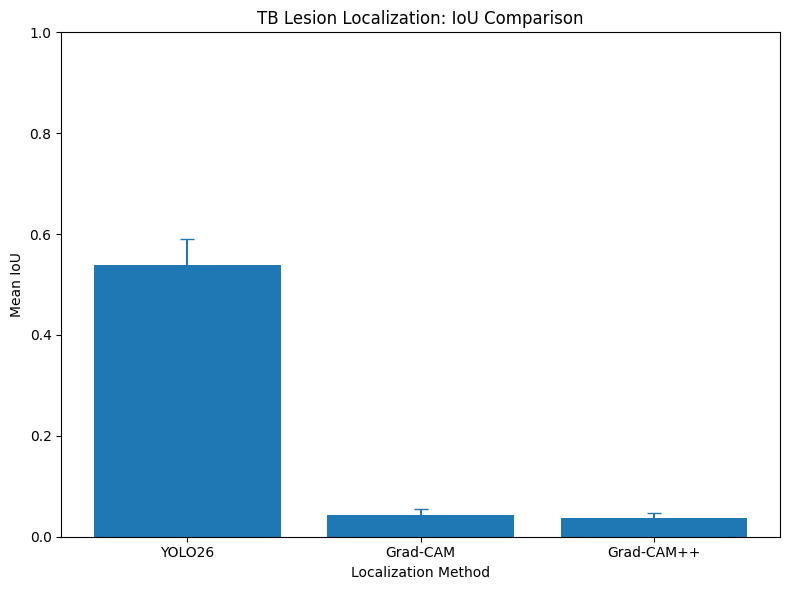

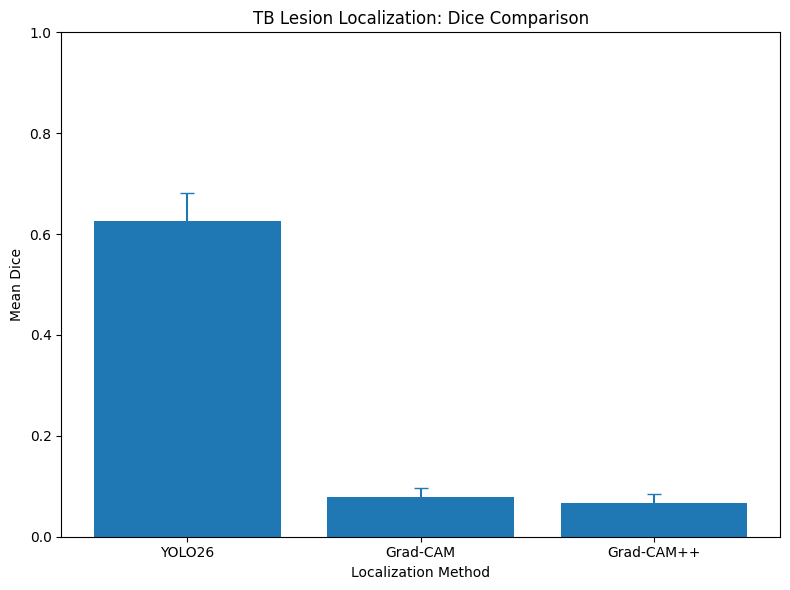

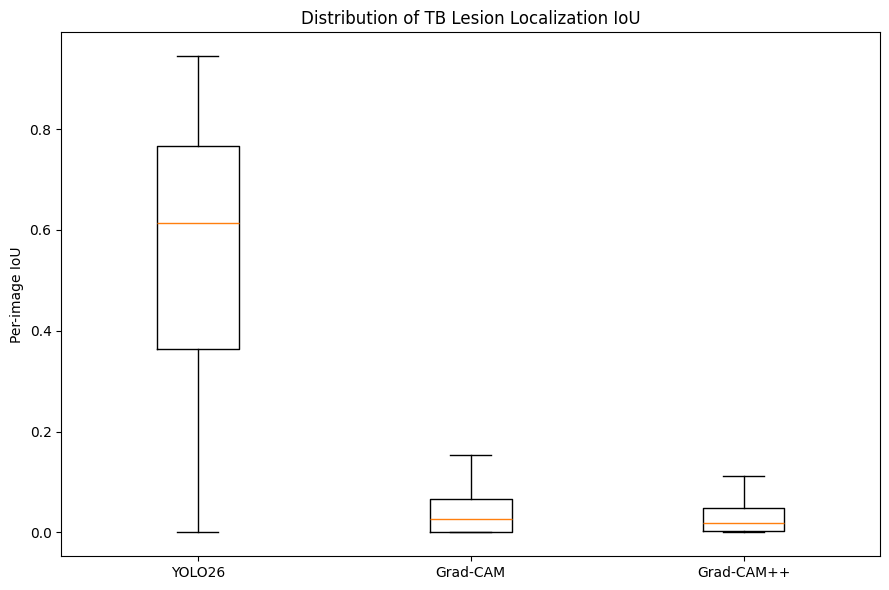


Pointing-game comparison:


,Method,Pointing_Accuracy
0,YOLO26,0.8491
1,Grad-CAM,0.0849
2,Grad-CAM++,0.0472


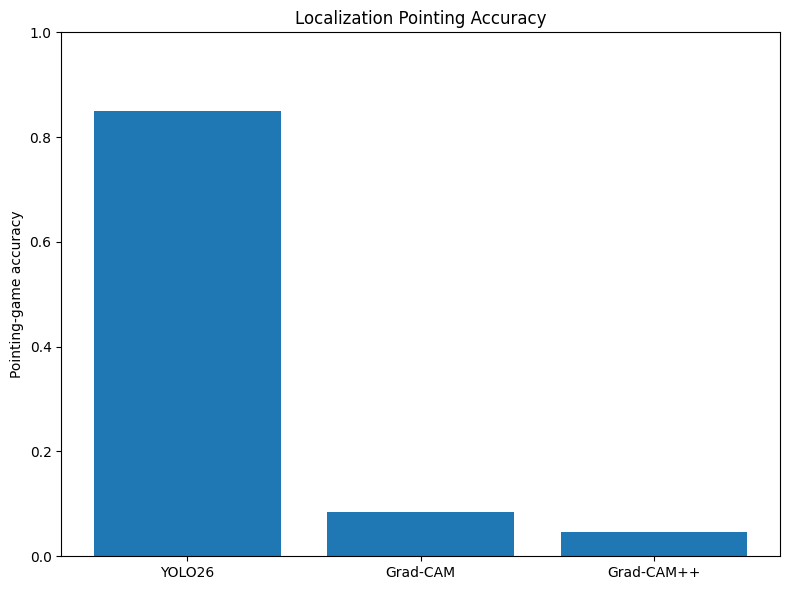


CAM lesion-energy comparison:


,Method,Mean_Lesion_Energy,Median_Lesion_Energy
0,Grad-CAM,0.1187,0.0818
1,Grad-CAM++,0.0949,0.0643



STAGE 12 COMPLETE
Matched test images : 106
YOLO mean IoU       : 0.5386
YOLO mean Dice      : 0.6260
YOLO pointing       : 0.8491
YOLO lesion recall@0.50: 0.6903
Grad-CAM mean IoU   : 0.0436
Grad-CAM++ mean IoU : 0.0370

Outputs:
/kaggle/working/TB_XAI_Stage12_Comparison

NEXT: Stage 13 — subgroup and failure-mode analysis


In [12]:
# =============================================================================
# TB-XAI — STAGE 12
# YOLO26 vs Grad-CAM vs Grad-CAM++ LOCALIZATION COMPARISON
#
# Uses:
#   Stage 11 YOLO test predictions
#   Stage 11 ground-truth bounding boxes
#   Stage 9+10 per-image Grad-CAM / Grad-CAM++ results
#
# Outputs:
#   ✓ Per-image YOLO localization metrics
#   ✓ YOLO vs Grad-CAM vs Grad-CAM++ comparison
#   ✓ IoU
#   ✓ Dice
#   ✓ Pointing-game accuracy
#   ✓ YOLO lesion recall @ IoU >= 0.50
#   ✓ Bootstrap 95% CI
#   ✓ Paired Wilcoxon tests
#   ✓ Publication-ready figures
# =============================================================================


import os
import re
import json
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon

warnings.filterwarnings("ignore")


# =============================================================================
# 1. CONFIGURATION
# =============================================================================

SEED = 42

rng = np.random.default_rng(SEED)

STAGE11_DIR = Path(
    "/kaggle/working/TB_XAI_Stage11_YOLO26"
)

STAGE910_DIR = Path(
    "/kaggle/working/TB_XAI_Stage9_10_XAI"
)

OUTPUT_DIR = Path(
    "/kaggle/working/TB_XAI_Stage12_Comparison"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


YOLO_PRED_PATH = (
    STAGE11_DIR
    / "stage12_yolo_prediction_boxes.csv"
)

YOLO_GT_PATH = (
    STAGE11_DIR
    / "stage12_ground_truth_boxes.csv"
)


if not YOLO_PRED_PATH.exists():

    raise FileNotFoundError(
        f"Missing:\n{YOLO_PRED_PATH}"
    )


if not YOLO_GT_PATH.exists():

    raise FileNotFoundError(
        f"Missing:\n{YOLO_GT_PATH}"
    )


print("=" * 100)
print("TB-XAI — STAGE 12")
print("YOLO26 vs Grad-CAM vs Grad-CAM++ LOCALIZATION")
print("=" * 100)


# =============================================================================
# 2. LOAD YOLO FILES
# =============================================================================

pred_df = pd.read_csv(
    YOLO_PRED_PATH
)

gt_df = pd.read_csv(
    YOLO_GT_PATH
)


print(
    f"YOLO prediction rows : {len(pred_df):,}"
)

print(
    f"Ground-truth boxes   : {len(gt_df):,}"
)


# =============================================================================
# 3. NORMALIZE IMAGE IDENTIFIER
# =============================================================================

def image_key(
    value
):

    value = str(value)

    return (
        Path(value)
        .stem
        .strip()
        .lower()
    )


pred_df[
    "image_key"
] = pred_df[
    "image_name"
].apply(
    image_key
)


gt_df[
    "image_key"
] = gt_df[
    "image_name"
].apply(
    image_key
)


# =============================================================================
# 4. FIX BOOLEAN SELECTED COLUMN
# =============================================================================

if "selected" in pred_df.columns:

    if pred_df[
        "selected"
    ].dtype != bool:

        pred_df[
            "selected"
        ] = (

            pred_df[
                "selected"
            ]
            .astype(str)
            .str.lower()
            .isin(
                [
                    "true",
                    "1",
                    "yes"
                ]
            )

        )

else:

    # Stage 11 selected threshold = 0.40
    pred_df[
        "selected"
    ] = (
        pred_df[
            "confidence"
        ]
        >= 0.40
    )


# =============================================================================
# 5. BOX FUNCTIONS
# =============================================================================

def box_intersection(
    a,
    b
):

    x1 = max(
        a[0],
        b[0]
    )

    y1 = max(
        a[1],
        b[1]
    )

    x2 = min(
        a[2],
        b[2]
    )

    y2 = min(
        a[3],
        b[3]
    )


    width = max(
        0.0,
        x2 - x1
    )

    height = max(
        0.0,
        y2 - y1
    )


    return (
        width
        *
        height
    )


def box_area(
    box
):

    return (

        max(
            0.0,
            box[2] - box[0]
        )

        *

        max(
            0.0,
            box[3] - box[1]
        )

    )


def box_iou(
    a,
    b
):

    intersection = box_intersection(
        a,
        b
    )


    union = (

        box_area(a)
        +
        box_area(b)
        -
        intersection

    )


    if union <= 0:

        return 0.0


    return float(
        intersection
        /
        union
    )


def box_dice(
    a,
    b
):

    intersection = box_intersection(
        a,
        b
    )


    denominator = (

        box_area(a)
        +
        box_area(b)

    )


    if denominator <= 0:

        return 0.0


    return float(

        2
        *
        intersection
        /
        denominator

    )


def point_inside_box(
    x,
    y,
    box
):

    return (

        box[0] <= x <= box[2]

        and

        box[1] <= y <= box[3]

    )


# =============================================================================
# 6. CALCULATE PER-IMAGE YOLO LOCALIZATION
# =============================================================================

all_images = sorted(

    set(
        gt_df[
            "image_key"
        ]
    )

)


yolo_rows = []


for key in all_images:

    current_gt = gt_df[
        gt_df[
            "image_key"
        ]
        ==
        key
    ]


    current_pred = pred_df[

        (
            pred_df[
                "image_key"
            ]
            ==
            key
        )

        &

        (
            pred_df[
                "selected"
            ]
            ==
            True
        )

    ].copy()


    gt_boxes = [

        np.array(
            [
                row.x1,
                row.y1,
                row.x2,
                row.y2
            ],
            dtype=float
        )

        for row
        in current_gt.itertuples()

    ]


    pred_boxes = [

        np.array(
            [
                row.x1,
                row.y1,
                row.x2,
                row.y2
            ],
            dtype=float
        )

        for row
        in current_pred.itertuples()

    ]


    # -----------------------------------------------------------------
    # GT-centered evaluation:
    # for every GT lesion, find best predicted lesion box
    # unmatched GT receives 0
    # -----------------------------------------------------------------

    gt_best_ious = []
    gt_best_dices = []


    for gt_box in gt_boxes:

        if len(
            pred_boxes
        ) == 0:

            gt_best_ious.append(
                0.0
            )

            gt_best_dices.append(
                0.0
            )

            continue


        ious = [

            box_iou(
                gt_box,
                pred_box
            )

            for pred_box
            in pred_boxes

        ]


        best_index = int(
            np.argmax(
                ious
            )
        )


        gt_best_ious.append(
            ious[
                best_index
            ]
        )


        gt_best_dices.append(

            box_dice(

                gt_box,

                pred_boxes[
                    best_index
                ]

            )

        )


    yolo_mean_iou = (

        float(
            np.mean(
                gt_best_ious
            )
        )

        if len(
            gt_best_ious
        ) > 0

        else np.nan

    )


    yolo_mean_dice = (

        float(
            np.mean(
                gt_best_dices
            )
        )

        if len(
            gt_best_dices
        ) > 0

        else np.nan

    )


    lesion_recall_50 = (

        float(
            np.mean(
                np.array(
                    gt_best_ious
                )
                >=
                0.50
            )
        )

        if len(
            gt_best_ious
        ) > 0

        else np.nan

    )


    # -----------------------------------------------------------------
    # Pointing-game equivalent:
    # center of highest-confidence selected YOLO box
    # must lie within at least one GT lesion
    # -----------------------------------------------------------------

    pointing = 0.0


    if len(
        current_pred
    ) > 0:

        best_prediction = (

            current_pred
            .sort_values(
                "confidence",
                ascending=False
            )
            .iloc[
                0
            ]

        )


        center_x = (

            best_prediction[
                "x1"
            ]

            +

            best_prediction[
                "x2"
            ]

        ) / 2


        center_y = (

            best_prediction[
                "y1"
            ]

            +

            best_prediction[
                "y2"
            ]

        ) / 2


        pointing = float(

            any(

                point_inside_box(
                    center_x,
                    center_y,
                    gt_box
                )

                for gt_box
                in gt_boxes

            )

        )


    yolo_rows.append({

        "image_key":
            key,

        "YOLO_IoU":
            yolo_mean_iou,

        "YOLO_Dice":
            yolo_mean_dice,

        "YOLO_Pointing":
            pointing,

        "YOLO_LesionRecall50":
            lesion_recall_50,

        "YOLO_GT_Count":
            len(
                gt_boxes
            ),

        "YOLO_Pred_Count":
            len(
                pred_boxes
            )

    })


yolo_image_df = pd.DataFrame(
    yolo_rows
)


print(
    "\nPer-image YOLO results:"
)

display(
    yolo_image_df.head()
)


yolo_image_df.to_csv(

    OUTPUT_DIR
    /
    "stage12_yolo_per_image.csv",

    index=False

)


# =============================================================================
# 7. AUTO-FIND STAGE 9+10 PER-IMAGE XAI CSV
# =============================================================================

print("\n" + "=" * 100)
print("SEARCHING STAGE 9+10 PER-IMAGE XAI RESULTS")
print("=" * 100)


def normalize_column(
    name
):

    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(name).lower()
    )


def find_matching_column(
    columns,
    possible_names
):

    normalized = {

        normalize_column(
            column
        ):
        column

        for column
        in columns

    }


    for candidate in possible_names:

        key = normalize_column(
            candidate
        )

        if key in normalized:

            return normalized[
                key
            ]


    return None


IMAGE_ALIASES = [

    "image_name",
    "filename",
    "file_name",
    "image",
    "image_path",
    "path"

]


GC_IOU_ALIASES = [

    "GradCAM_IoU",
    "GradCAM IoU",
    "gradcam_iou"

]


GCPP_IOU_ALIASES = [

    "GradCAMPP_IoU",
    "GradCAM++_IoU",
    "GradCAM++ IoU",
    "gradcampp_iou"

]


csv_candidates = []


search_roots = [

    STAGE910_DIR,
    Path("/kaggle/working")

]


seen_paths = set()


for root in search_roots:

    if not root.exists():

        continue


    for csv_path in root.rglob(
        "*.csv"
    ):

        if csv_path in seen_paths:

            continue

        seen_paths.add(
            csv_path
        )


        # Do not accidentally use Stage 11/12 CSV
        path_text = str(
            csv_path
        )


        if (
            "Stage11"
            in path_text
            or
            "Stage12"
            in path_text
        ):

            continue


        try:

            temp = pd.read_csv(
                csv_path,
                nrows=5
            )

        except Exception:

            continue


        image_col = find_matching_column(
            temp.columns,
            IMAGE_ALIASES
        )


        gc_iou_col = find_matching_column(
            temp.columns,
            GC_IOU_ALIASES
        )


        gcpp_iou_col = find_matching_column(
            temp.columns,
            GCPP_IOU_ALIASES
        )


        score = sum(
            x is not None
            for x in [
                image_col,
                gc_iou_col,
                gcpp_iou_col
            ]
        )


        if score >= 3:

            csv_candidates.append(
                (
                    score,
                    csv_path
                )
            )


if len(
    csv_candidates
) == 0:

    raise FileNotFoundError(
        """
Could not locate a Stage 9+10 per-image XAI CSV containing:

    image name
    GradCAM IoU
    GradCAM++ IoU

Your aggregate Stage-9/10 results are not enough for paired Stage-12 analysis.

Please inspect:
/kaggle/working/TB_XAI_Stage9_10_XAI

and use the per-image quantitative XAI CSV.
"""
    )


csv_candidates = sorted(

    csv_candidates,

    key=lambda x:
        (
            -x[0],
            len(
                str(
                    x[1]
                )
            )
        )

)


XAI_CSV = csv_candidates[
    0
][
    1
]


print(
    "✓ XAI per-image CSV:"
)

print(
    XAI_CSV
)


xai_df = pd.read_csv(
    XAI_CSV
)


# =============================================================================
# 8. STANDARDIZE XAI COLUMNS
# =============================================================================

image_col = find_matching_column(
    xai_df.columns,
    IMAGE_ALIASES
)


gc_iou_col = find_matching_column(

    xai_df.columns,

    GC_IOU_ALIASES

)


gcpp_iou_col = find_matching_column(

    xai_df.columns,

    GCPP_IOU_ALIASES

)


gc_dice_col = find_matching_column(

    xai_df.columns,

    [
        "GradCAM_Dice",
        "GradCAM Dice",
        "gradcam_dice"
    ]

)


gcpp_dice_col = find_matching_column(

    xai_df.columns,

    [
        "GradCAMPP_Dice",
        "GradCAM++_Dice",
        "GradCAM++ Dice",
        "gradcampp_dice"
    ]

)


gc_point_col = find_matching_column(

    xai_df.columns,

    [
        "GradCAM_Pointing",
        "GradCAM_PointingGame",
        "GradCAM_Pointing_Accuracy",
        "GradCAM pointing"
    ]

)


gcpp_point_col = find_matching_column(

    xai_df.columns,

    [
        "GradCAMPP_Pointing",
        "GradCAM++_Pointing",
        "GradCAMPP_PointingGame",
        "GradCAM++ pointing"
    ]

)


gc_energy_col = find_matching_column(

    xai_df.columns,

    [
        "GradCAM_Energy",
        "GradCAM_Lesion_Energy",
        "GradCAM_Energy_Fraction"
    ]

)


gcpp_energy_col = find_matching_column(

    xai_df.columns,

    [
        "GradCAMPP_Energy",
        "GradCAM++_Energy",
        "GradCAMPP_Lesion_Energy",
        "GradCAM++ Energy"
    ]

)


rename_map = {

    image_col:
        "image_name",

    gc_iou_col:
        "GradCAM_IoU",

    gcpp_iou_col:
        "GradCAMPP_IoU"

}


if gc_dice_col:

    rename_map[
        gc_dice_col
    ] = "GradCAM_Dice"


if gcpp_dice_col:

    rename_map[
        gcpp_dice_col
    ] = "GradCAMPP_Dice"


if gc_point_col:

    rename_map[
        gc_point_col
    ] = "GradCAM_Pointing"


if gcpp_point_col:

    rename_map[
        gcpp_point_col
    ] = "GradCAMPP_Pointing"


if gc_energy_col:

    rename_map[
        gc_energy_col
    ] = "GradCAM_Energy"


if gcpp_energy_col:

    rename_map[
        gcpp_energy_col
    ] = "GradCAMPP_Energy"


xai_df = xai_df.rename(
    columns=rename_map
)


xai_df[
    "image_key"
] = xai_df[
    "image_name"
].apply(
    image_key
)


# =============================================================================
# 9. MERGE SAME TEST IMAGES
# =============================================================================

comparison_df = pd.merge(

    yolo_image_df,

    xai_df,

    on="image_key",

    how="inner",

    suffixes=(
        "",
        "_XAI"
    )

)


print(
    f"\nMatched test images: "
    f"{len(comparison_df):,}"
)


if len(
    comparison_df
) == 0:

    raise RuntimeError(
        "No images matched between YOLO and XAI results."
    )


# =============================================================================
# 10. COMPUTE DICE FROM IoU IF ORIGINAL STAGE 10 CSV DOES NOT CONTAIN IT
# =============================================================================

# Dice = 2*IoU / (1+IoU)
# This is valid when both metrics refer to the same binary regions.

if "GradCAM_Dice" not in comparison_df.columns:

    comparison_df[
        "GradCAM_Dice"
    ] = (

        2
        *
        comparison_df[
            "GradCAM_IoU"
        ]

        /

        (
            1
            +
            comparison_df[
                "GradCAM_IoU"
            ]
        )

    )


if "GradCAMPP_Dice" not in comparison_df.columns:

    comparison_df[
        "GradCAMPP_Dice"
    ] = (

        2
        *
        comparison_df[
            "GradCAMPP_IoU"
        ]

        /

        (
            1
            +
            comparison_df[
                "GradCAMPP_IoU"
            ]
        )

    )


comparison_df.to_csv(

    OUTPUT_DIR
    /
    "stage12_per_image_comparison.csv",

    index=False

)


# =============================================================================
# 11. BOOTSTRAP CONFIDENCE INTERVAL
# =============================================================================

def bootstrap_mean_ci(
    values,
    n_bootstrap=5000
):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(
            values
        )
    ]


    if len(
        values
    ) == 0:

        return (
            np.nan,
            np.nan,
            np.nan
        )


    boot_means = np.empty(
        n_bootstrap
    )


    for i in range(
        n_bootstrap
    ):

        sample = rng.choice(

            values,

            size=len(
                values
            ),

            replace=True

        )

        boot_means[
            i
        ] = np.mean(
            sample
        )


    return (

        float(
            np.mean(
                values
            )
        ),

        float(
            np.percentile(
                boot_means,
                2.5
            )
        ),

        float(
            np.percentile(
                boot_means,
                97.5
            )
        )

    )


# =============================================================================
# 12. MAIN QUANTITATIVE SUMMARY
# =============================================================================

summary_rows = []


metric_mapping = {

    "YOLO26": {

        "IoU":
            "YOLO_IoU",

        "Dice":
            "YOLO_Dice",

        "Pointing":
            "YOLO_Pointing"

    },

    "Grad-CAM": {

        "IoU":
            "GradCAM_IoU",

        "Dice":
            "GradCAM_Dice",

        "Pointing":
            "GradCAM_Pointing"

    },

    "Grad-CAM++": {

        "IoU":
            "GradCAMPP_IoU",

        "Dice":
            "GradCAMPP_Dice",

        "Pointing":
            "GradCAMPP_Pointing"

    }

}


for method, metrics in metric_mapping.items():

    for metric_name, column_name in metrics.items():

        if column_name not in comparison_df.columns:

            continue


        mean_value, lower_ci, upper_ci = bootstrap_mean_ci(

            comparison_df[
                column_name
            ].values

        )


        summary_rows.append({

            "Method":
                method,

            "Metric":
                metric_name,

            "N":
                int(
                    comparison_df[
                        column_name
                    ]
                    .notna()
                    .sum()
                ),

            "Mean":
                mean_value,

            "Median":
                float(
                    comparison_df[
                        column_name
                    ]
                    .median()
                ),

            "SD":
                float(
                    comparison_df[
                        column_name
                    ]
                    .std()
                ),

            "CI95_Lower":
                lower_ci,

            "CI95_Upper":
                upper_ci

        })


summary_df = pd.DataFrame(
    summary_rows
)


print("\n" + "=" * 100)
print("STAGE 12 QUANTITATIVE LOCALIZATION COMPARISON")
print("=" * 100)


display(
    summary_df.round(
        4
    )
)


summary_df.to_csv(

    OUTPUT_DIR
    /
    "stage12_localization_summary.csv",

    index=False

)


# =============================================================================
# 13. YOLO LESION RECALL
# =============================================================================

print(
    "\nYOLO lesion localization recall @ IoU >= 0.50:"
)

print(

    round(

        comparison_df[
            "YOLO_LesionRecall50"
        ].mean(),

        4

    )

)


# =============================================================================
# 14. PAIRED STATISTICAL TESTS
# =============================================================================

def safe_wilcoxon(
    x,
    y
):

    paired = pd.DataFrame({

        "x":
            x,

        "y":
            y

    }).dropna()


    if len(
        paired
    ) < 3:

        return (
            np.nan,
            np.nan,
            len(
                paired
            )
        )


    difference = (

        paired[
            "x"
        ]

        -

        paired[
            "y"
        ]

    )


    if np.allclose(
        difference,
        0
    ):

        return (
            0.0,
            1.0,
            len(
                paired
            )
        )


    result = wilcoxon(

        paired[
            "x"
        ],

        paired[
            "y"
        ],

        zero_method="wilcox",

        alternative="two-sided"

    )


    return (

        float(
            result.statistic
        ),

        float(
            result.pvalue
        ),

        len(
            paired
        )

    )


test_rows = []


comparisons = [

    (
        "YOLO26",
        "Grad-CAM",
        "YOLO_IoU",
        "GradCAM_IoU",
        "IoU"
    ),

    (
        "YOLO26",
        "Grad-CAM++",
        "YOLO_IoU",
        "GradCAMPP_IoU",
        "IoU"
    ),

    (
        "Grad-CAM",
        "Grad-CAM++",
        "GradCAM_IoU",
        "GradCAMPP_IoU",
        "IoU"
    ),

    (
        "YOLO26",
        "Grad-CAM",
        "YOLO_Dice",
        "GradCAM_Dice",
        "Dice"
    ),

    (
        "YOLO26",
        "Grad-CAM++",
        "YOLO_Dice",
        "GradCAMPP_Dice",
        "Dice"
    ),

    (
        "Grad-CAM",
        "Grad-CAM++",
        "GradCAM_Dice",
        "GradCAMPP_Dice",
        "Dice"
    )

]


for (

    method1,
    method2,
    column1,
    column2,
    metric

) in comparisons:

    statistic, p_value, n = safe_wilcoxon(

        comparison_df[
            column1
        ],

        comparison_df[
            column2
        ]

    )


    test_rows.append({

        "Metric":
            metric,

        "Method_1":
            method1,

        "Method_2":
            method2,

        "N":
            n,

        "Wilcoxon_Statistic":
            statistic,

        "P_Value":
            p_value

    })


paired_tests_df = pd.DataFrame(
    test_rows
)


print(
    "\nPaired Wilcoxon tests:"
)


display(
    paired_tests_df
)


paired_tests_df.to_csv(

    OUTPUT_DIR
    /
    "stage12_paired_wilcoxon.csv",

    index=False

)


# =============================================================================
# 15. FIGURE — MEAN IoU
# =============================================================================

iou_summary = summary_df[

    summary_df[
        "Metric"
    ]
    ==
    "IoU"

].copy()


plt.figure(
    figsize=(
        8,
        6
    )
)


x = np.arange(
    len(
        iou_summary
    )
)


means = iou_summary[
    "Mean"
].values


lower_errors = (

    means

    -

    iou_summary[
        "CI95_Lower"
    ].values

)


upper_errors = (

    iou_summary[
        "CI95_Upper"
    ].values

    -

    means

)


plt.bar(
    x,
    means
)


plt.errorbar(

    x,
    means,

    yerr=np.vstack(
        [
            lower_errors,
            upper_errors
        ]
    ),

    fmt="none",

    capsize=5

)


plt.xticks(

    x,

    iou_summary[
        "Method"
    ]

)


plt.ylabel(
    "Mean IoU"
)


plt.xlabel(
    "Localization Method"
)


plt.title(
    "TB Lesion Localization: IoU Comparison"
)


plt.ylim(
    0,
    max(
        1.0,
        means.max()
        +
        0.1
    )
)


plt.tight_layout()


plt.savefig(

    OUTPUT_DIR
    /
    "stage12_iou_comparison.png",

    dpi=300,
    bbox_inches="tight"

)


plt.show()


# =============================================================================
# 16. FIGURE — MEAN DICE
# =============================================================================

dice_summary = summary_df[

    summary_df[
        "Metric"
    ]
    ==
    "Dice"

].copy()


plt.figure(
    figsize=(
        8,
        6
    )
)


x = np.arange(
    len(
        dice_summary
    )
)


means = dice_summary[
    "Mean"
].values


lower_errors = (

    means
    -
    dice_summary[
        "CI95_Lower"
    ].values

)


upper_errors = (

    dice_summary[
        "CI95_Upper"
    ].values

    -
    means

)


plt.bar(
    x,
    means
)


plt.errorbar(

    x,
    means,

    yerr=np.vstack(
        [
            lower_errors,
            upper_errors
        ]
    ),

    fmt="none",

    capsize=5

)


plt.xticks(

    x,

    dice_summary[
        "Method"
    ]

)


plt.ylabel(
    "Mean Dice"
)


plt.xlabel(
    "Localization Method"
)


plt.title(
    "TB Lesion Localization: Dice Comparison"
)


plt.ylim(
    0,
    max(
        1.0,
        means.max()
        +
        0.1
    )
)


plt.tight_layout()


plt.savefig(

    OUTPUT_DIR
    /
    "stage12_dice_comparison.png",

    dpi=300,
    bbox_inches="tight"

)


plt.show()


# =============================================================================
# 17. FIGURE — PER-IMAGE IoU DISTRIBUTION
# =============================================================================

plot_data = [

    comparison_df[
        "YOLO_IoU"
    ].dropna(),

    comparison_df[
        "GradCAM_IoU"
    ].dropna(),

    comparison_df[
        "GradCAMPP_IoU"
    ].dropna()

]


plt.figure(
    figsize=(
        9,
        6
    )
)


plt.boxplot(

    plot_data,

    labels=[
        "YOLO26",
        "Grad-CAM",
        "Grad-CAM++"
    ],

    showfliers=False

)


plt.ylabel(
    "Per-image IoU"
)


plt.title(
    "Distribution of TB Lesion Localization IoU"
)


plt.tight_layout()


plt.savefig(

    OUTPUT_DIR
    /
    "stage12_iou_boxplot.png",

    dpi=300,
    bbox_inches="tight"

)


plt.show()


# =============================================================================
# 18. POINTING ACCURACY
# =============================================================================

point_columns = {

    "YOLO26":
        "YOLO_Pointing",

    "Grad-CAM":
        "GradCAM_Pointing",

    "Grad-CAM++":
        "GradCAMPP_Pointing"

}


point_rows = []


for method, column in point_columns.items():

    if column not in comparison_df.columns:

        continue


    point_rows.append({

        "Method":
            method,

        "Pointing_Accuracy":
            comparison_df[
                column
            ].mean()

    })


pointing_df = pd.DataFrame(
    point_rows
)


if len(
    pointing_df
) > 0:

    print(
        "\nPointing-game comparison:"
    )

    display(
        pointing_df.round(
            4
        )
    )


    pointing_df.to_csv(

        OUTPUT_DIR
        /
        "stage12_pointing_accuracy.csv",

        index=False

    )


    plt.figure(
        figsize=(
            8,
            6
        )
    )


    plt.bar(

        pointing_df[
            "Method"
        ],

        pointing_df[
            "Pointing_Accuracy"
        ]

    )


    plt.ylabel(
        "Pointing-game accuracy"
    )


    plt.ylim(
        0,
        1
    )


    plt.title(
        "Localization Pointing Accuracy"
    )


    plt.tight_layout()


    plt.savefig(

        OUTPUT_DIR
        /
        "stage12_pointing_accuracy.png",

        dpi=300,
        bbox_inches="tight"

    )


    plt.show()


# =============================================================================
# 19. OPTIONAL CAM ENERGY SUMMARY
# =============================================================================

energy_rows = []


for method, column in [

    (
        "Grad-CAM",
        "GradCAM_Energy"
    ),

    (
        "Grad-CAM++",
        "GradCAMPP_Energy"
    )

]:

    if column in comparison_df.columns:

        energy_rows.append({

            "Method":
                method,

            "Mean_Lesion_Energy":
                comparison_df[
                    column
                ].mean(),

            "Median_Lesion_Energy":
                comparison_df[
                    column
                ].median()

        })


energy_df = pd.DataFrame(
    energy_rows
)


if len(
    energy_df
) > 0:

    print(
        "\nCAM lesion-energy comparison:"
    )

    display(
        energy_df.round(
            4
        )
    )


    energy_df.to_csv(

        OUTPUT_DIR
        /
        "stage12_cam_energy.csv",

        index=False

    )


# =============================================================================
# 20. BEST / WORST CASES
# =============================================================================

for metric in [

    "YOLO_IoU",
    "GradCAM_IoU",
    "GradCAMPP_IoU"

]:

    if metric not in comparison_df.columns:

        continue


    comparison_df[
        [
            "image_key",
            metric
        ]
    ].sort_values(

        metric,
        ascending=True

    ).head(
        20
    ).to_csv(

        OUTPUT_DIR
        /
        f"worst20_{metric}.csv",

        index=False

    )


# =============================================================================
# 21. FINAL SUMMARY
# =============================================================================

print("\n" + "=" * 100)
print("STAGE 12 COMPLETE")
print("=" * 100)


print(
    f"Matched test images : "
    f"{len(comparison_df)}"
)


print(
    f"YOLO mean IoU       : "
    f"{comparison_df['YOLO_IoU'].mean():.4f}"
)


print(
    f"YOLO mean Dice      : "
    f"{comparison_df['YOLO_Dice'].mean():.4f}"
)


print(
    f"YOLO pointing       : "
    f"{comparison_df['YOLO_Pointing'].mean():.4f}"
)


print(
    f"YOLO lesion recall@0.50: "
    f"{comparison_df['YOLO_LesionRecall50'].mean():.4f}"
)


print(
    f"Grad-CAM mean IoU   : "
    f"{comparison_df['GradCAM_IoU'].mean():.4f}"
)


print(
    f"Grad-CAM++ mean IoU : "
    f"{comparison_df['GradCAMPP_IoU'].mean():.4f}"
)


print(
    "\nOutputs:"
)

print(
    OUTPUT_DIR
)


print(
    "\nNEXT: Stage 13 — subgroup and failure-mode analysis"
)

TB-XAI — STAGE 13
FAILURE-MODE AND SUBGROUP ANALYSIS
Stage-12 matched images : 106
Ground-truth boxes      : 163
Test images located      : 106
Final Stage-13 images   : 106

SUBGROUP LOCALIZATION SUMMARY


,Subgroup_Variable,Subgroup,Method,N,Mean_IoU,Median_IoU,SD,Q1,Q3
0,lesion_count_group,1 lesion,YOLO26,53,0.5903,0.6812,0.2942,0.5037,0.8094
1,lesion_count_group,1 lesion,Grad-CAM,53,0.0391,0.0018,0.0595,0.0000,0.0506
2,lesion_count_group,1 lesion,Grad-CAM++,53,0.0200,0.0078,0.0295,0.0000,0.0234
3,lesion_count_group,2 lesions,YOLO26,49,0.5006,0.5400,0.2489,0.3158,0.6952
4,lesion_count_group,2 lesions,Grad-CAM,49,0.0442,0.0306,0.0459,0.0006,0.0630
5,lesion_count_group,2 lesions,Grad-CAM++,49,0.0521,0.0348,0.0577,0.0080,0.0748
6,lesion_count_group,3+ lesions,YOLO26,4,0.3196,0.3799,0.2389,0.2057,0.4938
7,lesion_count_group,3+ lesions,Grad-CAM,4,0.0958,0.1003,0.0456,0.0629,0.1331
8,lesion_count_group,3+ lesions,Grad-CAM++,4,0.0760,0.0529,0.0685,0.0304,0.0985
9,lesion_size_group,Large,YOLO26,36,0.6486,0.6741,0.1904,0.5412,0.8142



KRUSKAL-WALLIS SUBGROUP TESTS


,Subgroup_Variable,Method,N,Groups,Kruskal_H,P_Value,Epsilon_Squared,FDR_P_Value,FDR_Significant
0,lesion_count_group,YOLO26,106,3,7.97553,0.01854,0.05801,0.06383,False
1,lesion_count_group,Grad-CAM,106,3,7.62464,0.02210,0.05461,0.06383,False
2,lesion_count_group,Grad-CAM++,106,3,17.19793,0.00018,0.14755,0.00332,True
3,lesion_size_group,YOLO26,106,3,14.48925,0.00071,0.12125,0.00643,True
4,lesion_size_group,Grad-CAM,106,3,9.23627,0.00987,0.07026,0.05923,False
5,lesion_size_group,Grad-CAM++,106,3,3.11879,0.21026,0.01086,0.34407,False
6,brightness_group,YOLO26,106,3,0.76524,0.68207,0.00000,0.72219,False
7,brightness_group,Grad-CAM,106,3,7.39208,0.02482,0.05235,0.06383,False
8,brightness_group,Grad-CAM++,106,3,0.87739,0.64488,0.00000,0.72219,False
9,contrast_group,YOLO26,106,3,1.07264,0.58490,0.00000,0.72219,False



SPEARMAN CORRELATION ANALYSIS


,Variable,Method,N,Spearman_Rho,P_Value,FDR_P_Value,FDR_Significant
0,lesion_count,YOLO26,106,-0.26422,0.00620,0.02605,True
1,lesion_count,Grad-CAM,106,0.23319,0.01615,0.04272,True
2,lesion_count,Grad-CAM++,106,0.40426,0.00002,0.00018,True
3,mean_lesion_area_fraction,YOLO26,106,0.43944,0.00000,0.00005,True
4,mean_lesion_area_fraction,Grad-CAM,106,0.25175,0.00924,0.03232,True
5,mean_lesion_area_fraction,Grad-CAM++,106,0.17176,0.07832,0.14953,False
6,total_lesion_area_fraction,YOLO26,106,0.19369,0.04666,0.09873,False
7,total_lesion_area_fraction,Grad-CAM,106,0.32934,0.00057,0.00297,True
8,total_lesion_area_fraction,Grad-CAM++,106,0.34382,0.00031,0.00216,True
9,brightness,YOLO26,106,-0.00921,0.92532,0.92532,False



FAILURE SUMMARY


,Failure_Type,N,Percentage
0,YOLO IoU < 0.50,40,37.74
1,YOLO complete miss,13,12.26
2,Grad-CAM zero overlap,35,33.02
3,Grad-CAM++ zero overlap,23,21.70



✓ Classification outcome column found: correct


,Classification_Outcome,Method,N,Mean_IoU,Median_IoU
0,False,YOLO26,53,0.5244,0.6326
1,False,Grad-CAM,53,0.0430,0.0336
2,False,Grad-CAM++,53,0.0353,0.0150
3,True,YOLO26,53,0.5529,0.5793
4,True,Grad-CAM,53,0.0441,0.0197
5,True,Grad-CAM++,53,0.0386,0.0234


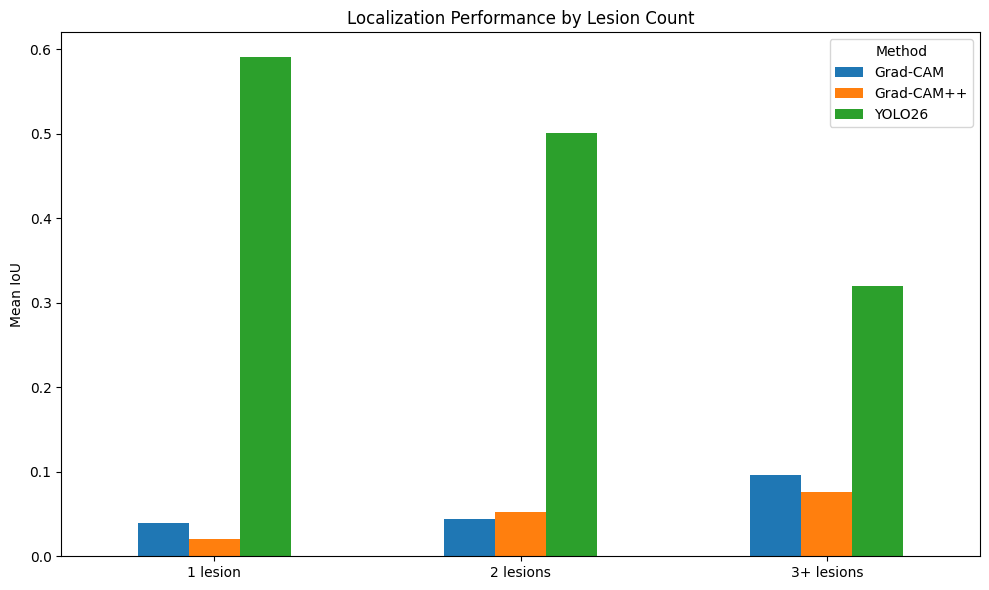

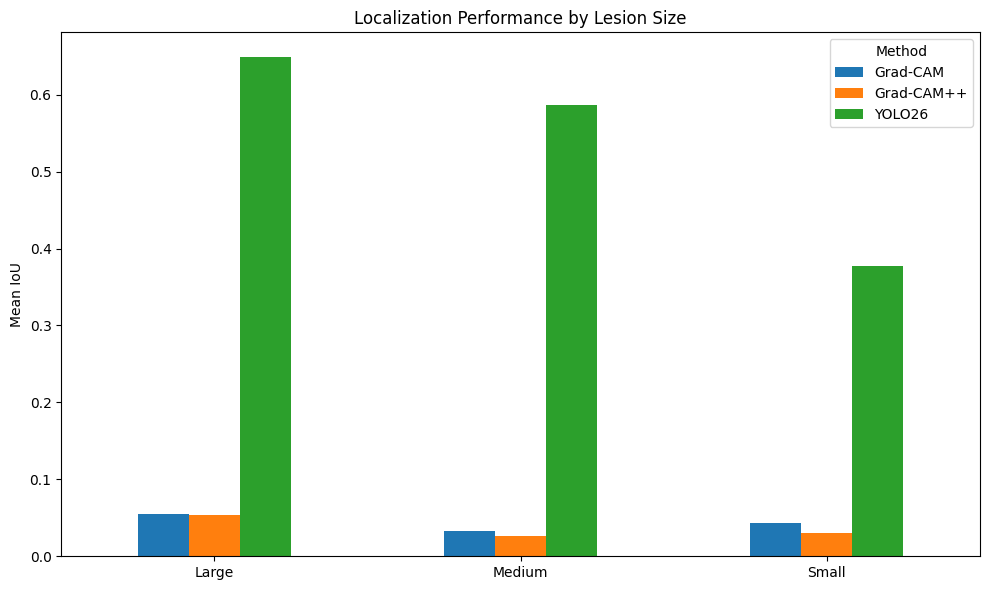

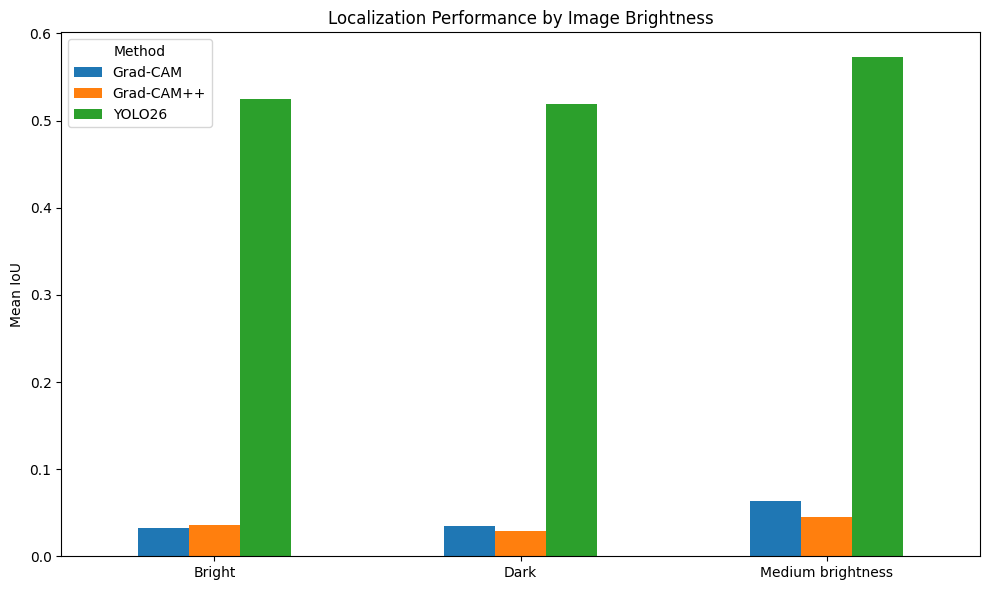

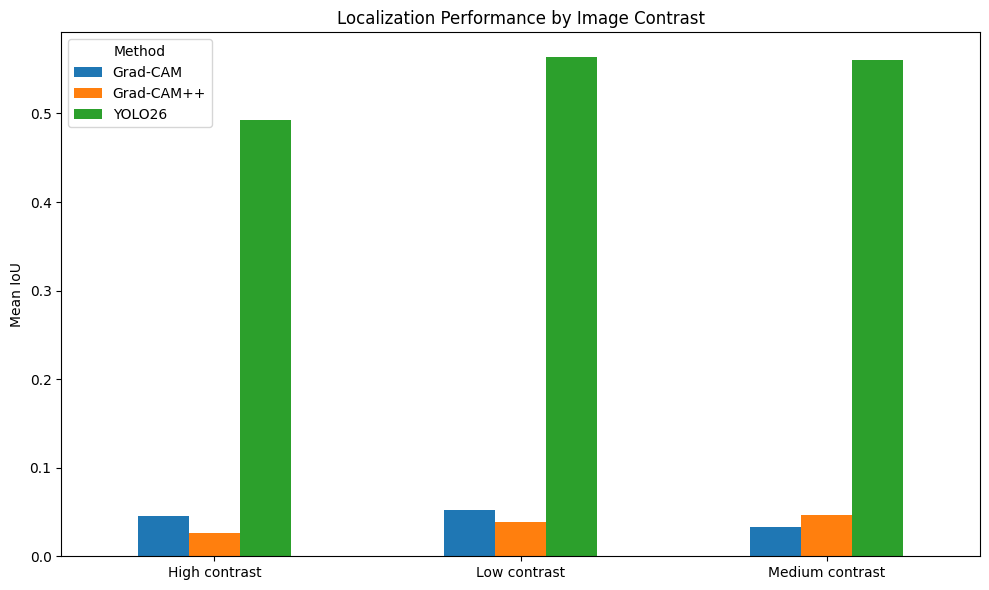

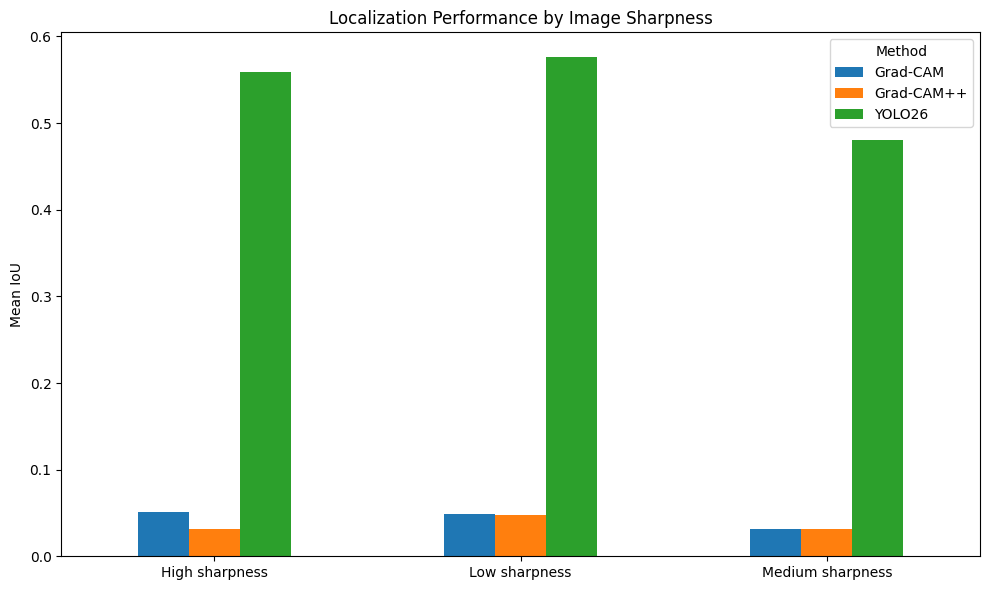

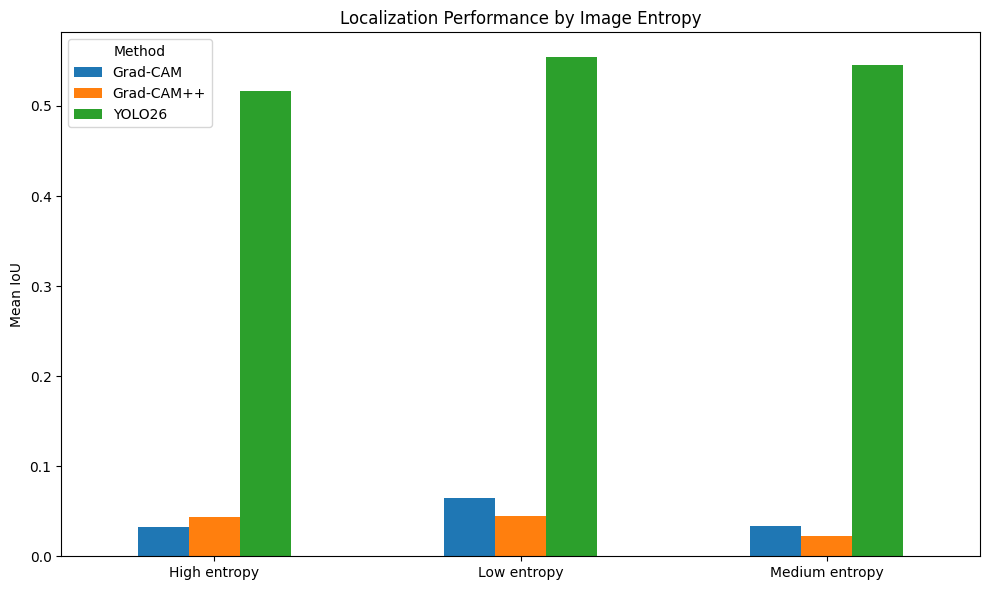

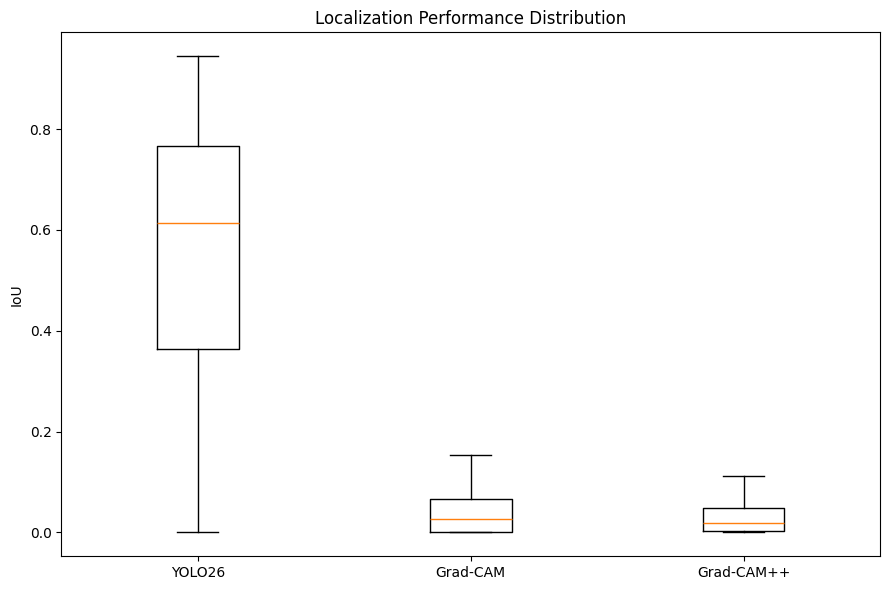


STAGE 13 COMPLETE


,Metric,Value
0,Images analysed,106.0000
1,Mean lesion count,1.5377
2,Median lesion count,1.5000
3,Mean lesion area fraction,0.0638
4,YOLO mean IoU,0.5386
5,YOLO median IoU,0.6132
6,Grad-CAM mean IoU,0.0436
7,Grad-CAM++ mean IoU,0.0370
8,YOLO IoU < 0.50 (%),37.7358
9,YOLO complete miss (%),12.2642



Completed:
✓ Lesion-size analysis
✓ Lesion-count analysis
✓ Brightness analysis
✓ Contrast analysis
✓ Sharpness analysis
✓ Entropy analysis
✓ Kruskal-Wallis testing
✓ Effect-size calculation
✓ FDR multiple-testing correction
✓ Spearman correlation analysis
✓ YOLO26 failure analysis
✓ Grad-CAM failure analysis
✓ Grad-CAM++ failure analysis
✓ Worst-case images exported

Outputs:
/kaggle/working/TB_XAI_Stage13_FailureAnalysis

NEXT: Stage 14 — Final Streamlit TB-XAI application


In [13]:
# =============================================================================
# TB-XAI — STAGE 13
# FINAL FAILURE-MODE + SUBGROUP ANALYSIS
#
# Input:
#   /kaggle/working/TB_XAI_Stage12_Comparison/
#       stage12_per_image_comparison.csv
#
#   /kaggle/working/TB_XAI_Stage11_YOLO26/
#       stage12_ground_truth_boxes.csv
#
# Analyses:
#   ✓ Lesion size
#   ✓ Lesion count
#   ✓ Brightness
#   ✓ Contrast
#   ✓ Sharpness
#   ✓ Entropy
#   ✓ YOLO26 / Grad-CAM / Grad-CAM++ subgroup performance
#   ✓ Kruskal-Wallis tests
#   ✓ Effect size
#   ✓ Benjamini-Hochberg multiple-testing correction
#   ✓ Spearman correlations
#   ✓ Classification failure analysis if Stage-10 columns exist
#   ✓ Worst-case export
#   ✓ Publication-ready plots
# =============================================================================


# =============================================================================
# 0. IMPORTS
# =============================================================================

import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    kruskal,
    spearmanr
)

from IPython.display import display


warnings.filterwarnings(
    "ignore"
)


# =============================================================================
# 1. PATHS
# =============================================================================

STAGE12_DIR = Path(
    "/kaggle/working/TB_XAI_Stage12_Comparison"
)

STAGE11_DIR = Path(
    "/kaggle/working/TB_XAI_Stage11_YOLO26"
)

CLEAN_ROOT = Path(
    "/kaggle/working/TB_XAI_CleanSplit"
)

TEST_IMAGE_DIR = (
    CLEAN_ROOT
    /
    "images"
    /
    "test"
)

OUTPUT_DIR = Path(
    "/kaggle/working/TB_XAI_Stage13_FailureAnalysis"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


COMPARISON_PATH = (
    STAGE12_DIR
    /
    "stage12_per_image_comparison.csv"
)

GT_PATH = (
    STAGE11_DIR
    /
    "stage12_ground_truth_boxes.csv"
)


if not COMPARISON_PATH.exists():

    raise FileNotFoundError(
        f"Stage-12 comparison file not found:\n{COMPARISON_PATH}"
    )


if not GT_PATH.exists():

    raise FileNotFoundError(
        f"Ground-truth file not found:\n{GT_PATH}"
    )


if not TEST_IMAGE_DIR.exists():

    raise FileNotFoundError(
        f"Test image directory not found:\n{TEST_IMAGE_DIR}"
    )


print("=" * 100)
print("TB-XAI — STAGE 13")
print("FAILURE-MODE AND SUBGROUP ANALYSIS")
print("=" * 100)


# =============================================================================
# 2. LOAD DATA
# =============================================================================

comparison_df = pd.read_csv(
    COMPARISON_PATH
)

gt_df = pd.read_csv(
    GT_PATH
)


print(
    f"Stage-12 matched images : {len(comparison_df):,}"
)

print(
    f"Ground-truth boxes      : {len(gt_df):,}"
)


# =============================================================================
# 3. IMAGE KEY
# =============================================================================

def image_key(
    value
):

    return (
        Path(
            str(
                value
            )
        )
        .stem
        .strip()
        .lower()
    )


if "image_key" not in comparison_df.columns:

    possible_image_columns = [

        "image_name",
        "filename",
        "file_name",
        "image",
        "image_path"

    ]

    image_column = None

    for column in possible_image_columns:

        if column in comparison_df.columns:

            image_column = column
            break


    if image_column is None:

        raise RuntimeError(
            "No image identifier column found in Stage-12 comparison file."
        )


    comparison_df[
        "image_key"
    ] = comparison_df[
        image_column
    ].apply(
        image_key
    )


gt_df[
    "image_key"
] = gt_df[
    "image_name"
].apply(
    image_key
)


# =============================================================================
# 4. TEST IMAGE LOOKUP
# =============================================================================

IMAGE_EXTENSIONS = {

    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"

}


image_lookup = {}


for image_path in TEST_IMAGE_DIR.rglob(
    "*"
):

    if (
        image_path.is_file()
        and
        image_path.suffix.lower()
        in IMAGE_EXTENSIONS
    ):

        image_lookup[
            image_key(
                image_path.name
            )
        ] = image_path


print(
    f"Test images located      : {len(image_lookup):,}"
)


# =============================================================================
# 5. IMAGE ENTROPY
# =============================================================================

def calculate_entropy(
    gray_image
):

    histogram = cv2.calcHist(

        [
            gray_image
        ],

        [
            0
        ],

        None,

        [
            256
        ],

        [
            0,
            256
        ]

    ).flatten()


    probability = (

        histogram

        /

        (
            histogram.sum()
            +
            1e-12
        )

    )


    probability = probability[
        probability > 0
    ]


    entropy = -np.sum(

        probability
        *
        np.log2(
            probability
        )

    )


    return float(
        entropy
    )


# =============================================================================
# 6. EXTRACT LESION + IMAGE QUALITY FEATURES
# =============================================================================

feature_rows = []


for key in comparison_df[
    "image_key"
].dropna().unique():

    image_path = image_lookup.get(
        key
    )


    if image_path is None:

        continue


    gray = cv2.imread(

        str(
            image_path
        ),

        cv2.IMREAD_GRAYSCALE

    )


    if gray is None:

        continue


    height, width = gray.shape[:2]


    current_gt = gt_df[

        gt_df[
            "image_key"
        ]
        ==
        key

    ]


    lesion_area_fractions = []


    for row in current_gt.itertuples():

        box_width = max(

            0.0,

            float(
                row.x2
            )
            -
            float(
                row.x1
            )

        )


        box_height = max(

            0.0,

            float(
                row.y2
            )
            -
            float(
                row.y1
            )

        )


        lesion_area_pixels = (

            box_width
            *
            box_height

        )


        lesion_area_fraction = (

            lesion_area_pixels

            /

            float(
                width
                *
                height
            )

        )


        lesion_area_fractions.append(
            lesion_area_fraction
        )


    brightness = float(
        np.mean(
            gray
        )
    )


    contrast = float(
        np.std(
            gray
        )
    )


    sharpness = float(

        cv2.Laplacian(

            gray,

            cv2.CV_64F

        ).var()

    )


    entropy = calculate_entropy(
        gray
    )


    feature_rows.append({

        "image_key":
            key,

        "image_path":
            str(
                image_path
            ),

        "image_width":
            int(
                width
            ),

        "image_height":
            int(
                height
            ),

        "lesion_count":
            int(
                len(
                    lesion_area_fractions
                )
            ),

        "mean_lesion_area_fraction":
            (
                float(
                    np.mean(
                        lesion_area_fractions
                    )
                )

                if lesion_area_fractions

                else np.nan
            ),

        "max_lesion_area_fraction":
            (
                float(
                    np.max(
                        lesion_area_fractions
                    )
                )

                if lesion_area_fractions

                else np.nan
            ),

        "total_lesion_area_fraction":
            (
                float(
                    np.sum(
                        lesion_area_fractions
                    )
                )

                if lesion_area_fractions

                else np.nan
            ),

        "brightness":
            brightness,

        "contrast":
            contrast,

        "sharpness":
            sharpness,

        "entropy":
            entropy

    })


feature_df = pd.DataFrame(
    feature_rows
)


# =============================================================================
# 7. MERGE STAGE 12 + IMAGE FEATURES
# =============================================================================

analysis_df = comparison_df.merge(

    feature_df,

    on="image_key",

    how="inner"

)


print(
    f"Final Stage-13 images   : {len(analysis_df):,}"
)


if len(
    analysis_df
) == 0:

    raise RuntimeError(
        "No matched images available for Stage 13."
    )


# =============================================================================
# 8. LESION COUNT GROUP
# =============================================================================

def lesion_count_category(
    value
):

    if value <= 0:

        return "0 lesion"

    elif value == 1:

        return "1 lesion"

    elif value == 2:

        return "2 lesions"

    else:

        return "3+ lesions"


analysis_df[
    "lesion_count_group"
] = analysis_df[
    "lesion_count"
].apply(
    lesion_count_category
)


# =============================================================================
# 9. SAFE TERTILE FUNCTION
# =============================================================================

def safe_tertiles(
    series,
    labels
):

    result = pd.Series(

        index=series.index,

        dtype="object"

    )


    valid = series.dropna()


    if len(
        valid
    ) < 3:

        return result


    ranked = valid.rank(
        method="first"
    )


    categories = pd.qcut(

        ranked,

        q=3,

        labels=labels

    )


    result.loc[
        valid.index
    ] = categories.astype(
        str
    )


    return result


# =============================================================================
# 10. SUBGROUP VARIABLES
# =============================================================================

analysis_df[
    "lesion_size_group"
] = safe_tertiles(

    analysis_df[
        "mean_lesion_area_fraction"
    ],

    [
        "Small",
        "Medium",
        "Large"
    ]

)


analysis_df[
    "brightness_group"
] = safe_tertiles(

    analysis_df[
        "brightness"
    ],

    [
        "Dark",
        "Medium brightness",
        "Bright"
    ]

)


analysis_df[
    "contrast_group"
] = safe_tertiles(

    analysis_df[
        "contrast"
    ],

    [
        "Low contrast",
        "Medium contrast",
        "High contrast"
    ]

)


analysis_df[
    "sharpness_group"
] = safe_tertiles(

    analysis_df[
        "sharpness"
    ],

    [
        "Low sharpness",
        "Medium sharpness",
        "High sharpness"
    ]

)


analysis_df[
    "entropy_group"
] = safe_tertiles(

    analysis_df[
        "entropy"
    ],

    [
        "Low entropy",
        "Medium entropy",
        "High entropy"
    ]

)


# =============================================================================
# 11. DEFINE LOCALIZATION METHODS
# =============================================================================

METHOD_COLUMNS = {

    "YOLO26":
        "YOLO_IoU",

    "Grad-CAM":
        "GradCAM_IoU",

    "Grad-CAM++":
        "GradCAMPP_IoU"

}


for method, column in METHOD_COLUMNS.items():

    if column not in analysis_df.columns:

        raise RuntimeError(
            f"Required Stage-12 column missing: {column}"
        )


# =============================================================================
# 12. GROUP VARIABLES
# =============================================================================

GROUP_VARIABLES = [

    "lesion_count_group",
    "lesion_size_group",
    "brightness_group",
    "contrast_group",
    "sharpness_group",
    "entropy_group"

]


# =============================================================================
# 13. SUBGROUP DESCRIPTIVE ANALYSIS
# =============================================================================

subgroup_rows = []


for group_variable in GROUP_VARIABLES:

    grouped = analysis_df.groupby(

        group_variable,

        observed=True,

        dropna=True

    )


    for group_name, subset in grouped:

        for method, metric_column in METHOD_COLUMNS.items():

            values = subset[
                metric_column
            ].dropna()


            if len(
                values
            ) == 0:

                continue


            subgroup_rows.append({

                "Subgroup_Variable":
                    group_variable,

                "Subgroup":
                    str(
                        group_name
                    ),

                "Method":
                    method,

                "N":
                    int(
                        len(
                            values
                        )
                    ),

                "Mean_IoU":
                    float(
                        values.mean()
                    ),

                "Median_IoU":
                    float(
                        values.median()
                    ),

                "SD":
                    float(
                        values.std()
                    ),

                "Q1":
                    float(
                        values.quantile(
                            0.25
                        )
                    ),

                "Q3":
                    float(
                        values.quantile(
                            0.75
                        )
                    )

            })


subgroup_summary_df = pd.DataFrame(
    subgroup_rows
)


print("\n" + "=" * 100)
print("SUBGROUP LOCALIZATION SUMMARY")
print("=" * 100)


display(
    subgroup_summary_df.round(
        4
    )
)


subgroup_summary_df.to_csv(

    OUTPUT_DIR
    /
    "stage13_subgroup_summary.csv",

    index=False

)


# =============================================================================
# 14. KRUSKAL-WALLIS + EFFECT SIZE
# =============================================================================

statistical_rows = []


for group_variable in GROUP_VARIABLES:

    for method, metric_column in METHOD_COLUMNS.items():

        groups = []

        total_n = 0


        for _, subset in analysis_df.groupby(

            group_variable,

            observed=True,

            dropna=True

        ):

            values = subset[
                metric_column
            ].dropna().values


            if len(
                values
            ) >= 2:

                groups.append(
                    values
                )

                total_n += len(
                    values
                )


        k = len(
            groups
        )


        if k < 2:

            h_statistic = np.nan
            p_value = np.nan
            epsilon_squared = np.nan


        else:

            try:

                result = kruskal(
                    *groups
                )

                h_statistic = float(
                    result.statistic
                )

                p_value = float(
                    result.pvalue
                )


                if total_n > k:

                    epsilon_squared = (

                        h_statistic
                        -
                        k
                        +
                        1

                    ) / (

                        total_n
                        -
                        k

                    )


                    epsilon_squared = max(

                        0.0,

                        float(
                            epsilon_squared
                        )

                    )


                else:

                    epsilon_squared = np.nan


            except Exception:

                h_statistic = np.nan
                p_value = np.nan
                epsilon_squared = np.nan


        statistical_rows.append({

            "Subgroup_Variable":
                group_variable,

            "Method":
                method,

            "N":
                total_n,

            "Groups":
                k,

            "Kruskal_H":
                h_statistic,

            "P_Value":
                p_value,

            "Epsilon_Squared":
                epsilon_squared

        })


statistical_df = pd.DataFrame(
    statistical_rows
)


# =============================================================================
# 15. BENJAMINI-HOCHBERG FDR CORRECTION
# =============================================================================

def benjamini_hochberg(
    p_values
):

    p_values = np.asarray(
        p_values,
        dtype=float
    )


    adjusted = np.full(

        len(
            p_values
        ),

        np.nan

    )


    valid_indices = np.where(
        np.isfinite(
            p_values
        )
    )[0]


    if len(
        valid_indices
    ) == 0:

        return adjusted


    valid_p = p_values[
        valid_indices
    ]


    order = np.argsort(
        valid_p
    )


    ranked_p = valid_p[
        order
    ]


    m = len(
        ranked_p
    )


    adjusted_ranked = (

        ranked_p

        *
        m

        /

        np.arange(
            1,
            m + 1
        )

    )


    adjusted_ranked = np.minimum.accumulate(

        adjusted_ranked[
            ::-1
        ]

    )[
        ::-1
    ]


    adjusted_ranked = np.clip(

        adjusted_ranked,

        0,
        1

    )


    original_order_adjusted = np.empty(
        m
    )


    original_order_adjusted[
        order
    ] = adjusted_ranked


    adjusted[
        valid_indices
    ] = original_order_adjusted


    return adjusted


statistical_df[
    "FDR_P_Value"
] = benjamini_hochberg(

    statistical_df[
        "P_Value"
    ].values

)


statistical_df[
    "FDR_Significant"
] = (

    statistical_df[
        "FDR_P_Value"
    ]
    <
    0.05

)


print("\n" + "=" * 100)
print("KRUSKAL-WALLIS SUBGROUP TESTS")
print("=" * 100)


display(
    statistical_df.round(
        5
    )
)


statistical_df.to_csv(

    OUTPUT_DIR
    /
    "stage13_subgroup_statistical_tests.csv",

    index=False

)


# =============================================================================
# 16. SPEARMAN CORRELATION
# =============================================================================

CONTINUOUS_VARIABLES = [

    "lesion_count",
    "mean_lesion_area_fraction",
    "total_lesion_area_fraction",
    "brightness",
    "contrast",
    "sharpness",
    "entropy"

]


correlation_rows = []


for variable in CONTINUOUS_VARIABLES:

    for method, metric_column in METHOD_COLUMNS.items():

        subset = analysis_df[
            [
                variable,
                metric_column
            ]
        ].dropna()


        if len(
            subset
        ) < 3:

            rho = np.nan
            p_value = np.nan


        else:

            result = spearmanr(

                subset[
                    variable
                ],

                subset[
                    metric_column
                ]

            )


            rho = float(
                result.statistic
            )

            p_value = float(
                result.pvalue
            )


        correlation_rows.append({

            "Variable":
                variable,

            "Method":
                method,

            "N":
                len(
                    subset
                ),

            "Spearman_Rho":
                rho,

            "P_Value":
                p_value

        })


correlation_df = pd.DataFrame(
    correlation_rows
)


correlation_df[
    "FDR_P_Value"
] = benjamini_hochberg(

    correlation_df[
        "P_Value"
    ].values

)


correlation_df[
    "FDR_Significant"
] = (

    correlation_df[
        "FDR_P_Value"
    ]
    <
    0.05

)


print("\n" + "=" * 100)
print("SPEARMAN CORRELATION ANALYSIS")
print("=" * 100)


display(
    correlation_df.round(
        5
    )
)


correlation_df.to_csv(

    OUTPUT_DIR
    /
    "stage13_spearman_correlations.csv",

    index=False

)


# =============================================================================
# 17. LOCALIZATION FAILURE FLAGS
# =============================================================================

analysis_df[
    "YOLO_failure_IoU50"
] = (

    analysis_df[
        "YOLO_IoU"
    ]
    <
    0.50

)


analysis_df[
    "YOLO_complete_miss"
] = (

    analysis_df[
        "YOLO_IoU"
    ]
    <=
    0.0

)


analysis_df[
    "GradCAM_zero_overlap"
] = (

    analysis_df[
        "GradCAM_IoU"
    ]
    <=
    0.0

)


analysis_df[
    "GradCAMPP_zero_overlap"
] = (

    analysis_df[
        "GradCAMPP_IoU"
    ]
    <=
    0.0

)


failure_summary_df = pd.DataFrame({

    "Failure_Type": [

        "YOLO IoU < 0.50",

        "YOLO complete miss",

        "Grad-CAM zero overlap",

        "Grad-CAM++ zero overlap"

    ],

    "N": [

        int(
            analysis_df[
                "YOLO_failure_IoU50"
            ].sum()
        ),

        int(
            analysis_df[
                "YOLO_complete_miss"
            ].sum()
        ),

        int(
            analysis_df[
                "GradCAM_zero_overlap"
            ].sum()
        ),

        int(
            analysis_df[
                "GradCAMPP_zero_overlap"
            ].sum()
        )

    ],

    "Percentage": [

        100
        *
        analysis_df[
            "YOLO_failure_IoU50"
        ].mean(),

        100
        *
        analysis_df[
            "YOLO_complete_miss"
        ].mean(),

        100
        *
        analysis_df[
            "GradCAM_zero_overlap"
        ].mean(),

        100
        *
        analysis_df[
            "GradCAMPP_zero_overlap"
        ].mean()

    ]

})


print("\n" + "=" * 100)
print("FAILURE SUMMARY")
print("=" * 100)


display(
    failure_summary_df.round(
        2
    )
)


failure_summary_df.to_csv(

    OUTPUT_DIR
    /
    "stage13_failure_summary.csv",

    index=False

)


# =============================================================================
# 18. OPTIONAL CLASSIFIER FAILURE ANALYSIS
# =============================================================================

outcome_column = None


for candidate in [

    "Outcome_Type",
    "outcome_type",
    "Outcome",
    "correct",
    "Correct",
    "prediction_correct"

]:

    if candidate in analysis_df.columns:

        outcome_column = candidate
        break


if outcome_column is not None:

    print(
        f"\n✓ Classification outcome column found: {outcome_column}"
    )


    classifier_failure_rows = []


    for outcome, subset in analysis_df.groupby(
        outcome_column
    ):

        for method, metric_column in METHOD_COLUMNS.items():

            values = subset[
                metric_column
            ].dropna()


            if len(
                values
            ) == 0:

                continue


            classifier_failure_rows.append({

                "Classification_Outcome":
                    str(
                        outcome
                    ),

                "Method":
                    method,

                "N":
                    int(
                        len(
                            values
                        )
                    ),

                "Mean_IoU":
                    float(
                        values.mean()
                    ),

                "Median_IoU":
                    float(
                        values.median()
                    )

            })


    classifier_failure_df = pd.DataFrame(
        classifier_failure_rows
    )


    display(
        classifier_failure_df.round(
            4
        )
    )


    classifier_failure_df.to_csv(

        OUTPUT_DIR
        /
        "stage13_classifier_outcome_localization.csv",

        index=False

    )


else:

    print(
        "\nClassifier outcome column was not present "
        "in the Stage-12 merged CSV."
    )


# =============================================================================
# 19. WORST 20 CASES
# =============================================================================

for method, metric_column in METHOD_COLUMNS.items():

    worst_cases = (

        analysis_df
        .sort_values(
            metric_column,
            ascending=True
        )
        .head(
            20
        )
        .copy()

    )


    output_name = (

        method
        .replace(
            "+",
            "plus"
        )
        .replace(
            "-",
            "_"
        )
        .replace(
            " ",
            "_"
        )

    )


    worst_cases.to_csv(

        OUTPUT_DIR
        /
        f"stage13_worst20_{output_name}.csv",

        index=False

    )


# =============================================================================
# 20. BEST YOLO / WORST YOLO CASES
# =============================================================================

analysis_df.sort_values(

    "YOLO_IoU",

    ascending=False

).head(
    20
).to_csv(

    OUTPUT_DIR
    /
    "stage13_best20_YOLO26.csv",

    index=False

)


# =============================================================================
# 21. PLOT FUNCTION
# =============================================================================

def plot_subgroup(
    subgroup_variable,
    title,
    output_filename
):

    temp = subgroup_summary_df[

        subgroup_summary_df[
            "Subgroup_Variable"
        ]
        ==
        subgroup_variable

    ].copy()


    if len(
        temp
    ) == 0:

        return


    pivot = temp.pivot(

        index="Subgroup",

        columns="Method",

        values="Mean_IoU"

    )


    ax = pivot.plot(

        kind="bar",

        figsize=(
            10,
            6
        )

    )


    ax.set_ylabel(
        "Mean IoU"
    )

    ax.set_xlabel(
        ""
    )

    ax.set_title(
        title
    )

    ax.tick_params(
        axis="x",
        rotation=0
    )

    ax.legend(
        title="Method"
    )


    plt.tight_layout()


    plt.savefig(

        OUTPUT_DIR
        /
        output_filename,

        dpi=300,

        bbox_inches="tight"

    )


    plt.show()


# =============================================================================
# 22. PUBLICATION FIGURES
# =============================================================================

plot_subgroup(

    "lesion_count_group",

    "Localization Performance by Lesion Count",

    "stage13_lesion_count_comparison.png"

)


plot_subgroup(

    "lesion_size_group",

    "Localization Performance by Lesion Size",

    "stage13_lesion_size_comparison.png"

)


plot_subgroup(

    "brightness_group",

    "Localization Performance by Image Brightness",

    "stage13_brightness_comparison.png"

)


plot_subgroup(

    "contrast_group",

    "Localization Performance by Image Contrast",

    "stage13_contrast_comparison.png"

)


plot_subgroup(

    "sharpness_group",

    "Localization Performance by Image Sharpness",

    "stage13_sharpness_comparison.png"

)


plot_subgroup(

    "entropy_group",

    "Localization Performance by Image Entropy",

    "stage13_entropy_comparison.png"

)


# =============================================================================
# 23. IoU DISTRIBUTIONS
# =============================================================================

plt.figure(
    figsize=(
        9,
        6
    )
)


plt.boxplot(

    [

        analysis_df[
            "YOLO_IoU"
        ].dropna(),

        analysis_df[
            "GradCAM_IoU"
        ].dropna(),

        analysis_df[
            "GradCAMPP_IoU"
        ].dropna()

    ],

    labels=[

        "YOLO26",
        "Grad-CAM",
        "Grad-CAM++"

    ],

    showfliers=False

)


plt.ylabel(
    "IoU"
)

plt.title(
    "Localization Performance Distribution"
)

plt.tight_layout()


plt.savefig(

    OUTPUT_DIR
    /
    "stage13_overall_iou_distribution.png",

    dpi=300,

    bbox_inches="tight"

)


plt.show()


# =============================================================================
# 24. SAVE COMPLETE DATA
# =============================================================================

analysis_df.to_csv(

    OUTPUT_DIR
    /
    "stage13_complete_per_image_analysis.csv",

    index=False

)


# =============================================================================
# 25. FINAL NUMERICAL SUMMARY
# =============================================================================

final_summary_df = pd.DataFrame({

    "Metric": [

        "Images analysed",

        "Mean lesion count",

        "Median lesion count",

        "Mean lesion area fraction",

        "YOLO mean IoU",

        "YOLO median IoU",

        "Grad-CAM mean IoU",

        "Grad-CAM++ mean IoU",

        "YOLO IoU < 0.50 (%)",

        "YOLO complete miss (%)"

    ],

    "Value": [

        len(
            analysis_df
        ),

        analysis_df[
            "lesion_count"
        ].mean(),

        analysis_df[
            "lesion_count"
        ].median(),

        analysis_df[
            "mean_lesion_area_fraction"
        ].mean(),

        analysis_df[
            "YOLO_IoU"
        ].mean(),

        analysis_df[
            "YOLO_IoU"
        ].median(),

        analysis_df[
            "GradCAM_IoU"
        ].mean(),

        analysis_df[
            "GradCAMPP_IoU"
        ].mean(),

        100
        *
        analysis_df[
            "YOLO_failure_IoU50"
        ].mean(),

        100
        *
        analysis_df[
            "YOLO_complete_miss"
        ].mean()

    ]

})


final_summary_df.to_csv(

    OUTPUT_DIR
    /
    "stage13_final_summary.csv",

    index=False

)


# =============================================================================
# 26. FINAL OUTPUT
# =============================================================================

print("\n" + "=" * 100)
print("STAGE 13 COMPLETE")
print("=" * 100)


display(
    final_summary_df.round(
        4
    )
)


print(
    "\nCompleted:"
)

print("✓ Lesion-size analysis")
print("✓ Lesion-count analysis")
print("✓ Brightness analysis")
print("✓ Contrast analysis")
print("✓ Sharpness analysis")
print("✓ Entropy analysis")
print("✓ Kruskal-Wallis testing")
print("✓ Effect-size calculation")
print("✓ FDR multiple-testing correction")
print("✓ Spearman correlation analysis")
print("✓ YOLO26 failure analysis")
print("✓ Grad-CAM failure analysis")
print("✓ Grad-CAM++ failure analysis")
print("✓ Worst-case images exported")


print(
    "\nOutputs:"
)

print(
    OUTPUT_DIR
)


print(
    "\nNEXT: Stage 14 — Final Streamlit TB-XAI application"
)

In [14]:
import shutil
from pathlib import Path

# ============================================================
# TB-XAI — ZIP ALL PROJECT FILES
# ============================================================

WORKING = Path("/kaggle/working")

folders_to_include = [
    "TB_XAI",
    "TB_XAI_Advanced",
    "TB_XAI_CleanSplit",
    "TB_XAI_Stage7_Math",
    "TB_XAI_Stage8_CNN",
    "TB_XAI_Stage9_10_XAI",
    "TB_XAI_Stage11_YOLO26",
    "TB_XAI_Stage12_Comparison",
    "TB_XAI_Stage13_FailureAnalysis",
    "weights",
]

PACKAGE_DIR = WORKING / "TB_XAI_ALL_FILES"

ZIP_BASE = WORKING / "TB_XAI_ALL_FILES"

# Remove old package if exists
if PACKAGE_DIR.exists():
    shutil.rmtree(PACKAGE_DIR)

PACKAGE_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 90)
print("COPYING ALL TB-XAI FILES")
print("=" * 90)

for folder_name in folders_to_include:
    source = WORKING / folder_name
    destination = PACKAGE_DIR / folder_name

    if source.exists():
        print(f"✓ Copying: {folder_name}")
        shutil.copytree(
            source,
            destination,
            dirs_exist_ok=True
        )
    else:
        print(f"⚠ Not found: {folder_name}")

print("\nCreating ZIP...")

zip_path = shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    root_dir=WORKING,
    base_dir="TB_XAI_ALL_FILES"
)

zip_size_mb = Path(zip_path).stat().st_size / (1024 ** 2)

print("\n" + "=" * 90)
print("DONE")
print("=" * 90)

print(f"ZIP created:")
print(zip_path)

print(f"\nZIP size: {zip_size_mb:.2f} MB")

print("\nDownload this from Kaggle Files/Output:")
print("/kaggle/working/TB_XAI_ALL_FILES.zip")

COPYING ALL TB-XAI FILES
✓ Copying: TB_XAI
✓ Copying: TB_XAI_Advanced
✓ Copying: TB_XAI_CleanSplit
✓ Copying: TB_XAI_Stage7_Math
✓ Copying: TB_XAI_Stage8_CNN
✓ Copying: TB_XAI_Stage9_10_XAI
✓ Copying: TB_XAI_Stage11_YOLO26
✓ Copying: TB_XAI_Stage12_Comparison
✓ Copying: TB_XAI_Stage13_FailureAnalysis
✓ Copying: weights

Creating ZIP...

DONE
ZIP created:
/kaggle/working/TB_XAI_ALL_FILES.zip

ZIP size: 474.03 MB

Download this from Kaggle Files/Output:
/kaggle/working/TB_XAI_ALL_FILES.zip


In [15]:
# ============================================================
# SPLIT LARGE TB-XAI ZIP INTO SMALL DOWNLOADABLE PARTS
# ============================================================

from pathlib import Path
from IPython.display import FileLink, display

ZIP_PATH = Path("/kaggle/working/TB_XAI_ALL_FILES.zip")

# 90 MB per part
PART_SIZE_MB = 90
PART_SIZE = PART_SIZE_MB * 1024 * 1024

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"ZIP not found: {ZIP_PATH}")

print("=" * 80)
print("SPLITTING LARGE ZIP")
print("=" * 80)

file_size_mb = ZIP_PATH.stat().st_size / (1024 ** 2)

print(f"Original ZIP: {ZIP_PATH}")
print(f"Size        : {file_size_mb:.2f} MB")
print(f"Part size   : {PART_SIZE_MB} MB")

# ------------------------------------------------------------
# Delete old parts if they exist
# ------------------------------------------------------------

for old_part in ZIP_PATH.parent.glob("TB_XAI_ALL_FILES.zip.part*"):
    old_part.unlink()

# ------------------------------------------------------------
# Split
# ------------------------------------------------------------

parts = []

with open(ZIP_PATH, "rb") as source:

    part_number = 1

    while True:

        chunk = source.read(PART_SIZE)

        if not chunk:
            break

        part_path = Path(
            f"/kaggle/working/"
            f"TB_XAI_ALL_FILES.zip.part{part_number:03d}"
        )

        with open(part_path, "wb") as destination:
            destination.write(chunk)

        parts.append(part_path)

        print(
            f"✓ Created {part_path.name} "
            f"({part_path.stat().st_size / (1024**2):.2f} MB)"
        )

        part_number += 1


print("\n" + "=" * 80)
print("SPLIT COMPLETE")
print("=" * 80)

print(f"Total parts: {len(parts)}")

print("\nDownload each file below:\n")

for part in parts:
    display(
        FileLink(
            str(part),
            result_html_prefix=f"{part.name}: "
        )
    )

SPLITTING LARGE ZIP
Original ZIP: /kaggle/working/TB_XAI_ALL_FILES.zip
Size        : 474.03 MB
Part size   : 90 MB
✓ Created TB_XAI_ALL_FILES.zip.part001 (90.00 MB)
✓ Created TB_XAI_ALL_FILES.zip.part002 (90.00 MB)
✓ Created TB_XAI_ALL_FILES.zip.part003 (90.00 MB)
✓ Created TB_XAI_ALL_FILES.zip.part004 (90.00 MB)
✓ Created TB_XAI_ALL_FILES.zip.part005 (90.00 MB)
✓ Created TB_XAI_ALL_FILES.zip.part006 (24.03 MB)

SPLIT COMPLETE
Total parts: 6

Download each file below:



/kaggle/working/TB_XAI_ALL_FILES.zip.part001

/kaggle/working/TB_XAI_ALL_FILES.zip.part002

/kaggle/working/TB_XAI_ALL_FILES.zip.part003

/kaggle/working/TB_XAI_ALL_FILES.zip.part004

/kaggle/working/TB_XAI_ALL_FILES.zip.part005

/kaggle/working/TB_XAI_ALL_FILES.zip.part006

In [16]:
import os
from IPython.display import FileLink, display

os.chdir("/kaggle/working")

display(
    FileLink(
        "TB_XAI_ALL_FILES.zip"
    )
)

/kaggle/working/TB_XAI_ALL_FILES.zip